# FR labour-supply data walkthrough — original data, step by step

Read the **original FR microdata**, then clean / filter / price it one inspectable step at a time. You see the dataframe and the household funnel after every step. No engine-ready files, no reproduction oracles.

**What is grounded vs. what you confirm**
- The **eligibility chain** (the cleaning/filtering logic) is transcribed from your DE adapter (`dclaborsupply_app.de.data_prep`), which is a deliberate FR-mirror — so these rules *are* the FR rules.
- The **column names** are the standardized EUROMOD input variables. Cell 1 checks which are actually present in your file, so you verify them — I'm not asserting your schema.
- The **one thing I cannot know** is the path to your FR raw file. It is the single `# CONFIRM (path)` below.
- Places where **FR genuinely differs from DE** are flagged `# FR-SPECIFIC`.

## 0. Read the original FR microdata

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
pd.set_option('display.max_columns', 80); pd.set_option('display.width', 200)

# THE ONE INPUT I CANNOT KNOW. Your FR EU-SILC / EUROMOD-input microdata file.
# EUROMOD input files are tab-separated .txt (same format as the DE_2017_a2.txt the
# DE adapter reads). Fill in the real path; I am deliberately not guessing it.
FR_RAW = Path('C:/Users/hisham/MNL/EUROMOD-STORAGE/Data/FR/FR_2016_a3.txt')   # CONFIRM (path)

raw = pd.read_csv(FR_RAW, sep='\t')   # EUROMOD input is tab-separated
print('raw shape   :', raw.shape)
print('n households:', raw['idhh'].nunique() if 'idhh' in raw else '? (no idhh col)')
print('n persons   :', len(raw))
raw.head()

raw shape   : (26560, 124)
n households: 11459
n persons   : 26560


,idhh,idperson,idfather,idmother,idpartner,idorighh,idorigperson,dag,dmb,dgn,dms,dcz,ddi,drgur,drgmd,drgru,ddt,dwt,dsu00,dsu01,dsu02,dncsy,dcu,dct,dec,decde,deh,dehde,dey,dew,drgn2,drgn1,drg01,les,lcs,lfs,lindi,liwmy,liwftmy,liwptmy,...,bchyc,bchcc,bchot,bsa00,bsaot,pdi00,bdi,bsuwd,bunmt,bunct,yempv,bsaoa,poa00,bhotn,bhoot,yem_hour,yem00,yemxp,amrrm,amrtn,ate,aco,aca,afc,xmp,xpp,xhc,xhcrt,xhcmomi,xhcot,e20ps_o,e20pspo_o,e20psmd_o,e20pslw_o,liwmy_f,lhw_f,liwwh_f,lunmy_f,yem_f,yse_f
0,1483000,148300001,0,0,148300002,1483000,148300001,55,5,1,2,2,0,1,0,0,22016,8113.981,0,147,48,0,1,5,0,-1,5,500,18,1984,1,1,1,2,1,5,6,12,0,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,72.190476,631.66667,0.00000,3,1,1,1,3,0.0,0.0,0.0,196.50,0.0,161.0,35.50,0,0,0,0,1,1,1,1,1,1
1,1483000,148300002,0,0,148300001,1483000,148300002,41,11,0,2,1,0,1,0,0,22016,8113.981,0,147,48,0,1,5,0,-1,5,500,18,2004,1,1,1,3,1,5,12,12,12,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,68.323810,2391.33330,597.83333,3,1,1,1,3,0.0,0.0,0.0,196.50,0.0,161.0,35.50,0,0,0,0,1,1,1,1,1,1
2,1483000,148300003,148300001,148300002,0,1483000,148300003,7,11,1,1,1,-1,1,0,0,22016,8113.981,0,147,48,0,0,5,2,10,0,0,0,-1,1,1,1,6,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.00000,3,1,1,1,3,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0,0,0,0,3,3,3,3,3,3
3,1483000,148300004,148300001,148300002,0,1483000,148300004,4,8,1,1,1,-1,1,0,0,22016,8113.981,0,147,48,0,0,5,1,0,0,0,0,-1,1,1,1,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.00000,3,1,1,1,3,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0,0,0,0,3,3,3,3,3,3
4,1484400,148440001,0,0,0,1484400,148440001,54,8,0,1,1,0,1,0,0,22016,9235.096,0,147,198,0,0,5,0,-1,3,353,13,1979,1,1,1,3,0,50,2,0,0,0,...,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,318.33333,0.0,0.0,0.0,0.0,0.0,0.0,72.363636,2321.66670,0.00000,6,4,1,1,1,0.0,0.0,0.0,749.33,435.0,0.0,314.33,10,0,1,0,1,1,1,1,1,1


## 1. Inspect the schema (you verify, not me)
Confirms which EUROMOD-standard variables your file actually carries, and which FR-specific ones are present.

## 2. Eligibility config (FR-mirror constants, from the DE adapter)
These are the frozen FR rule constants the DE adapter mirrors.

In [2]:
CONFIG = dict(
    age_range=(20, 60),
    allowed_les=(3, 5, 7),               # employee / unemployed / inactive deciders
    wage_bounds=(2.0, 170.0),            # employee-decider yivwg bounds
    other_member_income_threshold=50.0,  # |yem|/|yse| above this = earning non-decider
    hours_cap_high=70, hours_floor_low=10, hours_inactive_threshold=5,
    retire_cols=('byr', 'pdi', 'poa', 'psu'),   # CONFIRM FR benefit-receipt columns
)
CONFIG

{'age_range': (20, 60),
 'allowed_les': (3, 5, 7),
 'wage_bounds': (2.0, 170.0),
 'other_member_income_threshold': 50.0,
 'hours_cap_high': 70,
 'hours_floor_low': 10,
 'hours_inactive_threshold': 5,
 'retire_cols': ('byr', 'pdi', 'poa', 'psu')}

## 3. Classify households (single / opposite-sex couple)
Single = one adult with no partner link; couple_mf = two mutually-linked opposite-sex adults. `ruro_decider` marks the adults whose labour supply is modelled.

In [3]:
ADULT = CONFIG['age_range'][0]
dag = pd.to_numeric(raw['dag'], errors='coerce').fillna(-1)
idp = pd.to_numeric(raw['idpartner'], errors='coerce').fillna(0).astype('int64')
id2partner = dict(zip(raw['idperson'].astype('int64'), idp))
idset = set(raw['idperson'].astype('int64'))

def _mutual(a, b):
    return b != 0 and b in idset and id2partner.get(b, 0) == a

cls = {}
for hh, g in raw.groupby('idhh'):
    ad = g[pd.to_numeric(g['dag'], errors='coerce') >= ADULT]
    n = len(ad)
    if n == 0:
        cls[hh] = 'excl_no_adult'
    elif n == 1:
        cls[hh] = 'single' if int(ad['idpartner'].iloc[0]) == 0 else 'excl_2adult_no_link'
    elif n == 2:
        a, b = ad['idperson'].astype('int64').tolist()
        if _mutual(a, b) and _mutual(b, a):
            gens = sorted(pd.to_numeric(ad['dgn'], errors='coerce').tolist())
            cls[hh] = 'couple_mf' if gens == [0, 1] else 'excl_same_sex'
        else:
            cls[hh] = 'excl_2adult_no_link'
    else:
        cls[hh] = 'excl_3plus_adults'

raw['household_class'] = raw['idhh'].map(cls)
raw['ruro_decider'] = (raw['household_class'].isin(['single', 'couple_mf'])
                       & (pd.to_numeric(raw['dag'], errors='coerce') >= ADULT)).astype(int)
print(raw.groupby('idhh')['household_class'].first().value_counts())
print('\ndeciders flagged:', int(raw['ruro_decider'].sum()))

household_class
couple_mf              5965
single                 4038
excl_3plus_adults       930
excl_2adult_no_link     452
excl_same_sex            53
excl_no_adult            21
Name: count, dtype: int64

deciders flagged: 15968


## 4. The eligibility chain — one step per cell
Each step prints the household funnel (before -> after) so you watch the sample shrink. A tiny helper logs counts.

In [4]:
def funnel(df, label):
    print(f'{label:48s} households={df["idhh"].nunique():6d}  persons={len(df):6d}')
    return df

def keep_all_deciders(df, cond):
    """Keep a household only if EVERY decider satisfies cond."""
    dec = df['ruro_decider'] == 1
    bad = df.loc[dec & ~cond.reindex(df.index), 'idhh']
    return df[~df['idhh'].isin(pd.unique(bad))].copy()

def drop_hh(df, bad_idhh):
    return df[~df['idhh'].isin(pd.unique(bad_idhh))].copy()

# Step 4.0 — baseline: singles + opposite-sex couples only
work = raw[raw['household_class'].isin(['single', 'couple_mf'])].copy()
funnel(work, '4.0 baseline (single + couple_mf)');

4.0 baseline (single + couple_mf)                households= 10003  persons= 21842


In [5]:
# Step 4.1 — age: every decider in [20, 60]
lo, hi = CONFIG['age_range']
dag = pd.to_numeric(work['dag'], errors='coerce')
work = keep_all_deciders(work, dag.between(lo, hi))
funnel(work, '4.1 age (all deciders 20-60)');

4.1 age (all deciders 20-60)                     households=  5793  persons= 15252


In [6]:
# Step 4.2 — education: every decider dec == 0 (not currently in education)
if 'dec' in work.columns:
    dec = pd.to_numeric(work['dec'], errors='coerce')
    work = keep_all_deciders(work, dec.eq(0))
funnel(work, '4.2 education (deciders dec==0)');

4.2 education (deciders dec==0)                  households=  5557  persons= 14701


In [7]:
# Step 4.3 — retirement/disability: HH sum of (byr+pdi+poa+psu) == 0
# CONFIRM these are the right FR benefit-receipt columns (DE adapter used these four).
rc = [c for c in CONFIG['retire_cols'] if c in work.columns]
print('retire cols used:', rc)
if rc:
    retire = work[rc].apply(pd.to_numeric, errors='coerce').fillna(0.0).sum(axis=1)
    work['_retire'] = retire
    hh_retire = work.groupby('idhh')['_retire'].sum()
    work = drop_hh(work, hh_retire.index[hh_retire > 0]).drop(columns='_retire')
funnel(work, '4.3 retirement/disability (HH sum == 0)');

retire cols used: ['pdi', 'poa', 'psu']
4.3 retirement/disability (HH sum == 0)          households=  4973  persons= 13521


In [8]:
# Step 4.4 — allowed labour status: every decider les in {3, 5, 7}
les = pd.to_numeric(work['les'], errors='coerce')
work = keep_all_deciders(work, les.isin(CONFIG['allowed_les']))
funnel(work, '4.4 allowed LES (deciders in {3,5,7})');

4.4 allowed LES (deciders in {3,5,7})            households=  4010  persons= 10369


In [9]:
# Step 4.5 — other household members: drop HH if any NON-decider is
#   working-age-healthy-not-student  OR  earning (|yem| or |yse| > threshold)
lo, hi = CONFIG['age_range']; thr = CONFIG['other_member_income_threshold']
nondec = work['ruro_decider'] == 0
dag = pd.to_numeric(work['dag'], errors='coerce')
ddi = pd.to_numeric(work.get('ddi', 0), errors='coerce').fillna(0)
dec = pd.to_numeric(work.get('dec', 0), errors='coerce').fillna(0)
yem = pd.to_numeric(work.get('yem', 0.0), errors='coerce').fillna(0.0)
yse = pd.to_numeric(work.get('yse', 0.0), errors='coerce').fillna(0.0)
capable = dag.between(lo, hi) & ddi.eq(0) & dec.eq(0)
earning = (yem > thr) | (yse.abs() > thr)
work = drop_hh(work, work.loc[nondec & (capable | earning), 'idhh'])
funnel(work, '4.5 other members (no capable/earning non-deciders)');

4.5 other members (no capable/earning non-deciders) households=  3887  persons=  9922


In [10]:
# Step 4.6 — hours cap + inactive transition + wage bounds (employee deciders, les==3)
cap, floor, inact = CONFIG['hours_cap_high'], CONFIG['hours_floor_low'], CONFIG['hours_inactive_threshold']
wlo, whi = CONFIG['wage_bounds']
dec_mask = work['ruro_decider'] == 1
les = pd.to_numeric(work['les'], errors='coerce')
lhw = pd.to_numeric(work['lhw'], errors='coerce').fillna(0.0)
emp = dec_mask & les.eq(3)

n_capped = int((emp & (lhw > cap)).sum())
work.loc[emp & (lhw > cap), 'lhw'] = cap                              # cap >70 to 70
lhw = pd.to_numeric(work['lhw'], errors='coerce').fillna(0.0)
work.loc[emp & (lhw > inact) & (lhw <= floor), 'lhw'] = floor         # raise (5,10] to 10
lhw = pd.to_numeric(work['lhw'], errors='coerce').fillna(0.0)

very_low = emp & (lhw <= inact)                                        # <=5h employees
become_inactive = very_low & les.isin(CONFIG['allowed_les'])
n_inactive = int(become_inactive.sum())
work.loc[become_inactive, 'lhw'] = 0
work.loc[become_inactive, 'les'] = 7
for c in ('yem', 'yse', 'yemse'):
    if c in work.columns:
        work.loc[become_inactive, c] = 0.0
work = drop_hh(work, work.loc[very_low & ~les.isin(CONFIG['allowed_les']), 'idhh'])

# Non-employment labour-status rows must have zero observed hours.
les = pd.to_numeric(work['les'], errors='coerce')
lhw = pd.to_numeric(work['lhw'], errors='coerce').fillna(0.0)
nonemp_hours = dec_mask & les.isin([5, 7]) & (lhw > 0)
n_nonemp_hours_zeroed = int(nonemp_hours.sum())
work.loc[nonemp_hours, 'lhw'] = 0

if 'yivwg' in work.columns:                                            # wage bounds on employees
    dec_mask = work['ruro_decider'] == 1; les = pd.to_numeric(work['les'], errors='coerce')
    yivwg = pd.to_numeric(work['yivwg'], errors='coerce')
    bad_wage = dec_mask & les.eq(3) & yivwg.notna() & ((yivwg < wlo) | (yivwg > whi))
    work = drop_hh(work, work.loc[bad_wage, 'idhh'])

print(f'capped >70h: {n_capped}   ->inactive (<=5h): {n_inactive}   nonemp hours->0: {n_nonemp_hours_zeroed}')
work = work.reset_index(drop=True)
funnel(work, '4.6 hours cap + wage bounds (employees)');

capped >70h: 25   ->inactive (<=5h): 6   nonemp hours->0: 407
4.6 hours cap + wage bounds (employees)          households=  3830  persons=  9740


In [11]:
# The surviving analytical sample, split by household type
singles = work[work['household_class'] == 'single'].reset_index(drop=True)
couples = work[work['household_class'] == 'couple_mf'].reset_index(drop=True)
print('singles households:', singles['idhh'].nunique())
print('couples households:', couples['idhh'].nunique())
work.head()

singles households: 1555
couples households: 2275


,idhh,idperson,idfather,idmother,idpartner,idorighh,idorigperson,dag,dmb,dgn,dms,dcz,ddi,drgur,drgmd,drgru,ddt,dwt,dsu00,dsu01,dsu02,dncsy,dcu,dct,dec,decde,deh,dehde,dey,dew,drgn2,drgn1,drg01,les,lcs,lfs,lindi,liwmy,liwftmy,liwptmy,...,bchot,bsa00,bsaot,pdi00,bdi,bsuwd,bunmt,bunct,yempv,bsaoa,poa00,bhotn,bhoot,yem_hour,yem00,yemxp,amrrm,amrtn,ate,aco,aca,afc,xmp,xpp,xhc,xhcrt,xhcmomi,xhcot,e20ps_o,e20pspo_o,e20psmd_o,e20pslw_o,liwmy_f,lhw_f,liwwh_f,lunmy_f,yem_f,yse_f,household_class,ruro_decider
0,1485200,148520001,0,0,148520002,1485200,148520001,31,11,1,1,1,0,0,0,1,22016,6520.411,0,579,0,0,1,5,0,-1,5,500,18,2003,3,2,3,3,0,50,4,12,12,0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,75.754885,2651.4210,1613.57900,3,1,1,1,1,359.71223,0.0,0.0,395.585,0.0,294.62500,100.960000,0,0,0,0,1,1,1,1,1,1,couple_mf,1
1,1485200,148520002,0,0,148520001,1485200,148520002,33,8,0,1,1,0,0,0,1,22016,6520.411,0,579,0,0,1,5,0,-1,5,500,18,2003,3,2,3,3,0,50,8,12,0,12,...,505.81333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.833333,1744.1667,249.16667,3,1,1,1,1,359.71223,0.0,0.0,395.585,0.0,294.62500,100.960000,0,0,0,0,1,1,1,1,1,1,couple_mf,1
2,1485200,148520003,148520001,148520002,0,1485200,148520003,3,5,1,1,1,-1,0,0,1,22016,6520.411,0,579,0,0,0,5,1,0,0,0,0,-1,3,2,3,0,0,0,0,0,0,0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0000,0.00000,3,1,1,1,1,0.00000,0.0,0.0,0.000,0.0,0.00000,0.000000,0,0,0,0,3,3,3,3,3,3,couple_mf,0
3,1485200,148520004,148520001,148520002,0,1485200,148520004,1,5,0,1,1,-1,0,0,1,22016,6520.411,0,579,0,0,0,5,1,0,0,0,0,-1,3,2,3,0,0,0,0,0,0,0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0000,0.00000,3,1,1,1,1,0.00000,0.0,0.0,0.000,0.0,0.00000,0.000000,0,0,0,0,3,3,3,3,3,3,couple_mf,0
4,1487600,148760001,0,0,148760002,1487600,148760001,37,2,1,2,1,0,1,0,0,22016,6902.881,0,147,455,0,1,5,0,-1,5,500,18,2001,1,1,1,3,0,5,7,12,12,0,...,362.83333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.732390,4120.6335,2507.69980,5,1,1,1,1,101438.85000,0.0,0.0,205.665,0.0,163.79167,41.873333,0,0,0,0,1,1,1,1,1,1,couple_mf,1


## 5. Build features (worker flag, hours bands, education, wages)

This cell converts the cleaned EUROMOD person rows into the model-side state variables used by the French RURO/MNL pipeline. The important French-specific point is the worker definition: `scripts/enhanced/enh_RURO_prep.py::_compute_is_worker` uses `lma == 1 and lhw > 0` when `lma` is informative, and only falls back to `les == 3 and lhw > 0` when `lma` is absent or degenerate. That choice matters downstream because occupation (`loc_ruro`/`loc4`) is only defined for workers; non-workers must get the `-1` occupation sentinel.

In [12]:
df = work.copy()
lhw = pd.to_numeric(df['lhw'], errors='coerce').fillna(0.0)
les = pd.to_numeric(df['les'], errors='coerce')

# FR-SPECIFIC worker flag: mirror scripts/enhanced/enh_RURO_prep.py::_compute_is_worker.
if 'lma' in df.columns:
    lma = pd.to_numeric(df['lma'], errors='coerce').fillna(0)
    use_lma = bool((lma == 1).any() and lma.nunique(dropna=True) > 1)
else:
    lma = None
    use_lma = False

if use_lma:
    df['is_worker'] = ((lma == 1) & (lhw > 0)).astype('int8')
    print('worker rule: lma==1 & lhw>0 (French MNL hierarchy)')
else:
    df['is_worker'] = (les.eq(3) & (lhw > 0)).astype('int8')
    print('worker rule: les==3 & lhw>0 fallback')
df['working'] = (lhw > 0).astype('int8')

# hours bands (certified RURO definitions, identical to DE)
df['working_pt1'] = ((lhw >= 18.5) & (lhw <= 20.5)).astype('int8')
df['working_pt2'] = ((lhw >= 29.5) & (lhw <= 30.5)).astype('int8')
df['working_ft']  = ((lhw >= 37.5) & (lhw <= 40.5)).astype('int8')
df['working_lh']  = ((df['working'] == 1) & (lhw >= 44.5) & (lhw <= 70.0)).astype('int8')

# education (EUROMOD deh): low {0,1,2}, mid {3,4}, high {5}
deh = pd.to_numeric(df['deh'], errors='coerce')
df['educL'] = deh.isin([0, 1, 2]).astype('int8')
df['educM'] = deh.isin([3, 4]).astype('int8')
df['educH'] = deh.eq(5).astype('int8')

# wages: realised wage 0 for non-workers; offer wage kept for everyone
yivwg = pd.to_numeric(df['yivwg'], errors='coerce').fillna(0.0)
df['wage_for_draws'] = yivwg
df['wage_ruro'] = np.where(df['is_worker'].to_numpy() == 1, yivwg.to_numpy(), 0.0)

# age_norm centred on the decider sample mean
dagn = pd.to_numeric(df['dag'], errors='coerce')
mean_age = float(dagn[df['ruro_decider'] == 1].mean())
df['age_norm'] = dagn - mean_age
df['age_norm2'] = df['age_norm'] ** 2
df['female'] = (pd.to_numeric(df['dgn'], errors='coerce') == 0).astype('int8')

# FR-SPECIFIC (region): unlike DE (constant 0, dropped), FR drgn1/drgur/drgmd/drgru VARY -> KEEP.
for c in ['drgn1', 'drgur', 'drgmd', 'drgru']:
    print(f'  region {c}: {"present (keep for FR)" if c in df.columns else "absent"}')
# FR-SPECIFIC (earnings): FR splits employment income into yem00 / yemxp (35h overtime).
#   DE used a single yem. Relevant when you mutate earnings for pricing alternatives.
print('  yem00/yemxp present:', ('yem00' in df.columns, 'yemxp' in df.columns))

df[['idhh','dag','dgn','les','lhw','is_worker','working_ft','working_lh','educL','educM','educH','wage_ruro']].head(10)

worker rule: les==3 & lhw>0 fallback
  region drgn1: present (keep for FR)
  region drgur: present (keep for FR)
  region drgmd: present (keep for FR)
  region drgru: present (keep for FR)
  yem00/yemxp present: (True, True)


,idhh,dag,dgn,les,lhw,is_worker,working_ft,working_lh,educL,educM,educH,wage_ruro
0,1485200,31,1,3,50,1,0,1,0,0,1,19.684615
1,1485200,33,0,3,39,1,1,0,0,0,1,11.794872
2,1485200,3,1,0,0,0,0,0,1,0,0,0.000000
3,1485200,1,0,0,0,0,0,0,1,0,0,0.000000
4,1487600,37,1,3,50,1,0,1,0,0,1,30.592308
5,1487600,32,0,3,45,1,0,1,0,0,1,26.645300
6,1487600,1,0,0,0,0,0,0,1,0,0,0.000000
7,1495800,51,0,3,35,1,0,0,1,0,0,11.164835
8,1495800,18,1,6,0,0,0,0,1,0,0,0.000000
9,1495800,11,0,6,0,0,0,0,1,0,0,0.000000


### 5b. Build `loc_ruro` and `loc4`

The French MNL files carry occupation as two model variables. `loc_ruro` is the cleaned one-digit occupation: non-workers are coded `-1`; workers with missing, invalid, or armed-forces occupation are kept as unknown-worker `-2`; valid ISCO major groups remain `1` through `9`. `loc4` then collapses valid worker occupations into the four certified task groups. The important convention from the MNL reports is that observed working rows with `loc4 = -2` are retained; they are unknown observed occupations, not non-work rows. Later simulated working alternatives are imputed/drawn into valid task groups `{1,2,3,4}`.

In [13]:
# Dedicated loc_ruro / loc4 construction (certified task groups)
from dclaborsupply_app.de.data_prep import collapse_loc_to_loc4

if 'loc' not in df.columns:
    raise KeyError("Cannot build loc4: raw occupation column 'loc' is missing.")

if 'loc_raw' not in df.columns:
    df['loc_raw'] = df['loc']

loc_src = pd.to_numeric(df['loc'], errors='coerce').fillna(-2).astype('int16')
isw = pd.to_numeric(df['is_worker'], errors='coerce').fillna(0).astype(int)
df['loc_ruro'] = loc_src
valid_worker_loc = loc_src.isin(list(range(0, 10)))
df.loc[(isw == 1) & ~valid_worker_loc, 'loc_ruro'] = -2
df.loc[isw != 1, 'loc_ruro'] = -1

loc4, loc_armed = collapse_loc_to_loc4(df['loc_ruro'])
df['loc4'] = loc4.astype('int16')
df['loc_armed'] = loc_armed.astype('int8')

model_worker = isw == 1
model_nonworker = ~model_worker
unknown_worker = model_worker & (pd.to_numeric(df['loc4'], errors='coerce') == -2)
bad_worker = model_worker & ~pd.to_numeric(df['loc4'], errors='coerce').isin([-2, 1, 2, 3, 4])
bad_nonworker = model_nonworker & (pd.to_numeric(df['loc4'], errors='coerce') != -1)
assert not bad_worker.any(), f"is_worker rows with unsupported loc4 remain: {int(bad_worker.sum())}"
assert not bad_nonworker.any(), f"non-is_worker rows with loc4 != -1 remain: {int(bad_nonworker.sum())}"
if unknown_worker.any():
    bad_cols = [c for c in ['idhh', 'idperson', 'les', 'lhw', 'is_worker', 'loc', 'loc_ruro', 'loc4', 'loc_armed'] if c in df.columns]
    print(
        f"Observed is_worker rows with loc4=-2: {int(unknown_worker.sum())} "
        f"({df.loc[unknown_worker, 'idhh'].nunique()} households). Keeping them: "
        "MNL convention treats -2 as unknown observed occupation; simulated working draws are mode-imputed to {1,2,3,4}."
    )
    display(df.loc[unknown_worker, bad_cols].head(20))

print('loc4 counts:')
display(df['loc4'].value_counts(dropna=False).sort_index())
df[['idhh', 'idperson', 'les', 'lhw', 'is_worker', 'loc', 'loc_ruro', 'loc4', 'loc_armed']].head(10)

Observed is_worker rows with loc4=-2: 37 (35 households). Keeping them: MNL convention treats -2 as unknown observed occupation; simulated working draws are mode-imputed to {1,2,3,4}.


,idhh,idperson,les,lhw,is_worker,loc,loc_ruro,loc4,loc_armed
111,1549100,154910002,3,60,1,0,0,-2,1
649,1783400,178340001,3,39,1,0,0,-2,1
681,1803200,180320001,3,55,1,0,0,-2,1
718,1825600,182560001,3,50,1,0,0,-2,1
738,1831000,183100001,3,50,1,0,0,-2,1
1298,2085000,208500001,3,50,1,0,0,-2,1
1787,2302100,230210001,3,60,1,0,0,-2,1
2014,2401800,240180002,3,48,1,0,0,-2,1
2102,2452300,245230002,3,48,1,0,0,-2,1
2130,2463900,246390001,3,50,1,0,0,-2,1


loc4 counts:


loc4
-2      37
-1    4221
 1    1457
 2     777
 3     544
 4    2704
Name: count, dtype: int64

,idhh,idperson,les,lhw,is_worker,loc,loc_ruro,loc4,loc_armed
0,1485200,148520001,3,50,1,1,1,4,0
1,1485200,148520002,3,39,1,3,3,4,0
2,1485200,148520003,0,0,0,-1,-1,-1,0
3,1485200,148520004,0,0,0,-1,-1,-1,0
4,1487600,148760001,3,50,1,2,2,4,0
5,1487600,148760002,3,45,1,2,2,4,0
6,1487600,148760003,0,0,0,-1,-1,-1,0
7,1495800,149580001,3,35,1,9,9,1,0
8,1495800,149580002,6,0,0,-1,-1,-1,0
9,1495800,149580003,6,0,0,-1,-1,-1,0


## 6. Price the observed state through EUROMOD (real connector)

This section prices the cleaned observed sample, not simulated alternatives. EUROMOD should receive the cleaned EUROMOD input schema (`idhh`, `idperson`, `lhw`, `yem`, taxes/benefits inputs, etc.), while model-side helper columns such as `is_worker`, `loc_ruro`, `loc4`, and `age_norm` are kept in `df` for later assembly but excluded from the EUROMOD input frame. If this section fails, section 7 cannot run because `priced` will not exist.

In [14]:
from dclaborsupply_app.euromod import EuromodConnector
MODEL_ROOT = Path(r'C:\\Users\\hisham\\MNL\\EUROMOD-STORAGE\\Euromod_model\\EUROMOD_RELEASES_J2.0+')   # CONFIRM (path) what em.Model() loadsds
FR_COUNTRY, FR_SYSTEM, FR_DATASET = 'FR', 'FR_2015', 'FR_2016_a3'    # CONFIRM system/dataset names


In [15]:

if 'df' not in globals():
    raise RuntimeError('Run sections 0-5 first; df is not defined.')
if 'loc4' not in df.columns:
    raise RuntimeError('Run section 5b first; loc4 has not been constructed.')

# Feed EUROMOD the cleaned raw input variables, not model-side derived/control cols.
derived = {'household_class','ruro_decider','is_worker','working','working_pt1','working_pt2',
           'working_ft','working_lh','educL','educM','educH','wage_for_draws','wage_ruro',
           'age_norm','age_norm2','female','loc_raw','loc_ruro','loc4','loc_armed'}
em_input = df[[c for c in df.columns if c not in derived]].copy()
print('EUROMOD input columns:', em_input.shape[1])

conn = EuromodConnector(str(MODEL_ROOT))
res = conn.run(em_input, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET)
priced = res.output
print('priced shape:', priced.shape, ' (full output)')
print('ils_dispy present:', 'ils_dispy' in priced.columns)
if 'ils_dispy' not in priced.columns:
    raise KeyError("EUROMOD output does not contain 'ils_dispy'. Check FR system/dataset selection.")
if res.warnings:
    print('warnings:', res.warnings[:3])

EUROMOD input columns: 124
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
priced shape: (9740, 388)  (full output)
ils_dispy present: True


## 7. Inspect disposable income (`ils_dispy`)

`ils_dispy` is the disposable-income output used later as the consumption basis. This inspection is deliberately after EUROMOD pricing: it checks that section 6 produced `priced`, that the disposable-income column exists, and that the distribution is finite enough to be usable before any alternatives are generated.

count     9740.000000
mean      1294.911770
std       1340.710089
min       -990.112084
25%          0.000000
50%       1350.907596
75%       2048.788877
max      14169.692181
Name: ils_dispy, dtype: float64


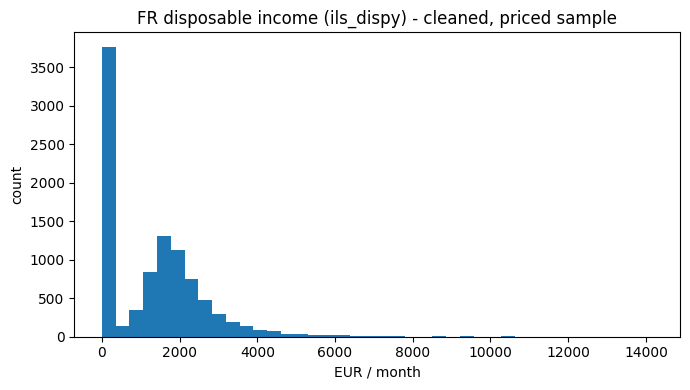

In [16]:
import matplotlib.pyplot as plt
if 'priced' not in globals():
    raise RuntimeError('Run section 6 first; priced is not defined because EUROMOD pricing has not completed.')
if 'ils_dispy' not in priced.columns:
    raise KeyError("priced is missing 'ils_dispy'; check the EUROMOD output in section 6.")
c = pd.to_numeric(priced['ils_dispy'], errors='coerce')
if c.notna().sum() == 0:
    raise ValueError("priced['ils_dispy'] has no numeric values.")
print(c.describe())
plt.figure(figsize=(7, 4))
plt.hist(c.clip(lower=0), bins=40)
plt.title('FR disposable income (ils_dispy) - cleaned, priced sample')
plt.xlabel('EUR / month'); plt.ylabel('count'); plt.tight_layout(); plt.show()

---
## What you have after this
A clean line from your **original FR microdata** to a priced, inspectable sample, with the household funnel visible at every eligibility step. The only path I could not supply is your raw file (cell 0); the eligibility rules are your DE adapter's FR-mirror chain, the column names are EUROMOD-standard and checked in cell 1, and the FR-vs-DE differences (`is_worker`+lma, region kept, yem00/yemxp) are flagged where they bite.

**Next** (only if useful): build the latent-job alternatives from this cleaned sample (`generate_draws_long`) and price them — that step needs an FR earnings-mutation policy mirroring DE's `de_earnings_policy` (the yem00/yemxp 35h split), the one FR piece not yet written.

In [17]:
# ── 8. Restrict to singles (the trial scope) ──────────────────────────────
singles_df = df[df['household_class'] == 'single'].reset_index(drop=True)
print('singles households:', singles_df['idhh'].nunique(), '| persons:', len(singles_df))

# the modelled individuals = the single deciders (one per single household)
singles_dec = singles_df[singles_df['ruro_decider'] == 1].reset_index(drop=True)
print('single deciders   :', len(singles_dec),
      '| female share   :', round(singles_dec['female'].mean(), 3))

singles_dec[['idhh','dag','dgn','female','les','lhw','is_worker',
             'wage_ruro','educL','educM','educH']].head(10)

singles households: 1555 | persons: 2236
single deciders   : 1555 | female share   : 0.541


,idhh,dag,dgn,female,les,lhw,is_worker,wage_ruro,educL,educM,educH
0,1495800,51,0,1,3,35,1,11.164835,1,0,0
1,1496401,40,0,1,3,45,1,14.636753,0,0,1
2,1502500,47,0,1,3,50,1,2.238462,1,0,0
3,1504300,38,1,0,3,55,1,25.919580,0,0,1
4,1516900,37,0,1,3,35,1,23.769231,0,0,1
5,1526601,27,1,0,3,40,1,18.365384,0,0,1
6,1527000,28,1,0,3,35,1,12.000000,0,0,1
7,1533500,31,1,0,3,45,1,8.970085,0,1,0
8,1535100,43,0,1,3,35,1,22.626374,0,0,1
9,1537301,29,1,0,3,20,1,9.346154,0,0,1


In [18]:
# ── 9. Discover the REAL draws / engine-ready API (no guessing) ────────────
import importlib, inspect, pkgutil
import dclaborsupply, dclaborsupply_app

def show_api(pkg):
    for m in pkgutil.walk_packages(pkg.__path__, pkg.__name__ + '.'):
        if any(k in m.name.lower() for k in
               ['draw', 'alternativ', 'continuous', 'engine_ready', 'prep', 'pricing']):
            try:
                mod = importlib.import_module(m.name)
            except Exception as e:
                print(f'MODULE {m.name}  (import failed: {e})'); continue
            members = [(n, o) for n, o in vars(mod).items()
                       if (inspect.isfunction(o) or inspect.isclass(o))
                       and not n.startswith('_')
                       and getattr(o, '__module__', '') == m.name]
            if members:
                print(f'\nMODULE {m.name}')
                for n, o in members:
                    try: sig = str(inspect.signature(o))
                    except (ValueError, TypeError): sig = '(...)'
                    doc = (inspect.getdoc(o) or '').split('\n')[0]
                    print(f'   {n}{sig}')
                    if doc: print(f'        └ {doc[:90]}')

print('================ dclaborsupply (core) ================')
show_api(dclaborsupply)
print('\n================ dclaborsupply_app (DE template + euromod) ================')
show_api(dclaborsupply_app)

================ dclaborsupply (core) ================

MODULE dclaborsupply.alternatives.continuous
   generate_draws_long(df: 'pd.DataFrame', *, n_draws: 'int' = 99, wage_spec: 'str' = 'vw', occ_spec: 'str' = 'fixed', occ_strata: 'tuple[str, ...]' = ('dgn', 'educ3'), occ_min_cell: 'int' = 30, pi0_m: 'float' = 0.1, pi0_f: 'float' = 0.1, h_min: 'float' = 5.0, h_max: 'float' = 70.0, w_min: 'float' = 2.0, w_max: 'float' = 170.0, rng_seed: 'int' = 17) -> 'pd.DataFrame'
        └ Take a RURO_ready dataset (one row per person) and return a long dataset
   build_continuous_alternatives(df: 'pd.DataFrame', **kwargs) -> 'pd.DataFrame'
        └ Thin alias for :func:`generate_draws_long` (skeleton API compatibility).

MODULE dclaborsupply.alternatives.job_grid
   build_job_grid(*args: 'Any', **kwargs: 'Any') -> 'Any'
        └ Build job-choice alternatives once that trajectory is migrated.

================ dclaborsupply_app (DE template + euromod) ================

MODULE dclaborsupply_app.de.

In [19]:
# ── 10 (revised). Full columns + probe generate_draws_long ─────────────────
import numpy as np, traceback
from dclaborsupply.alternatives.continuous import generate_draws_long
from dclaborsupply_app.de.draws_prep import assert_choice_state_consistent

if 'educ3' not in singles_dec.columns:
    singles_dec['educ3'] = np.select(
        [singles_dec['educL'] == 1, singles_dec['educM'] == 1, singles_dec['educH'] == 1],
        [0, 1, 2], default=-1).astype(int)

# (1) everything singles_dec carries — so I map the right wage/occ/loc column names
print('--- singles_dec columns ---')
print(sorted(singles_dec.columns)); print()

# (2) probe the real function on 5 rows; surface exactly what it wants
try:
    probe_dec = singles_dec.head(5).copy().assign(hh_IsHead=1, hh_IsPartner=0)
    assert_choice_state_consistent(probe_dec)
    out = generate_draws_long(
        probe_dec,
        n_draws=4,
        rng_seed=17,
    )
    print('PROBE OK — output shape:', out.shape)
    print('output columns:', list(out.columns))
    display(out.head(12))
except Exception as e:
    print('PROBE NEEDS:', type(e).__name__, '->', e)
    traceback.print_exc()

--- singles_dec columns ---
['aca', 'aco', 'afc', 'age_norm', 'age_norm2', 'amrrm', 'amrtn', 'ate', 'bch00', 'bchcc', 'bched', 'bchlg', 'bchot', 'bchyc', 'bdi', 'bed', 'bfa', 'bhl', 'bho', 'bhoot', 'bhotn', 'bsa', 'bsa00', 'bsaoa', 'bsaot', 'bsuwd', 'bun', 'bunct', 'bunmt', 'bunmy', 'dag', 'dct', 'dcu', 'dcz', 'ddi', 'ddt', 'dec', 'decde', 'deh', 'dehde', 'dew', 'dey', 'dgn', 'dmb', 'dms', 'dncsy', 'drg01', 'drgmd', 'drgn1', 'drgn2', 'drgru', 'drgur', 'dsu00', 'dsu01', 'dsu02', 'dwt', 'e20ps_o', 'e20pslw_o', 'e20psmd_o', 'e20pspo_o', 'educ3', 'educH', 'educL', 'educM', 'female', 'household_class', 'idfather', 'idhh', 'idmother', 'idorighh', 'idorigperson', 'idpartner', 'idperson', 'is_worker', 'kfb', 'kfbcc', 'kfbmy', 'kivho', 'lcs', 'les', 'lfs', 'lhw', 'lhw_f', 'lindi', 'liwftmy', 'liwmy', 'liwmy_f', 'liwptmy', 'liwwh', 'liwwh_f', 'loc', 'loc4', 'loc_armed', 'loc_raw', 'loc_ruro', 'lowas', 'lpemy', 'lse', 'lunmy', 'lunmy_f', 'pdi', 'pdi00', 'pdimy', 'poa', 'poa00', 'poamy', 'psu', 'p

,idhh,idperson,idfather,idmother,idpartner,idorighh,idorigperson,dag,dmb,dgn,dms,dcz,ddi,drgur,drgmd,drgru,ddt,dwt,dsu00,dsu01,dsu02,dncsy,dcu,dct,dec,decde,deh,dehde,dey,dew,drgn2,drgn1,drg01,les,lcs,lfs,lindi,liwmy,liwftmy,liwptmy,...,lunmy_f,yem_f,yse_f,household_class,ruro_decider,is_worker,working,working_pt1,working_pt2,working_ft,working_lh,educL,educM,educH,wage_for_draws,wage_ruro,age_norm,age_norm2,female,loc_raw,loc_ruro,loc4,loc_armed,educ3,hh_IsHead,hh_IsPartner,idperson_true,idhh_true,hours,lhw_base,yivwg_base,wage,draw,is_decider,is_chosen,log_q_state,log_q_hours,log_q_wage,log_q_occ,log_q_total
0,1495800,149580001,0,0,0,1495800,149580001,51,11,0,1,3,0,1,0,0,22016,4997.319,0,147,428,0,0,5,0,-1,1,100,5,1979,1,1,1,3,0,5,8,12,12,0,...,1,1,1,single,1,1,1,0,0,0,0,1,0,0,11.164835,11.164835,9.896478,97.940283,1,9,9,1,0,0,1,0,149580001,1495800,35.000000,35,11.164835,11.164835,0,1,1,-0.105361,-4.174387,-5.123964,0.0,-9.403712
1,1495800,149580001,0,0,0,1495800,149580001,51,11,0,1,3,0,1,0,0,22016,4997.319,0,147,428,0,0,5,0,-1,1,100,5,1979,1,1,1,3,0,5,8,12,12,0,...,1,1,1,single,1,1,1,0,0,0,0,1,0,0,11.164835,88.454072,9.896478,97.940283,1,9,9,1,0,0,1,0,149580001,1495800,15.719944,35,11.164835,88.454072,1,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
2,1495800,149580001,0,0,0,1495800,149580001,51,11,0,1,3,0,1,0,0,22016,4997.319,0,147,428,0,0,5,0,-1,1,100,5,1979,1,1,1,3,0,5,8,12,12,0,...,1,1,1,single,1,1,1,0,0,0,0,1,0,0,11.164835,48.887619,9.896478,97.940283,1,9,9,1,0,0,1,0,149580001,1495800,35.027264,35,11.164835,48.887619,2,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
3,1495800,149580001,0,0,0,1495800,149580001,51,11,0,1,3,0,1,0,0,22016,4997.319,0,147,428,0,0,5,0,-1,1,100,5,1979,1,1,1,3,0,5,8,12,12,0,...,1,1,1,single,1,1,1,0,0,0,0,1,0,0,11.164835,107.826257,9.896478,97.940283,1,9,9,1,0,0,1,0,149580001,1495800,41.855235,35,11.164835,107.826257,3,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
4,1495800,149580001,0,0,0,1495800,149580001,51,11,0,1,3,0,1,0,0,22016,4997.319,0,147,428,0,0,5,0,-1,1,100,5,1979,1,1,1,3,0,5,8,12,12,0,...,1,1,1,single,1,1,1,0,0,0,0,1,0,0,11.164835,82.504058,9.896478,97.940283,1,9,9,1,0,0,1,0,149580001,1495800,34.374100,35,11.164835,82.504058,4,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
5,1496401,149640101,0,0,0,1496401,149640002,40,11,0,1,1,0,1,0,0,22016,11732.740,0,147,119,0,0,5,0,-1,5,500,18,2004,1,1,1,3,1,50,6,12,12,0,...,1,1,1,single,1,1,1,0,0,0,1,0,0,1,14.636753,14.636753,-1.103522,1.217760,1,3,3,4,0,2,1,0,149640101,1496401,45.000000,45,14.636753,14.636753,0,1,1,-0.105361,-4.174387,-5.123964,0.0,-9.403712
6,1496401,149640101,0,0,0,1496401,149640002,40,11,0,1,1,0,1,0,0,22016,11732.740,0,147,119,0,0,5,0,-1,5,500,18,2004,1,1,1,3,1,50,6,12,12,0,...,1,1,1,single,1,1,1,0,0,0,1,0,0,1,14.636753,111.752521,-1.103522,1.217760,1,3,3,4,0,2,1,0,149640101,1496401,64.785419,45,14.636753,111.752521,1,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
7,1496401,149640101,0,0,0,1496401,149640002,40,11,0,1,1,0,1,0,0,22016,11732.740,0,147,119,0,0,5,0,-1,5,500,18,2004,1,1,1,3,1,50,6,12,12,0,...,1,1,1,single,1,1,1,0,0,0,1,0,0,1,14.636753,93.096367,-1.103522,1.217760,1,3,3,4,0,2,1,0,149640101,1496401,57.970073,45,14.636753,93.096367,2,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
8,1496401,149640101,0,0,0,1496401,149640002,40,11,0,1,1,0,1,0,0,22016,11732.740,0,147,119,0,0,5,0,-1,5,500,18,2004,1,1,1,3,1,50,6,12,12,0,...,1,1,1,single,1,1,1,0,0,0,1,0,0,1,14.636753,22.363472,-1.103522,1.217760,1,3,3,4,0,2,1,0,149640101,1496401,31.075794,45,14.636753,22.363472,3,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712
9,1496401,149640101,0,0,0,1496401,149640002,40,11,0,1,1,0,1,0,0,22016,11732.740,0,147,119,0,0,5,0,-1,5,500,18,2004,1,1,1,3,1,50,6,12,12,0,...,1,1,1,single,1,1,1,0,0,0,1,0,0,1,14.636753,154.667988,-1.103522,1.217760,1,3,3,4,0,2,1,0,149640101,1496401,18.205501,45,14.636753,154.667988,4,1,0,-0.105361,-4.174387,-5.123964,0.0,-9.403712


In [20]:
# ── 11. Generate the singles draws (99 sampled + draw 0 observed = 100) ────
m = singles_dec['female'] == 0; f = singles_dec['female'] == 1
pi0_m = float((singles_dec.loc[m, 'is_worker'] == 0).mean())
pi0_f = float((singles_dec.loc[f, 'is_worker'] == 0).mean())
print(f'observed non-employment  men: {pi0_m:.3f}  women: {pi0_f:.3f}')

singles_dec_draw = singles_dec.assign(hh_IsHead=1, hh_IsPartner=0)
assert_choice_state_consistent(singles_dec_draw)

draws_long = generate_draws_long(
    singles_dec_draw,
    n_draws=99,                 # 99 sampled + draw 0 (observed) = 100 alternatives
    wage_spec='vw',             # CONFIRM == spec.wage_spec
    occ_spec='fixed',           # CONFIRM vs spec's occupation treatment (see note below)
    occ_strata=('dgn', 'educ3'),
    pi0_m=pi0_m, pi0_f=pi0_f,
    h_min=5.0,  h_max=70.0,
    w_min=2.0,  w_max=170.0,
    rng_seed=17,
)
print('draws_long shape:', draws_long.shape, '  (expect 155500)')

observed non-employment  men: 0.139  women: 0.128
draws_long shape: (155500, 161)   (expect 155500)


In [21]:
# ── 12. Canonicalize the post-draw non-employment state + inspect ──────────
from dclaborsupply_app.de.draws_prep import canonicalize_post_draws
draws_canon = canonicalize_post_draws(draws_long)

# Post-draw consistency is alternative-state consistency: hours==0 rows are non-employment.
# The inherited is_worker column is the observed baseline worker flag, not a per-draw flag.
if 'loc4' not in draws_canon.columns:
    raise KeyError("loc4 missing from draws_canon. Run the dedicated loc_ruro / loc4 construction cell before generating draws.")
nonemp = pd.to_numeric(draws_canon['hours'], errors='coerce').fillna(0.0) <= 0.0
assert (draws_canon.loc[nonemp, ['working', 'working_pt1', 'working_pt2', 'working_ft', 'working_lh',
                                 'wage', 'wage_ruro', 'yem']] == 0).all().all()
assert (draws_canon.loc[nonemp, 'loc4'] == -1).all()
assert np.allclose(draws_canon['yemse'], pd.to_numeric(draws_canon['yem']) + pd.to_numeric(draws_canon['yse']))
print('canonicalized; consistent. rows:', len(draws_canon),
      '| persons:', draws_canon['idperson_true'].nunique())

kcol = 'idperson_true' if 'idperson_true' in draws_canon.columns else 'idperson'
one = draws_canon[draws_canon[kcol] == draws_canon[kcol].iloc[0]]
cols = [c for c in ['draw','is_chosen','hours','wage','is_worker',
                    'log_q_hours','log_q_wage','log_q_occ','log_q_total'] if c in one.columns]
one[cols].sort_values('draw').head(20)

canonicalized; consistent. rows: 155500 | persons: 1555


,draw,is_chosen,hours,wage,is_worker,log_q_hours,log_q_wage,log_q_occ,log_q_total
0,0,1,35.000000,11.164835,1,-4.174387,-5.123964,0.0,-9.435797
1,1,0,8.664703,106.337239,1,-4.174387,-5.123964,0.0,-9.435797
2,2,0,57.405039,114.648249,1,-4.174387,-5.123964,0.0,-9.435797
3,3,0,15.889093,85.592000,1,-4.174387,-5.123964,0.0,-9.435797
4,4,0,35.960105,18.826566,1,-4.174387,-5.123964,0.0,-9.435797
5,5,0,68.048108,90.861881,1,-4.174387,-5.123964,0.0,-9.435797
6,6,0,68.138455,101.002921,1,-4.174387,-5.123964,0.0,-9.435797
7,7,0,5.826190,166.120814,1,-4.174387,-5.123964,0.0,-9.435797
8,8,0,16.986054,146.305930,1,-4.174387,-5.123964,0.0,-9.435797
9,9,0,23.923810,137.343650,1,-4.174387,-5.123964,0.0,-9.435797


In [22]:
# ── 14. EMPIRICAL probe: does the yem00/yemxp 35h split move FR_2015 ils_dispy? ──
WEEKS = 13.0/3.0  # 4.3333, EUROMOD weeks/month
if 'em_input' not in globals():
    if 'df' not in globals():
        raise RuntimeError('Run sections 0-5 first; df is not defined.')
    if 'loc4' not in df.columns:
        raise RuntimeError('Run section 5b first; loc4 has not been constructed.')
    derived = {'household_class','ruro_decider','is_worker','working','working_pt1','working_pt2',
               'working_ft','working_lh','educL','educM','educH','wage_for_draws','wage_ruro',
               'age_norm','age_norm2','female','loc_raw','loc_ruro','loc4','loc_armed'}
    em_input = df[[c for c in df.columns if c not in derived]].copy()
if 'conn' not in globals():
    conn = EuromodConnector(str(MODEL_ROOT))

dec = singles_dec[singles_dec['is_worker'] == 1].iloc[0]
test_hh, test_person = dec['idhh'], dec['idperson']
base = em_input[em_input['idhh'] == test_hh].copy()
who = base['idperson'] == test_person
print('test hh:', test_hh, '| decider idperson:', test_person, '| rows:', len(base))

hours, wage = 40.0, 15.0
yem_total = wage * hours * WEEKS
yem_std   = wage * min(hours, 35.0) * WEEKS
yem_ot    = wage * max(hours - 35.0, 0.0) * WEEKS
print(f'target {yem_total:.2f}/mo  (std {yem_std:.2f} + ot {yem_ot:.2f})')

def price_encoding(label, overrides):
    g = base.copy(); g.loc[who, 'lhw'] = hours
    for col, val in overrides.items():
        if col in g.columns: g.loc[who, col] = val
    r = conn.run(g, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET)
    disp = float(pd.to_numeric(r.output.loc[r.output['idperson'] == test_person, 'ils_dispy']).iloc[0])
    print(f'  {label:18s} ils_dispy = {disp:10.2f}   warnings: {len(r.warnings)}')
    return disp

print('\npricing 3 encodings of the same earnings:')
d1 = price_encoding('E1 all-standard', {'yem': yem_total, 'yem00': yem_total, 'yemxp': 0.0})
d2 = price_encoding('E2 split-35h',    {'yem': yem_total, 'yem00': yem_std,   'yemxp': yem_ot})
d3 = price_encoding('E3 yem-only',     {'yem': yem_total, 'yem00': 0.0,       'yemxp': 0.0})
print(f'\nE1==E2? {abs(d1-d2) < 0.01}   (True -> 35h split does NOT change disposable income)')
print(f'E1==E3? {abs(d1-d3) < 0.01}   (True -> yem carries earnings; yem00/yemxp informational)')

test hh: 1495800 | decider idperson: 149580001 | rows: 3
target 2600.00/mo  (std 2275.00 + ot 325.00)

pricing 3 encodings of the same earnings:
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
  E1 all-standard    ils_dispy =    2480.99   warnings: 0
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
  E2 split-35h       ils_dispy =    2480.99   warnings: 0
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
  E3 yem-only        ils_dispy =     944.17   warnings: 0

E1==E2? True   (True -> 35h split does NOT change disposable income)
E1==E3? False   (True -> yem carries earnings; yem00/yemxp informational)


In [23]:
# ── 15. FR earnings policy + verification against observed FR encoding ──
from typing import Any, Dict, Mapping
import inspect
from dclaborsupply_app.euromod import EuromodPricingRunner

WEEKS_PER_MONTH = 13.0 / 3.0

def fr_earnings_policy(member: Mapping[str, Any], *, hours: float, wage: float,
                       weeks_per_month: float = WEEKS_PER_MONTH) -> Dict[str, float]:
    """FR decider-input overrides for one priced alternative.

    Mirrors the active France MNL generated-alternative accounting in
    scripts/enhanced/enh_RURO_euromod.py: split employment income at the
    35h French workweek using the offer wage:
        yem00 = wage * min(hours, 35) * weeks    (standard)
        yemxp = wage * max(hours - 35, 0) * weeks  (overtime)
    yem = yem00 + yemxp. If the input schema carries yemse, also keep
    yemse = yem + yse. FR_2015 normally reads yse + yem00 + yemxp, while
    yemse is a DE-style aggregate, so we do not inject it when absent.
    """
    try:
        yse = float(member.get('yse', 0.0) or 0.0)
    except (TypeError, ValueError):
        yse = 0.0
    h = float(hours)
    wrate = float(wage)
    weeks = float(weeks_per_month)
    std = wrate * min(h, 35.0) * weeks
    ot = wrate * max(h - 35.0, 0.0) * weeks
    yem = std + ot
    out = {'lhw': h, 'yem00': std, 'yemxp': ot, 'yem': yem}
    if 'yemse' in member:
        out['yemse'] = yem + yse
    return out

if 'em_input' not in globals():
    if 'df' not in globals():
        raise RuntimeError('Run sections 0-5 first; df is not defined.')
    derived = {'household_class','ruro_decider','is_worker','working','working_pt1','working_pt2',
               'working_ft','working_lh','educL','educM','educH','wage_for_draws','wage_ruro',
               'age_norm','age_norm2','female','loc_raw','loc_ruro','loc4','loc_armed'}
    em_input = df[[c for c in df.columns if c not in derived]].copy()
if 'conn' not in globals():
    conn = EuromodConnector(str(MODEL_ROOT))

# (a) Observed-data diagnostic: raw yemxp can include overtime/bonus residuals,
# so this does not have to match the generated-alternative accounting exactly.
w = singles_dec[singles_dec['is_worker'] == 1].copy()
for c in ['yivwg', 'yem_hour', 'lhw', 'yem00', 'yemxp', 'yem']:
    if c in w.columns:
        w[c] = pd.to_numeric(w[c], errors='coerce')
pred00 = w['yivwg'] * w['lhw'].clip(upper=35.0) * WEEKS_PER_MONTH
predxp = w['yivwg'] * (w['lhw'] - 35.0).clip(lower=0.0) * WEEKS_PER_MONTH
err00 = (w['yem00'] - pred00).abs()
errxp = (w['yemxp'] - predxp).abs()
print('workers:', len(w), '| with yemxp>0:', int((w['yemxp'] > 0).sum()))
print('raw yem00 vs MNL split |err| med/95p/max: %.2f / %.2f / %.2f' % (err00.median(), err00.quantile(.95), err00.max()))
print('raw yemxp vs MNL split |err| med/95p/max: %.2f / %.2f / %.2f' % (errxp.median(), errxp.quantile(.95), errxp.max()))
if 'yem_hour' in w.columns:
    ot_equiv = w['yemxp'] / w['yem_hour'].replace(0, np.nan)
    extra = (w['lhw'] - 35.0).clip(lower=0.0)
    print('median observed overtime-equivalent hours minus max(lhw-35,0): %.2f' % ((ot_equiv - extra).dropna().median()))
print('Interpretation: generated alternatives follow MNL straight split; raw yemxp is an observed residual component.')

# (b) Verify the policy itself matches the generated-alternative accounting.
policy_checks = []
member0 = singles_dec.iloc[0].to_dict()
for h, wrate in [(0.0, 18.0), (20.0, 12.0), (35.0, 15.0), (42.0, 15.0), (70.0, 22.5)]:
    ov = fr_earnings_policy(member0, hours=h, wage=wrate)
    expected00 = wrate * min(h, 35.0) * WEEKS_PER_MONTH
    expectedxp = wrate * max(h - 35.0, 0.0) * WEEKS_PER_MONTH
    assert abs(ov['yem00'] - expected00) < 1e-8
    assert abs(ov['yemxp'] - expectedxp) < 1e-8
    assert abs(ov['yem'] - (ov['yem00'] + ov['yemxp'])) < 1e-8
    policy_checks.append({'hours': h, 'wage': wrate, 'yem00': round(ov['yem00'], 2),
                          'yemxp': round(ov['yemxp'], 2), 'yem': round(ov['yem'], 2)})
print('\nGenerated-alternative policy checks:')
print(pd.DataFrame(policy_checks).to_string(index=False))

print('\nEuromodPricingRunner signatures:')
print('  __init__    ', inspect.signature(EuromodPricingRunner))
print('  build_inputs', inspect.signature(EuromodPricingRunner.build_inputs))
print('  price       ', inspect.signature(EuromodPricingRunner.price))


workers: 1348 | with yemxp>0: 690
raw yem00 vs MNL split |err| med/95p/max: 43.95 / 868.22 / 11224.58
raw yemxp vs MNL split |err| med/95p/max: 34.17 / 413.60 / 4707.08
median observed overtime-equivalent hours minus max(lhw-35,0): 0.50
Interpretation: generated alternatives follow MNL straight split; raw yemxp is an observed residual component.

Generated-alternative policy checks:
 hours  wage  yem00  yemxp    yem
   0.0  18.0    0.0    0.0    0.0
  20.0  12.0 1040.0    0.0 1040.0
  35.0  15.0 2275.0    0.0 2275.0
  42.0  15.0 2275.0  455.0 2730.0
  70.0  22.5 3412.5 3412.5 6825.0

EuromodPricingRunner signatures:
  __init__     (connector: 'PricingConnector', policy: 'EarningsMutationPolicy', *, columns: 'Optional[PricingColumns]' = None, hh_base: 'int' = 900000000, person_mult: 'int' = 1000) -> 'None'
  build_inputs (self, alternatives: 'pd.DataFrame', baseline: 'pd.DataFrame', *, alt_key_cols: 'Sequence[str]', weeks_per_month: 'float' = 4.333333333333333, data_year: 'Optional[int]

In [24]:
# ── 16. Price alternatives via EuromodPricingRunner — SMOKE TEST (5 households) ──
from dclaborsupply_app.euromod import EuromodPricingRunner

# (1) alternatives: runner reads source_idhh, decider_idperson, hours, wage + alt key 'draw'
alt = draws_canon.copy()
alt['source_idhh']      = alt['idhh_true']
alt['decider_idperson'] = alt['idperson_true']

# (2) baseline: full singles households (decider + members); EUROMOD-input cols + decider flag.
single_idhh = df.loc[df['household_class'] == 'single', 'idhh'].unique()
keep = list(em_input.columns) + ['ruro_decider']
baseline = df.loc[df['idhh'].isin(single_idhh), keep].copy()
print('baseline:', len(baseline), 'rows |', baseline['idhh'].nunique(), 'hh |',
      int(baseline['ruro_decider'].sum()), 'flagged deciders (should == hh)')

runner = EuromodPricingRunner(conn, fr_earnings_policy)

# (3) smoke: 5 hh × 100 alts = 500 synthetic households
smoke_hh   = single_idhh[:5]
alt_smoke  = alt[alt['source_idhh'].isin(smoke_hh)].copy()
base_smoke = baseline[baseline['idhh'].isin(smoke_hh)].copy()
res = runner.price(alt_smoke, base_smoke,
                   country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET,
                   alt_key_cols=['draw'], weeks_per_month=WEEKS_PER_MONTH, data_year=None)
print('priced rows:', len(res.output), '| warnings:', len(res.warnings), '| errors:', len(res.errors))

# (4) sanity: one decider's consumption across its 100 alternatives, by hours (budget curve)
dec_rows = res.output[res.output['ruro_decider'] == 1]
g = (dec_rows[dec_rows['source_idhh'] == smoke_hh[0]]
     .merge(alt_smoke.loc[alt_smoke['source_idhh'] == smoke_hh[0], ['draw','hours','wage','is_chosen']],
            on='draw', how='left')
     .sort_values('hours'))
print('\ndecider', smoke_hh[0], '— ils_dispy across alternatives (sorted by hours):')
print(g[['draw','is_chosen','hours','wage','ils_dispy']].head(20).to_string(index=False))
print('\ntax-unit totals (head):'); print(res.taxunit_totals.head())

baseline: 2236 rows | 1555 hh | 1555 flagged deciders (should == hh)
Simulation for system FR_2015 with dataset FR_2016_a3 finished.
priced rows: 1000 | warnings: 0 | errors: 0

decider 1495800 — ils_dispy across alternatives (sorted by hours):
 draw  is_chosen    hours       wage   ils_dispy
   13          0 0.000000   0.000000 1348.998200
   10          0 0.000000   0.000000  944.169617
   19          0 0.000000   0.000000 1348.998200
   16          0 0.000000   0.000000  944.169617
   59          0 0.000000   0.000000 1348.998200
   61          0 0.000000   0.000000 1348.998200
   43          0 0.000000   0.000000  944.169617
   45          0 0.000000   0.000000 1348.998200
   57          0 0.000000   0.000000 1348.998200
   80          0 0.000000   0.000000 1348.998200
   86          0 0.000000   0.000000  944.169617
   83          0 0.000000   0.000000 1348.998200
   27          0 5.225676  42.761706 1811.665991
    7          0 5.826190 166.120814 3674.344803
   64          0 5.8

In [25]:
# ── DIAGNOSE 3b: per-draw population sweep (original ids) — stable? ────────
def sweep_price(d):
    frames = []
    for hh in smoke_hh:
        b = em_input[em_input['idhh']==hh].copy()
        arow = alt_smoke[(alt_smoke['source_idhh']==hh) & (alt_smoke['draw']==d)].iloc[0]
        pid  = int(arow['decider_idperson']); who = b['idperson']==pid
        member = b.loc[who].iloc[0].to_dict()
        for col, val in fr_earnings_policy(member, hours=float(arow['hours']),
                                           wage=float(arow['wage'])).items():
            if col in b.columns: b.loc[who, col] = val
        frames.append(b)
    batch = pd.concat(frames, ignore_index=True).sort_values(['idhh','idperson'])
    out = conn.run(batch, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET).output
    return out

o10, o83 = sweep_price(10), sweep_price(83)
for hh in smoke_hh:
    pid = int(alt_smoke[(alt_smoke['source_idhh']==hh) & (alt_smoke['draw']==10)]['decider_idperson'].iloc[0])
    a10 = alt_smoke[(alt_smoke['source_idhh']==hh) & (alt_smoke['draw']==10)][['hours','wage']].iloc[0]
    a83 = alt_smoke[(alt_smoke['source_idhh']==hh) & (alt_smoke['draw']==83)][['hours','wage']].iloc[0]
    d10 = float(pd.to_numeric(o10.loc[o10['idperson']==pid,'ils_dispy']).iloc[0])
    d83 = float(pd.to_numeric(o83.loc[o83['idperson']==pid,'ils_dispy']).iloc[0])
    tag = ''
    if a10['hours']==0 and a83['hours']==0:
        tag = '  <- both non-emp: MUST match' + ('  OK' if abs(d10-d83)<1e-3 else '  MISMATCH')
    print(f'hh {hh}: sweep10={d10:10.4f} (h={a10["hours"]:5.1f})  sweep83={d83:10.4f} (h={a83["hours"]:5.1f}){tag}')
print('\nhh0 non-emp target (isolated ground truth): 944.1696')

C:\Users\hisham\AppData\Local\Temp\44\ipykernel_758164\3575775213.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '49.549219301680225' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  if col in b.columns: b.loc[who, col] = val
C:\Users\hisham\AppData\Local\Temp\44\ipykernel_758164\3575775213.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '35.535628806327594' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  if col in b.columns: b.loc[who, col] = val
C:\Users\hisham\AppData\Local\Temp\44\ipykernel_758164\3575775213.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.693358791705551' has dtype incompatible with int64, please explicitly cast to a compatib

Simulation for system FR_2015 with dataset FR_2016_a3 finished.


C:\Users\hisham\AppData\Local\Temp\44\ipykernel_758164\3575775213.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '21.245030634579397' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  if col in b.columns: b.loc[who, col] = val
C:\Users\hisham\AppData\Local\Temp\44\ipykernel_758164\3575775213.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '36.400883715377915' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  if col in b.columns: b.loc[who, col] = val
C:\Users\hisham\AppData\Local\Temp\44\ipykernel_758164\3575775213.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8.943118399953502' has dtype incompatible with int64, please explicitly cast to a compatib

Simulation for system FR_2015 with dataset FR_2016_a3 finished.
hh 1495800: sweep10= 1348.9982 (h=  0.0)  sweep83=  944.1696 (h=  0.0)  <- both non-emp: MUST match  MISMATCH
hh 1496401: sweep10=10201.3412 (h= 49.5)  sweep83=  964.6127 (h= 21.2)
hh 1502500: sweep10= 2267.2330 (h= 35.5)  sweep83= 4563.8826 (h= 36.4)
hh 1504300: sweep10= 1211.0601 (h=  5.7)  sweep83=  772.0675 (h=  0.0)
hh 1516900: sweep10=  187.5173 (h=  0.0)  sweep83= 1298.9667 (h=  8.9)

hh0 non-emp target (isolated ground truth): 944.1696


In [ ]:
# ── 16. FULL singles pricing — deterministic (bsa00yn_a=1), chunked, resumable ──
import time
PRICE_DIR = Path('fr_singles_pricing_v1'); PRICE_DIR.mkdir(exist_ok=True)

baseline_full = baseline.copy()
baseline_full['bsa00yn_a'] = 1        # full-entitlement pricing; take-up mask applied at assembly

# Certified input-side fixes for WORKING alternatives (enh_RURO_euromod §12).
# DECIDE: certified zeroed 'bun'/'bsa' when present; your file carries bunmt/bunct instead.
# Mirroring the *intent* (no UB/SA inputs at hypothetical working states) means zeroing those too.
WORKING_ZERO_COLS = tuple(c for c in ('bun', 'bunmt', 'bunct', 'bsa') if c in baseline_full.columns)
FULLYEAR_COLS = {c: v for c, v in {'yemmy': 12.0, 'lunmy': 0.0}.items() if c in baseline_full.columns}
print('working-alternative fixes:', WORKING_ZERO_COLS, FULLYEAR_COLS)

def fr_earnings_policy_v2(member, *, hours, wage, weeks_per_month=WEEKS_PER_MONTH):
    ov = fr_earnings_policy(member, hours=hours, wage=wage, weeks_per_month=weeks_per_month)
    if float(hours) > 0:
        for c in WORKING_ZERO_COLS: ov[c] = 0.0
        ov.update(FULLYEAR_COLS)
    return ov

KEEP = ['idhh','idperson','source_idhh','source_idorighh','source_idperson',
        'ruro_decider','dgn','draw','ils_dispy','bsa00_s']
runner_full = EuromodPricingRunner(conn, fr_earnings_policy_v2)

hh_all = sorted(single_idhh); CHUNK = 200
outs, tux, _t_start = [], [], time.time()
for i in range(0, len(hh_all), CHUNK):
    part = hh_all[i:i+CHUNK]
    f_out, f_tu = PRICE_DIR/f'priced_{i:05d}.parquet', PRICE_DIR/f'taxunit_{i:05d}.parquet'
    if f_out.exists():
        outs.append(pd.read_parquet(f_out)); tux.append(pd.read_parquet(f_tu)); continue
    a = alt[alt['source_idhh'].isin(part)]
    b = baseline_full[baseline_full['idhh'].isin(part)]
    r = runner_full.price(a, b, country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET,
                          alt_key_cols=['draw'], weeks_per_month=WEEKS_PER_MONTH)
    bad = [e for e in r.errors if 'uprate' not in e.lower()]
    assert not bad, f'non-uprating EUROMOD errors: {bad[:3]}'
    o = r.output[[c for c in KEEP if c in r.output.columns]]
    o.to_parquet(f_out); r.taxunit_totals.to_parquet(f_tu)
    outs.append(o); tux.append(r.taxunit_totals)
    print(f'chunk {i//CHUNK+1}/{-(-len(hh_all)//CHUNK)}  rows={len(o)}  elapsed={time.time()-_t_start:.0f}s')

priced_all  = pd.concat(outs, ignore_index=True)
taxunit_all = pd.concat(tux, ignore_index=True)
print('priced_all:', priced_all.shape, '| households:', priced_all["source_idhh"].nunique(),
      '| expect deciders 155500 rows among', 1555*100, 'alternatives')

In [27]:
# ── 17-prep. Revealed take-up: reported receipt vs priced entitlement (draw 0) ──
ent0 = (priced_all[(priced_all['ruro_decider']==1) & (priced_all['draw']==0)]
        [['source_idhh','source_idorighh','ils_dispy','bsa00_s']]
        .rename(columns={'bsa00_s':'entitle_bsa00'}))
rep = singles_dec[['idhh','idperson','is_worker','les']].copy()
rep['reported_bsa00'] = pd.to_numeric(singles_dec.get('bsa00', 0), errors='coerce').fillna(0)
x = ent0.merge(rep, left_on='source_idhh', right_on='idhh', how='left')
x['entitled'] = x['entitle_bsa00'] > 0
x['reported'] = x['reported_bsa00'] > 0
nw = x[x['is_worker']==0]
print('NON-WORKING deciders (observed state):')
print(pd.crosstab(nw['entitled'], nw['reported'], margins=True))
ent_nw = nw[nw['entitled']]
if len(ent_nw): print(f'\nrevealed take-up rate among entitled non-working: {ent_nw["reported"].mean():.3f}  '
                      f'(EUROMOD calibrated BTA_nw = 0.7)   n={len(ent_nw)}')
wk = x[x['is_worker']==1]; ent_w = wk[wk['entitled']]
if len(ent_w): print(f'revealed take-up rate among entitled working    : {ent_w["reported"].mean():.3f}  '
                     f'(calibrated BTA_w = 0.4)   n={len(ent_w)}')

NON-WORKING deciders (observed state):
reported  False  True  All
entitled                  
False        24     6   30
True         80    97  177
All         104   103  207

revealed take-up rate among entitled non-working: 0.548  (EUROMOD calibrated BTA_nw = 0.7)   n=177
revealed take-up rate among entitled working    : 0.265  (calibrated BTA_w = 0.4)   n=294


In [28]:
b = pd.to_numeric(singles_dec.get('bsaot', 0), errors='coerce').fillna(0)
print(singles_dec.assign(bsaot_pos=b>0).groupby('is_worker')['bsaot_pos'].agg(['sum','mean']),
      '\nmedian bsaot | >0 :', float(b[b>0].median()))

           sum      mean
is_worker               
0           20  0.096618
1           43  0.031899 
median bsaot | >0 : 52.79


In [29]:
import inspect
from dclaborsupply_app.de.engine_ready import assemble_singles
print(inspect.getsource(assemble_singles))

def assemble_singles(
    priced: pd.DataFrame, features: pd.DataFrame, *,
    hh_key: str = "source_idhh", alt_keys: Sequence[str] = ("alt",),
    orighh_col: str = "source_idorighh", income_source: str = "ils_dispy",
    price_factor: float = 1.0,
) -> pd.DataFrame:
    """Engine-ready SINGLES: one row per (hh, alt); consumption = decider disposable income."""
    alt_keys = list(alt_keys)
    keys = [hh_key, *alt_keys]
    feat = features.copy()
    _require_present_finite(feat, _REQUIRED_FEATURES, tag="singles features")  # fix 7
    cons = aggregate_consumption(priced, household_type="singles", hh_key=hh_key,
                                 alt_keys=alt_keys, income_source=income_source, price_factor=price_factor)
    _require_present_finite(cons, ["consumption_raw"], tag="singles aggregated income")
    _validate_one_to_one(feat, cons, keys, "singles")
    out = feat.merge(cons, on=keys, how="inner", validate="one_to_one")
    out = apply_consumption_floor(out)
    out = restore

In [30]:
# ── 17a. Take-up traits (Decision 2b) + masked income column ────────────────
rng_seed = 20162016
d0 = (priced_all[(priced_all['ruro_decider']==1) & (priced_all['draw']==0)]
      [['source_idhh','source_idorighh','bsa00_s']].rename(columns={'bsa00_s':'ent0'}))
tt = d0.merge(singles_dec[['idhh','is_worker']].assign(
        reported=pd.to_numeric(singles_dec.get('bsa00',0), errors='coerce').fillna(0)>0),
      left_on='source_idhh', right_on='idhh', how='left')
tt['entitled0'] = tt['ent0'] > 0

nw, wk = tt[tt.is_worker==0], tt[tt.is_worker==1]
rate_nw = float(nw.loc[nw.entitled0,'reported'].mean())
rate_w  = float(wk.loc[wk.entitled0,'reported'].mean())
print(f'in-sample revealed rates: nw={rate_nw:.3f} (n={int(nw.entitled0.sum())}), '
      f'w={rate_w:.3f} (n={int(wk.entitled0.sum())})')

tt = tt.sort_values('source_idorighh').reset_index(drop=True)
rng = np.random.default_rng(rng_seed)
bern_nw = rng.random(len(tt)) < rate_nw
bern_w  = rng.random(len(tt)) < rate_w
revealed = tt['entitled0'] | tt['reported']          # own-margin revelation possible
own_taker = tt['reported']                            # receipt reveals taker (incl. 6 edge cases)
tt['takeup_nw'] = np.where(tt.is_worker==0, np.where(revealed, own_taker, bern_nw), bern_nw)
tt['takeup_w']  = np.where(tt.is_worker==1, np.where(revealed, own_taker, bern_w),  bern_w)
trait = tt[['source_idhh','takeup_nw','takeup_w']]
print(trait[['takeup_nw','takeup_w']].mean().round(3).to_string())

# masked income on every priced row: subtract entitlement for non-takers, by alternative type
pm = (priced_all
      .merge(alt[['source_idhh','draw','hours']].drop_duplicates(), on=['source_idhh','draw'], how='left')
      .merge(trait, on='source_idhh', how='left'))
take = np.where(pm['hours']>0, pm['takeup_w'], pm['takeup_nw']).astype(bool)
pm['ils_dispy_takeup'] = pd.to_numeric(pm['ils_dispy']) - \
                         pd.to_numeric(pm['bsa00_s']).fillna(0)*(~take)
chg = (pm['ils_dispy_takeup'] != pm['ils_dispy'])
print(f'rows adjusted: {int(chg.sum())} of {len(pm)}  '
      f'({pm.loc[chg,"source_idhh"].nunique()} households)  '
      f'median subtraction: {float((pm.loc[chg,"ils_dispy"]-pm.loc[chg,"ils_dispy_takeup"]).median()):.2f}')
priced_masked = pm

in-sample revealed rates: nw=0.548 (n=177), w=0.265 (n=294)
takeup_nw    0.542
takeup_w     0.292
rows adjusted: 15798 of 223600  (1174 households)  median subtraction: 345.34


In [31]:
# ── 17b. Assembly contract: required features vs what our frames carry ──────
from dclaborsupply_app.de import engine_ready as er
req = list(er._REQUIRED_FEATURES)
print('TOTAL_LEISURE_HOURS =', er.TOTAL_LEISURE_HOURS, '| DCM_MIN_POSITIVE =', er.DCM_MIN_POSITIVE)
print('_DE_ZERO_STUBS =', list(er._DE_ZERO_STUBS))
print('\n_REQUIRED_FEATURES =', req)
print('\nmissing from alt (features candidate):', [c for c in req if c not in alt.columns])
print('has log_q_E:', 'log_q_E' in alt.columns, '| log_q-ish cols:',
      [c for c in alt.columns if c.startswith('log_q')])
print('priced_masked has:', [c for c in ['source_idhh','draw','ils_dispy_takeup','ruro_decider'] 
                             if c in priced_masked.columns])

TOTAL_LEISURE_HOURS = 80.0 | DCM_MIN_POSITIVE = 1.0
_DE_ZERO_STUBS = ['drgn1', 'gsur', 'reg2', 'reg3', 'reg4', 'reg5', 'reg6', 'reg7', 'reg8', 'drgur', 'drgmd', 'drgru', 'year_2015_indicator', 'year_2017_indicator']

_REQUIRED_FEATURES = ['age_norm', 'age_norm2', 'n_children', 'educL', 'educM', 'educH', 'hours', 'wage', 'log_q_E', 'log_q_H', 'log_q_W', 'log_q_Occ', 'log_prior', 'prior']

missing from alt (features candidate): ['n_children', 'log_q_E', 'log_q_H', 'log_q_W', 'log_q_Occ', 'log_prior', 'prior']
has log_q_E: False | log_q-ish cols: ['log_q_state', 'log_q_hours', 'log_q_wage', 'log_q_occ', 'log_q_total']
priced_masked has: ['source_idhh', 'draw', 'ils_dispy_takeup', 'ruro_decider']


In [32]:
# ── 17c. Resolve the contract: prior provenance, wave01 identity, n_children ──

import inspect, re

import dclaborsupply.alternatives.continuous as cont

from dclaborsupply_app.de import engine_ready as er, data_prep as dp

# (1) where does log_prior come from? every 'prior' line in the core draws module

src = inspect.getsource(cont)

print('--- core draws module: lines mentioning prior ---')

for i, line in enumerate(src.splitlines(), 1):

    if 'prior' in line.lower(): print(f'{i:5d}: {line}')

# (2) the wave01 identity + canonical prior (defines log_q_* <-> log_prior semantics)

print('\n--- _validate_wave01 ---');   print(inspect.getsource(er._validate_wave01))

print('\n--- _canonical_prior ---');   print(inspect.getsource(er._canonical_prior))

# (3) DE's n_children definition

dsrc = inspect.getsource(dp)

hits = [m.start() for m in re.finditer(r'n_children', dsrc)]

print('\n--- n_children context in de.data_prep ---')

for h in hits[:3]:

    print(dsrc[max(0,h-300):h+300]); print('   ...')

# (4) full column inventory of the draws frame

print('\n--- draws_canon columns ---'); print(sorted(draws_canon.columns))

--- core draws module: lines mentioning prior ---
  319:     Priority:

--- _validate_wave01 ---
def _validate_wave01(df: pd.DataFrame, *, household_type: str) -> None:
    """Wave-0.1 proposal-density contract, AFTER state recomputation (gap 2).
    All identity comparisons use rtol=0.0, atol=1e-9 (no relative slack)."""
    num = lambda c: pd.to_numeric(df[c], errors="coerce").to_numpy(dtype="float64")  # noqa: E731
    ac = lambda a, b: np.allclose(a, b, rtol=_PRIOR_RTOL, atol=_PRIOR_ATOL)          # noqa: E731
    lp = num("log_prior")
    prior = num("prior")
    if not (prior > 0).all():
        raise ValueError(f"{household_type}: prior must be strictly > 0.")
    if not ac(prior, _canonical_prior(lp)):
        raise ValueError(f"{household_type}: prior != clip(exp(clip(log_prior,-700,700)),1e-16,None).")
    if household_type == "singles":
        _components_zero_on_nonworking(df, working_col="working",
                                       logq_cols=["log_q_H", "log_q_W", "l

In [33]:
# ── 17d. Features frame under the assembly contract (identity gate + renames) ──
from dclaborsupply_app.de import engine_ready as er

feat = draws_canon.copy()

# (1) identity gate: is log_q_total exactly E + working·(H+W+Occ)?
h = pd.to_numeric(feat['hours'], errors='coerce').fillna(0.0)
workingf = (h > 0).astype('float64')
comp = (pd.to_numeric(feat['log_q_state'])
        + workingf * (pd.to_numeric(feat['log_q_hours'])
                      + pd.to_numeric(feat['log_q_wage'])
                      + pd.to_numeric(feat['log_q_occ'])))
tot = pd.to_numeric(feat['log_q_total'])
print('identity max|log_q_total − (E + w·(H+W+Occ))| =', float((tot - comp).abs().max()))
nonw = workingf == 0
print('non-working H/W/Occ max|·| =',
      float(feat.loc[nonw, ['log_q_hours','log_q_wage','log_q_occ']].abs().max().max()))
assert np.allclose(tot, comp, rtol=0.0, atol=1e-9), 'identity FAILED — paste the two prints'
assert (feat.loc[nonw, ['log_q_hours','log_q_wage','log_q_occ']].abs() < 1e-12).all().all()

# (2) contract renames + canonical prior
feat = feat.rename(columns={'log_q_state':'log_q_E', 'log_q_hours':'log_q_H',
                            'log_q_wage':'log_q_W', 'log_q_occ':'log_q_Occ'})
feat['log_prior'] = tot
feat['prior'] = er._canonical_prior(tot.to_numpy())

# (3) n_children: non-adult members per single household (full frame, not deciders)
ADULT = CONFIG['age_range'][0]   # 20 in this trial — see note below
kid = pd.to_numeric(singles_df['dag'], errors='coerce') < ADULT
nkids = kid.groupby(singles_df['idhh']).sum().astype('int16')
feat['n_children'] = feat['idhh_true'].map(nkids).fillna(0).astype('int16')
n1819 = int(pd.to_numeric(singles_df['dag'], errors='coerce').between(18, ADULT-1).sum())
print(f'households with children: {int((feat.groupby("idhh_true")["n_children"].first()>0).sum())}'
      f' | members aged 18-{ADULT-1} counted as children: {n1819}')

# (4) assembly keys + final contract check
feat['source_idhh'] = feat['idhh_true']
feat['source_idorighh'] = pd.to_numeric(feat['idorighh'], errors='coerce').astype('int64')
missing = [c for c in er._REQUIRED_FEATURES if c not in feat.columns]
print('required features missing:', missing or 'none')
print('rows:', len(feat), '| unique (hh, draw):', len(feat.drop_duplicates(['source_idhh','draw'])))

identity max|log_q_total − (E + w·(H+W+Occ))| = 0.0
non-working H/W/Occ max|·| = 0.0
households with children: 428 | members aged 18-19 counted as children: 54
required features missing: none
rows: 155500 | unique (hh, draw): 155500


In [34]:
# ── 17e. Assemble engine-ready singles (floor, cluster_id, loc4, normalization) ──
from dclaborsupply_app.de.engine_ready import assemble_singles

# Draw-0 fix-up: generate_draws_long keeps the OBSERVED loc4 on draw 0 (it only
# forces -1 where hours==0), so the "unknown observed occupation" workers kept in
# §5b (loc4=-2) reach assembly as WORKING rows with loc4=-2 — which
# assemble_singles rejects. Their simulated working draws were already imputed by
# the draws-stage SAFETY block (pooled mode over valid observed working deciders,
# continuous.py), so apply the SAME pooled mode to their draw-0 rows.
_h = pd.to_numeric(feat['hours'], errors='coerce').fillna(0.0)
_l4 = pd.to_numeric(feat['loc4'], errors='coerce').fillna(-2).astype(int)
_bad = (_h > 0) & ~_l4.isin([1, 2, 3, 4])
if _bad.any():
    assert (pd.to_numeric(feat.loc[_bad, 'draw'], errors='coerce') == 0).all(), \
        'expected only draw-0 rows; simulated working draws should already be imputed'
    _pool = pd.to_numeric(
        singles_dec.loc[(pd.to_numeric(singles_dec['is_worker'], errors='coerce') == 1)
                        & pd.to_numeric(singles_dec['loc4'], errors='coerce').isin([1, 2, 3, 4]),
                        'loc4'], errors='coerce').astype(int).to_numpy()
    _mode = int(np.argmax(np.bincount(_pool, minlength=5)[1:5]) + 1)   # mirrors continuous.py SAFETY
    feat.loc[_bad, 'loc4'] = _mode
    print(f'draw-0 unknown-occupation workers: {int(_bad.sum())} row(s) mode-imputed -> loc4={_mode}')

er_singles = assemble_singles(priced_masked, feat, alt_keys=('draw',),
                              income_source='ils_dispy_takeup')
print('engine-ready singles:', er_singles.shape, ' (expect 155500 rows)')
print('consumption floored share:', round(float(er_singles['consumption_floored'].mean()), 4))
print(er_singles['consumption'].describe().round(2))
print('\nchosen rows:', int(pd.to_numeric(er_singles['is_chosen'], errors='coerce').sum())
      if 'is_chosen' in er_singles.columns else '(no is_chosen col — check name)')
er_singles.to_parquet('fr_singles_engine_ready_v1.parquet')
print('saved fr_singles_engine_ready_v1.parquet')


draw-0 unknown-occupation workers: 7 row(s) mode-imputed -> loc4=4
engine-ready singles: (155500, 197)  (expect 155500 rows)
consumption floored share: 0.0049
count    155500.00
mean       7209.92
std        5953.54
min           1.00
25%        2103.46
50%        5754.64
75%       11046.86
max       29769.26
Name: consumption, dtype: float64

chosen rows: 1555
saved fr_singles_engine_ready_v1.parquet


In [35]:
# ── 18. Load the certified spec: architecture + binding vs engine-ready ─────
from dclaborsupply import EstimationSpec
from dclaborsupply.spec.parser import load_custom_initial_values

# Certified 47-param baseline (beta_ll=0 + theta_l_m pinned) + its 901 warm start.
# (The gsplit variant exists alongside but FAILED the synthetic 901 gate — not certified.)
SPEC_YAML = Path(r'C:\Users\hisham\Repo\MNL\scripts\bpool\specs\estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml')
THETA_CSV = Path(r'C:\Users\hisham\Repo\MNL\scripts\bpool\specs\theta_hat_realdata_901_v1.csv')
assert SPEC_YAML.is_file(), f'spec yaml not found: {SPEC_YAML}'
assert THETA_CSV.is_file(), f'theta_hat csv not found: {THETA_CSV}'

spec = EstimationSpec.from_yaml(str(SPEC_YAML))
names = list(spec.all_param_names)
fixed = dict(getattr(spec, 'fixed_params', {}) or {})
# NOTE: fixed_params are REMOVED from all_param_names by the parser, so `names`
# is already the free set; `fixed` is reported separately, not subtracted.
print(f'params: {len(names)} free, fixed={fixed}\n')
for n in names: print('  ', n)

# warm start coverage
raw = load_custom_initial_values(THETA_CSV)
print('\ntheta_hat covers:', sum(n in raw for n in names), 'of', len(names),
      '| missing:', [n for n in names if n not in raw][:10])

# covariate binding: which spec-referenced data columns exist in er_singles?
# (print whatever the spec object exposes as covariate lists; adjust attr names to what dir() shows)
print('\nspec attrs:', [a for a in dir(spec) if not a.startswith('_')])


params: 47 free, fixed={'theta_l_m': -0.8}

   beta_l0_sm
   beta_l_age_sm
   beta_l_age2_sm
   theta_l_sm
   beta_l0_sf
   beta_l_age_sf
   beta_l_age2_sf
   beta_l_nkids_sf
   theta_l_sf
   theta_c_singles
   beta_l0_m
   beta_l_age_m
   beta_l_age2_m
   beta_l0_f
   beta_l_age_f
   beta_l_age2_f
   beta_l_nkids_f
   theta_l_f
   beta_E
   beta_h_pt1
   beta_h_pt2
   beta_h_ft
   beta_h_lh
   beta_E_gsur
   beta_E_drgn2
   beta_E_drgn3
   beta_E_drgn4
   beta_E_drgn5
   beta_E_drgn6
   beta_E_drgn7
   beta_E_drgn8
   beta_E_y2015
   beta_E_y2017
   beta_E_drgur
   beta_E_drgmd
   beta_occ_2_m
   beta_occ_3_m
   beta_occ_4_m
   beta_occ_2_f
   beta_occ_3_f
   beta_occ_4_f
   beta_w0
   beta_w_educL
   beta_w_educH
   beta_w_pexp
   beta_w_pexp2
   sigma

theta_hat covers: 47 of 47 | missing: []

spec attrs: ['ac2013_children_age_groups', 'ac2013_couples_cross_leisure', 'ac2013_couples_mu_0', 'ac2013_experience_in_wage', 'ac2013_use_log_age', 'all_param_names', 'bounds', 'couples_inter

In [36]:
# ── 19-pre. Revive FR region/urbanization in the engine-ready table ─────────
reg_src = (singles_dec[['idhh','drgn1','drgur','drgmd','drgru']]
           .apply(pd.to_numeric, errors='coerce'))
print('drgn1 value counts:'); print(reg_src['drgn1'].value_counts().sort_index().to_string())
tri = reg_src[['drgur','drgmd','drgru']].sum(axis=1)
print('urbanization triple sums to 1 for all deciders:', bool((tri == 1).all()))
assert reg_src['drgn1'].between(1, 8).all(), 'drgn1 outside 1..8 — paste the counts, mapping needs a look'

m = er_singles[['idhh']].merge(reg_src, on='idhh', how='left', validate='many_to_one')
for k in range(2, 9):
    er_singles[f'reg{k}'] = (m['drgn1'].to_numpy() == k).astype('float64')
for c in ['drgur', 'drgmd', 'drgru']:
    er_singles[c] = m[c].to_numpy(dtype='float64')
# gsur, year_2015_indicator, year_2017_indicator stay 0: gsur pending its FR construction;
# year effects unidentified in a single 2016 wave.

live = ['reg2','reg3','reg4','reg5','reg6','reg7','reg8','drgur','drgmd']
print('\nengine-ready shares:'); print(er_singles.groupby('idhh')[live].first().mean().round(3).to_string())
assert er_singles[live].notna().all().all()
er_singles.to_parquet('fr_singles_engine_ready_v2.parquet')
print('saved fr_singles_engine_ready_v2.parquet  (v1 kept for provenance)')

drgn1 value counts:
drgn1
1    245
2    254
3    122
4    135
5    279
6    175
7    182
8    163
urbanization triple sums to 1 for all deciders: True

engine-ready shares:
reg2     0.163
reg3     0.078
reg4     0.087
reg5     0.179
reg6     0.113
reg7     0.117
reg8     0.105
drgur    0.535
drgmd    0.211
saved fr_singles_engine_ready_v2.parquet  (v1 kept for provenance)


In [37]:
# ── 19-pre2. gsur into engine-ready (overwrite the DE zero-stub, gated) ─────
# ALWAYS rebuilds gsur from the certified GSURv2 Stage A lookup (idempotent —
# overwrites any stale gsur column from earlier kernel runs). Certified
# convention: survey 2016 ← opportunity year 2015 (fr_2016_RURO_mnl_GSURv2_y2015
# __mnlmeta.json), merge key (drgn1, educ3, dgn→sex), gsur = raw share in [0,1].
GSUR_LKP = Path(r'C:\Users\hisham\MNL\EUROMOD-STORAGE\Data\external\FR_gsur_ruro_v2_stageA_y2015.parquet')
assert GSUR_LKP.is_file(), f'gsur lookup not found: {GSUR_LKP}'

lkp = pd.read_parquet(GSUR_LKP)
lkp = lkp.loc[lkp['gsur'].notna(), ['drgn1', 'educ3', 'sex', 'gsur']]  # drop 6 drgn1=9 NaN stubs
assert len(lkp) == 48 and lkp['gsur'].between(0, 1).all()
lo, hi = float(lkp['gsur'].min()), float(lkp['gsur'].max())

if 'gsur' in singles_dec.columns:
    print('NOTE: singles_dec already had a gsur column (stale from an earlier run) — overwriting.')
keys = pd.DataFrame({
    'drgn1': pd.to_numeric(singles_dec['drgn1'], errors='coerce').astype('int64'),
    'educ3': pd.to_numeric(singles_dec['educ3'], errors='coerce').astype('int64'),
    'sex':   pd.to_numeric(singles_dec['dgn'],   errors='coerce').map({1: 'M', 0: 'F'}),
})
assert keys.notna().all().all(), 'unmapped dgn or non-numeric drgn1/educ3 in singles_dec'
mm = keys.merge(lkp, on=['drgn1', 'educ3', 'sex'], how='left', validate='many_to_one')
assert mm['gsur'].notna().all(), 'gsur match rate < 100% — inspect keys.value_counts()'
singles_dec = singles_dec.assign(gsur=mm['gsur'].to_numpy())
print(f'gsur rebuilt on singles_dec from {GSUR_LKP.name}  (lookup range [{lo:.4f}, {hi:.4f}])')

g = singles_dec.set_index('idhh')['gsur']
assert g.index.is_unique
before = float(pd.to_numeric(er_singles['gsur'], errors='coerce').abs().max())
er_singles['gsur'] = er_singles['idhh'].map(g).astype('float64')

s = er_singles.groupby('idhh')['gsur'].first()
print(f'gsur in er_singles before overwrite (max |gsur|): {before}')
print(f'merged: n={len(s)}, nulls={int(s.isna().sum())}')
print(s.describe().round(4).to_string())
assert s.notna().all() and s.between(0, 1).all()
assert s.between(lo, hi).all(), f'outside the {GSUR_LKP.name} range [{lo}, {hi}] — wrong file or scale'
assert s.nunique() > 1, 'gsur constant — merge failed silently'
er_singles.to_parquet('fr_singles_engine_ready_v3.parquet')
print('saved fr_singles_engine_ready_v3.parquet  (v2 kept; gsur live, raw share — spec scales x10)')


gsur rebuilt on singles_dec from FR_gsur_ruro_v2_stageA_y2015.parquet  (lookup range [0.0532, 0.2250])
gsur in er_singles before overwrite (max |gsur|): 0.0
merged: n=1555, nulls=0
count    1555.0000
mean        0.0945
std         0.0372
min         0.0532
25%         0.0627
50%         0.0861
75%         0.1124
max         0.2250
saved fr_singles_engine_ready_v3.parquet  (v2 kept; gsur live, raw share — spec scales x10)


In [38]:
# ── 19. negLL at certified warm start — singles only, flatness + liveness ───
from dclaborsupply.likelihood.index import compute_index
from dclaborsupply.data.loader import load_singles

# compute_index contract (likelihood/index.py:119-145): theta must be the ORDERED
# free vector (len == spec.all_param_names), and each data entry a
# PrecomputedDataSingles built by the certified loader — NOT a raw DataFrame
# (the dict/DataFrame call was what raised float()-of-dict).
theta0 = np.array([float(raw[n]) for n in names], dtype='float64')
assert len(theta0) == len(names)

# pexp_years/pexp_years2: required by the spec's vw wage block (beta_w_pexp/pexp2).
# Certified formula (full_RURO.py:458-468): survey_year - dew when dew is a valid
# year, else (dag - 18); both clipped at 0. Survey year 2016 for FR_2016_a3.
if 'pexp_years' not in er_singles.columns:
    dag_ = pd.to_numeric(er_singles['dag'], errors='coerce')
    pexp = (dag_ - 18).clip(lower=0)
    if 'dew' in er_singles.columns:
        gy = pd.to_numeric(er_singles['dew'], errors='coerce')
        gy = gy.where((gy >= 1900) & (gy <= 2017), np.nan)
        pexp = pexp.astype('float64').where(gy.isna(), (2016.0 - gy).clip(lower=0))
    er_singles['pexp_years'] = pexp.astype('float64')
    er_singles['pexp_years2'] = er_singles['pexp_years'] ** 2
    print('built pexp_years: mean=%.2f  max=%.0f' % (er_singles['pexp_years'].mean(),
                                                     er_singles['pexp_years'].max()))

norm_meta = {'normalization': {'singles': {
    'c_scale': float(er_singles['c_scale'].iloc[0]),
    'l_scale': float(er_singles['l_scale'].iloc[0]),
}}}
sm_df = er_singles[pd.to_numeric(er_singles['dgn'], errors='coerce') == 1].reset_index(drop=True)
sf_df = er_singles[pd.to_numeric(er_singles['dgn'], errors='coerce') == 0].reset_index(drop=True)
print(f'sm: {sm_df["idhh"].nunique()} hh | sf: {sf_df["idhh"].nunique()} hh')
data_sm = load_singles(sm_df, spec, is_male=True,  metadata=norm_meta)
data_sf = load_singles(sf_df, spec, is_male=False, metadata=norm_meta)

def negll(t, ruro=True):
    # backend='numpy': the JAX joint builder does NOT skip a None couples group
    # (engine_jax.build_joint_neg_ll builds all three); the NumPy engine does
    # (engine_numpy.compute_likelihood_joint guards each group with is-not-None checks).
    return float(compute_index(spec, (data_sm, data_sf, None), t, ruro=ruro, backend='numpy'))

negll_ruro = negll(theta0, ruro=True)
negll_rum  = negll(theta0, ruro=False)
print(f'\nnegLL ruro=True : {negll_ruro:.6f}   <- RECORD: trial baseline (new number, not the anchor)')
print(f'negLL ruro=False: {negll_rum:.6f}   (opportunity block off)')
assert np.isfinite(negll_ruro) and np.isfinite(negll_rum)

idx = {n: i for i, n in enumerate(names)}
def probe(pname, dv=0.5):
    t2 = theta0.copy(); t2[idx[pname]] += dv
    return negll(t2) - negll_ruro

for p in ['beta_l0_m', 'beta_l_nkids_f', 'beta_E_y2015']:            # must be exactly flat
    d = probe(p); print(f'flat {p:15s} ΔnegLL={d: .2e}  {"OK" if abs(d)<1e-9 else "NOT FLAT — stop, architecture misread"}')
for p in ['beta_E', 'beta_E_drgn2', 'beta_E_gsur', 'beta_w0']:        # must move
    d = probe(p, 0.1); print(f'live {p:15s} ΔnegLL={d: .4f}  {"OK" if abs(d)>1e-6 else "DEAD — revival failed, stop"}')


built pexp_years: mean=21.91  max=50
sm: 714 hh | sf: 841 hh

negLL ruro=True : 14480911.413859   <- RECORD: trial baseline (new number, not the anchor)
negLL ruro=False: 12581.710592   (opportunity block off)
flat beta_l0_m       ΔnegLL= 0.00e+00  OK
flat beta_l_nkids_f  ΔnegLL= 0.00e+00  OK
flat beta_E_y2015    ΔnegLL= 0.00e+00  OK
live beta_E          ΔnegLL=-121.4153  OK
live beta_E_drgn2    ΔnegLL= 0.0000  DEAD — revival failed, stop
live beta_E_gsur     ΔnegLL=-113.4698  OK
live beta_w0         ΔnegLL=-37064.6197  OK


In [39]:
# ── 19-final. Deterministic v4: reload → regions → gsur → age fix → re-probe ──
from dclaborsupply.likelihood.index import compute_index
from dclaborsupply.data.loader import load_singles

er4 = pd.read_parquet('fr_singles_engine_ready_v3.parquet')

# (1) regions/urbanization (idempotent rewrite from singles_dec)
reg_src = singles_dec.set_index('idhh')[['drgn1','drgur','drgmd','drgru']].apply(pd.to_numeric, errors='coerce')
mm = er4['idhh'].map(reg_src['drgn1'])
for k in range(2, 9):
    er4[f'reg{k}'] = (mm.to_numpy() == k).astype('float64')
for c in ['drgur','drgmd','drgru']:
    er4[c] = er4['idhh'].map(reg_src[c]).astype('float64')

# (2) gsur sanity (should already be live in v3)
gs = er4.groupby('idhh')['gsur'].first()
# (3) age convention: (dag − decider mean)/10, certified divisor
dag_map = pd.to_numeric(singles_dec.set_index('idhh')['dag'], errors='coerce')
mean_age = float(dag_map.mean())
er4['age_norm']  = (er4['idhh'].map(dag_map) - mean_age) / 10.0
er4['age_norm2'] = er4['age_norm']**2

# (3b) pexp_years: the v3 parquet predates the box-19 in-memory fix, so rebuild it
# here (certified formula: survey_year − dew when valid, else dag − 18; clipped 0)
dag_ = pd.to_numeric(er4['dag'], errors='coerce')
pexp = (dag_ - 18).clip(lower=0).astype('float64')
if 'dew' in er4.columns:
    gy = pd.to_numeric(er4['dew'], errors='coerce')
    gy = gy.where((gy >= 1900) & (gy <= 2017), np.nan)
    pexp = pexp.where(gy.isna(), (2016.0 - gy).clip(lower=0))
er4['pexp_years'] = pexp
er4['pexp_years2'] = pexp ** 2

checks = {'reg2..8 hh-shares': er4.groupby('idhh')[[f'reg{k}' for k in range(2,9)]].first().mean().sum(),
          'drgur share': float(er4.groupby('idhh')['drgur'].first().mean()),
          'gsur [min,max]': (round(float(gs.min()),4), round(float(gs.max()),4)),
          'age_norm [min,max]': (round(float(er4['age_norm'].min()),3), round(float(er4['age_norm'].max()),3))}
for k, v in checks.items(): print(f'{k:20s}: {v}')
assert 0.80 < checks['reg2..8 hh-shares'] < 0.90          # 1 − IdF share ≈ 0.842
assert abs(er4['age_norm']).max() < 2.5                    # certified-scale ages
er4.to_parquet('fr_singles_engine_ready_v4.parquet'); print('saved v4 (incl. pexp_years)')

# (4) rebuild LOADER DATA OBJECTS from v4 and re-run the full probe battery.
# compute_index contract: theta = ORDERED vector over spec.all_param_names;
# data entries = PrecomputedDataSingles (loader), NOT raw DataFrames;
# backend='numpy' because the JAX joint builder does not skip a None couples group.
theta0 = np.array([float(raw[n]) for n in names], dtype='float64')
idx = {n: i for i, n in enumerate(names)}
norm_meta = {'normalization': {'singles': {'c_scale': float(er4['c_scale'].iloc[0]),
                                           'l_scale': float(er4['l_scale'].iloc[0])}}}
sm_df = er4[pd.to_numeric(er4['dgn'], errors='coerce') == 1].reset_index(drop=True)
sf_df = er4[pd.to_numeric(er4['dgn'], errors='coerce') == 0].reset_index(drop=True)
print(f'sm: {sm_df["idhh"].nunique()} hh | sf: {sf_df["idhh"].nunique()} hh')
data_sm = load_singles(sm_df, spec, is_male=True,  metadata=norm_meta)
data_sf = load_singles(sf_df, spec, is_male=False, metadata=norm_meta)

def negll(t, ruro=True):
    return float(compute_index(spec, (data_sm, data_sf, None), t, ruro=ruro, backend='numpy'))

negll_ruro = negll(theta0)
negll_rum  = negll(theta0, ruro=False)
print(f'\nnegLL ruro=True : {negll_ruro:.6f}   <- trial baseline v4')
print(f'negLL ruro=False: {negll_rum:.6f}')
assert np.isfinite(negll_ruro) and np.isfinite(negll_rum)

def probe(p, dv=0.1):
    t2 = theta0.copy(); t2[idx[p]] += dv
    return negll(t2) - negll_ruro

for p in ['beta_l0_m', 'beta_l_nkids_f', 'beta_E_y2015']:
    if p not in idx: print(f'flat {p:15s} NOT IN spec.all_param_names — check name'); continue
    d = probe(p, 0.5); print(f'flat {p:15s} ΔnegLL={d: .2e}  {"OK" if abs(d)<1e-9 else "NOT FLAT"}')
for p in ['beta_E', 'beta_E_drgn2', 'beta_E_drgur', 'beta_E_gsur', 'beta_w0', 'beta_l_age_sm']:
    if p not in idx: print(f'live {p:15s} NOT IN spec.all_param_names — check name'); continue
    d = probe(p); print(f'live {p:15s} ΔnegLL={d: .4f}  {"OK" if abs(d)>1e-6 else "DEAD"}')


reg2..8 hh-shares   : 0.842443729903537
drgur share         : 0.535048231511254
gsur [min,max]      : (0.0532, 0.225)
age_norm [min,max]  : (-2.272, 1.728)
saved v4 (incl. pexp_years)
sm: 714 hh | sf: 841 hh

negLL ruro=True : 14475353.101362   <- trial baseline v4
negLL ruro=False: 8953.527715
flat beta_l0_m       ΔnegLL= 0.00e+00  OK
flat beta_l_nkids_f  ΔnegLL= 0.00e+00  OK
flat beta_E_y2015    ΔnegLL= 0.00e+00  OK
live beta_E          ΔnegLL=-112.8689  OK
live beta_E_drgn2    ΔnegLL= 0.0000  DEAD
live beta_E_drgur    ΔnegLL=-59.9434  OK
live beta_E_gsur     ΔnegLL=-106.6187  OK
live beta_w0         ΔnegLL=-37056.3746  OK
live beta_l_age_sm   ΔnegLL= 0.4016  OK


In [40]:
# ── v5-partial. Real drgn1 into the engine-ready table (loader builds reg dummies) ──
er5 = pd.read_parquet('fr_singles_engine_ready_v4.parquet')
er5['drgn1'] = er5['idhh'].map(pd.to_numeric(singles_dec.set_index('idhh')['drgn1'],
                                             errors='coerce')).astype('float64')
s = er5.groupby('idhh')['drgn1'].first()
print('drgn1 in engine-ready:', s.value_counts().sort_index().to_dict())
assert s.between(1, 8).all() and s.notna().all()
er5.to_parquet('fr_singles_engine_ready_v5_partial.parquet')
print('saved v5_partial (drgn1 live; pexp scaling pending agent report)')

drgn1 in engine-ready: {1.0: 245, 2.0: 254, 3.0: 122, 4.0: 135, 5.0: 279, 6.0: 175, 7.0: 182, 8.0: 163}
saved v5_partial (drgn1 live; pexp scaling pending agent report)


In [41]:
# Certified pexp_years for a fresh 2016 singles sample.
# Faithful to enh_RURO_prep.py::_add_ruro_variables_basic (priority liwwh->dew->dey,
# age cap dag-15) + harmonise_bpool_engine_ready.py rescale (/20). Ref: med~1.05, max 2.45.
import numpy as np, pandas as pd

_d   = singles_dec
dag  = pd.to_numeric(_d['dag'], errors='coerce')
year = pd.to_numeric(_d['data_year'], errors='coerce') if 'data_year' in _d else pd.Series(2016.0, index=_d.index)
year = year.fillna(2016.0)

# Primary: liwwh (months of work history) / 12
p_liwwh = pd.Series(np.nan, index=_d.index)
if 'liwwh' in _d:
    liwwh = pd.to_numeric(_d['liwwh'], errors='coerce')
    p_liwwh = (liwwh / 12.0).where(liwwh.notna() & (liwwh > 0), np.nan)
# Secondary: year - dew (year of highest degree), only if a plausible calendar year
p_dew = pd.Series(np.nan, index=_d.index)
if 'dew' in _d:
    dew = pd.to_numeric(_d['dew'], errors='coerce')
    ok = dew.notna() & (dew != -1) & (dew >= 1900) & (dew <= 2100) & (dew <= year)
    p_dew = (year - dew).where(ok, np.nan)
# Fallback: dag - 6 - dey (years in education)
p_dey = pd.Series(np.nan, index=_d.index)
if 'dey' in _d:
    dey = pd.to_numeric(_d['dey'], errors='coerce')
    ok = dey.notna() & (dey >= 0) & (dey <= 100)
    p_dey = (dag - 6.0 - dey).where(ok, np.nan)

pexp_raw = p_liwwh.where(p_liwwh.notna(), p_dew).where(lambda s: s.notna(), p_dey)
cap_by_age = (dag - 15.0).clip(lower=0.0)
pexp_years_raw = np.minimum(pexp_raw.fillna(0.0).clip(lower=0.0), cap_by_age.fillna(0.0)).astype(float)

singles_dec['pexp_years_raw'] = pexp_years_raw
singles_dec['pexp_years']     = pexp_years_raw / 20.0          # harmonise rescale
singles_dec['pexp_years2']    = singles_dec['pexp_years'] ** 2

assert singles_dec['pexp_years'].notna().all(),  'NaN in pexp_years'
assert singles_dec['pexp_years'].between(0, 2.6).all(), 'pexp_years outside [0, 2.6]'
print('certified ref: med=1.05, max=2.45 (pooled 3yr) | single-2016 med usually a touch higher')
print(singles_dec[['pexp_years_raw','pexp_years','pexp_years2']].describe().round(4))


certified ref: med=1.05, max=2.45 (pooled 3yr) | single-2016 med usually a touch higher
       pexp_years_raw  pexp_years  pexp_years2
count       1555.0000   1555.0000    1555.0000
mean          19.8962      0.9948       1.2913
std           10.9883      0.5494       1.1628
min            0.0000      0.0000       0.0000
25%           11.0000      0.5500       0.3025
50%           20.0000      1.0000       1.0000
75%           29.0000      1.4500       2.1025
max           44.0000      2.2000       4.8400


In [42]:
# ── v5-final. pexp source audit → merge onto engine-ready → full re-probe ───
# (run AFTER the agent's pexp cell that adds singles_dec['pexp_years'/'pexp_years2'])
from dclaborsupply.likelihood.index import compute_index
from dclaborsupply.data.loader import load_singles

# certified priority is liwwh -> dew/dey; audit which fired
src = np.where(pd.to_numeric(singles_dec.get('liwwh'), errors='coerce').gt(0), 'liwwh',
       np.where(singles_dec['pexp_years_raw'].gt(0), 'dew/dey', 'zero/capped'))
print('pexp source shares:', pd.Series(src).value_counts(normalize=True).round(3).to_dict())

er5 = pd.read_parquet('fr_singles_engine_ready_v5_partial.parquet')
pmap = singles_dec.set_index('idhh')[['pexp_years', 'pexp_years2']]
er5['pexp_years']  = er5['idhh'].map(pmap['pexp_years']).astype('float64')
er5['pexp_years2'] = er5['idhh'].map(pmap['pexp_years2']).astype('float64')
s = er5.groupby('idhh')['pexp_years'].first()
assert s.notna().all() and s.between(0, 2.6).all()
print('engine-ready pexp_years:', s.describe().round(4).to_dict())
er5.to_parquet('fr_singles_engine_ready_v5.parquet'); print('saved v5')

# ---- build loader data objects + ordered theta vector (compute_index contract) ----
theta0 = np.array([float(raw[n]) for n in names], dtype='float64')
idx = {n: i for i, n in enumerate(names)}
norm_meta = {'normalization': {'singles': {'c_scale': float(er5['c_scale'].iloc[0]),
                                           'l_scale': float(er5['l_scale'].iloc[0])}}}
sm_df = er5[pd.to_numeric(er5['dgn'], errors='coerce') == 1].reset_index(drop=True)
sf_df = er5[pd.to_numeric(er5['dgn'], errors='coerce') == 0].reset_index(drop=True)
data_sm = load_singles(sm_df, spec, is_male=True,  metadata=norm_meta)
data_sf = load_singles(sf_df, spec, is_male=False, metadata=norm_meta)

def negll(t, ruro=True):
    # backend='numpy': JAX joint builder does not skip a None couples group
    return float(compute_index(spec, (data_sm, data_sf, None), t, ruro=ruro, backend='numpy'))

negll_ruro = negll(theta0)
negll_rum  = negll(theta0, ruro=False)
print(f'\nnegLL ruro=True : {negll_ruro:.6f}   <- trial baseline v5')
print(f'negLL ruro=False: {negll_rum:.6f}')

def probe(p, dv=0.1):
    if p not in idx:
        return None
    t2 = theta0.copy(); t2[idx[p]] += dv
    return negll(t2) - negll_ruro
for p in ['beta_l0_m', 'beta_l_nkids_f', 'beta_E_y2015']:
    d = probe(p, 0.5)
    print(f'flat {p:15s} ' + ('NOT IN spec' if d is None else f'ΔnegLL={d: .2e}  {"OK" if abs(d) < 1e-9 else "NOT FLAT"}'))
for p in ['beta_E', 'beta_E_drgn2', 'beta_E_drgur', 'beta_E_gsur', 'beta_w0', 'beta_w_pexp', 'beta_l_age_sm']:
    d = probe(p)
    print(f'live {p:15s} ' + ('NOT IN spec' if d is None else f'ΔnegLL={d: .4f}  {"OK" if abs(d) > 1e-6 else "DEAD"}'))

# tail check: per-household negLL must have collapsed from the ~45k blow-up to ordinary
def hh_negll(frame, hh, male):
    one = frame[frame['idhh'] == hh].reset_index(drop=True)
    d1 = load_singles(one, spec, is_male=male, metadata=norm_meta)
    args = (d1, None, None) if male else (None, d1, None)
    return float(compute_index(spec, args, theta0, ruro=True, backend='numpy'))
per = ([hh_negll(sm_df, h, True)  for h in sm_df['idhh'].unique()[:10]] +
       [hh_negll(sf_df, h, False) for h in sf_df['idhh'].unique()[:10]])
print('\nper-household negLL (10+10):', pd.Series(per).describe().round(2).to_dict())


pexp source shares: {'liwwh': 0.994, 'dew/dey': 0.005, 'zero/capped': 0.001}
engine-ready pexp_years: {'count': 1555.0, 'mean': 0.9948, 'std': 0.5494, 'min': 0.0, '25%': 0.55, '50%': 1.0, '75%': 1.45, 'max': 2.2}
saved v5

negLL ruro=True : 4220.523816   <- trial baseline v5
negLL ruro=False: 8953.527715
flat beta_l0_m       ΔnegLL= 0.00e+00  OK
flat beta_l_nkids_f  ΔnegLL= 0.00e+00  OK
flat beta_E_y2015    ΔnegLL= 0.00e+00  OK
live beta_E          ΔnegLL= 3.1587  OK
live beta_E_drgn2    ΔnegLL= 0.4799  OK
live beta_E_drgur    ΔnegLL= 0.7416  OK
live beta_E_gsur     ΔnegLL= 2.8110  OK
live beta_w0         ΔnegLL= 110.4243  OK
live beta_w_pexp     ΔnegLL= 124.2374  OK
live beta_l_age_sm   ΔnegLL= 0.0250  OK

per-household negLL (10+10): {'count': 20.0, 'mean': 3.19, 'std': 2.39, 'min': 0.9, '25%': 1.84, '50%': 2.63, '75%': 3.52, 'max': 10.12}


In [43]:
# ── 20. THE FIT — singles trial, JAX gradient, L-BFGS-B from certified warm start ──
import jax, jax.numpy as jnp, json, time
from scipy.optimize import minimize
from dclaborsupply.likelihood.engine_jax import build_jax_singles_ll

nll_m, pidx_m = build_jax_singles_ll(data_sm, spec, is_male=True)
nll_f, pidx_f = build_jax_singles_ll(data_sf, spec, is_male=False)
total = jax.jit(lambda t: nll_m(t) + nll_f(t))
val_grad = jax.jit(jax.value_and_grad(total))

t0 = jnp.asarray(theta0)
v0, g0 = val_grad(t0)
print(f'warm-start negLL: {float(v0):.6f}   (gate: == 4220.523816)')
assert abs(float(v0) - 4220.523816) < 1e-3

PINNED = ['beta_l0_m','beta_l_age_m','beta_l_age2_m','beta_l0_f','beta_l_age_f',
          'beta_l_age2_f','beta_l_nkids_f','theta_l_f','beta_E_y2015','beta_E_y2017']
gpin = np.array([float(g0[idx[p]]) for p in PINNED])
print('gradient on pinned params (gate: all exactly 0):', gpin)
assert (gpin == 0).all()

bounds = list(spec.get_bounds_tuple())
print('bounds:', len(bounds), '| warm start inside bounds:',
      all(lo <= float(t0[i]) <= hi for i, (lo, hi) in enumerate(bounds)))

def f(t):
    v, g = val_grad(jnp.asarray(t))
    return float(v), np.asarray(g, dtype='float64')

tic = time.time()
res = minimize(f, np.asarray(t0), jac=True, method='L-BFGS-B', bounds=bounds,
               options={'maxiter': int(getattr(spec, 'opt_max_iterations', 500) or 500),
                        'ftol': 1e-12, 'gtol': 1e-8})
print(f'\nconverged: {res.success} ({res.message})  iters={res.nit}  {time.time()-tic:.0f}s')
print(f'final negLL: {res.fun:.6f}   (improvement from warm start: {float(v0)-res.fun:.4f} nats)')

# post-fit gates
moved = np.abs(res.x - np.asarray(t0))
assert (moved[[idx[p] for p in PINNED]] == 0).all(), 'a pinned param moved — stop'
at_bound = [(names[i], res.x[i]) for i, (lo, hi) in enumerate(bounds)
            if res.x[i] in (lo, hi) and names[i] not in PINNED and moved[i] > 0]
print('free params at a bound:', at_bound or 'none')

fit = pd.DataFrame({'param': names, 'certified': np.asarray(t0), 'trial': res.x,
                    'moved': moved}).sort_values('moved', ascending=False)
print('\ntop 15 movers (certified joint -> singles trial):')
print(fit.head(15).round(4).to_string(index=False))
fit.to_csv('theta_trial_singles_2016_v1.csv', index=False)
json.dump({'negll_warm': float(v0), 'negll_fit': float(res.fun), 'n_hh': 1555,
           'engine_ready': 'fr_singles_engine_ready_v5.parquet', 'pinned': PINNED},
          open('trial_fit_provenance.json', 'w'), indent=2)
print('\nsaved theta_trial_singles_2016_v1.csv + trial_fit_provenance.json')

warm-start negLL: 4220.523816   (gate: == 4220.523816)
gradient on pinned params (gate: all exactly 0): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
bounds: 47 | warm start inside bounds: True

converged: True (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)  iters=4065  49s
final negLL: 3793.253434   (improvement from warm start: 427.2704 nats)
free params at a bound: [('beta_l_age2_sm', np.float64(1.0))]

top 15 movers (certified joint -> singles trial):
        param  certified    trial   moved
 beta_occ_4_f     0.7718 -14.9320 15.7038
 beta_occ_4_m     0.2906 -14.9965 15.2872
       beta_E    -0.7527  14.0448 14.7974
 beta_occ_2_m    -1.5916   3.1386  4.7303
   beta_l0_sf     3.7285   8.3788  4.6503
 beta_occ_2_f    -0.0476   4.3151  4.3627
 beta_occ_3_m    -2.2941   2.0055  4.2996
 beta_occ_3_f    -0.4729   3.1884  3.6614
  beta_E_gsur    -1.3062  -3.5105  2.2043
beta_l_age_sf     0.4986  -0.9514  1.4500
 beta_E_drgmd    -0.6675   0.7145  1.3820
 beta_E_drgn4    -0.0169  -1.3296  1.3128


In [44]:
# ── 21. Re-fit with occupation block pinned (trial-identifiable architecture) ──
OCC = [f'beta_occ_{k}_{s}' for k in (2,3,4) for s in ('m','f')]
bounds2 = list(spec.get_bounds_tuple())
for p in OCC:
    bounds2[idx[p]] = (float(t0[idx[p]]), float(t0[idx[p]]))   # hard-pin at certified

tic = time.time()
res2 = minimize(f, np.asarray(t0), jac=True, method='L-BFGS-B', bounds=bounds2,
                options={'maxiter': 1000, 'ftol': 1e-12, 'gtol': 1e-8})
v2, g2 = val_grad(jnp.asarray(res2.x))
free_idx = [i for i, n in enumerate(names) if n not in OCC + PINNED]
gfree = np.asarray(g2)[free_idx]
print(f'converged: {res2.success}  iters={res2.nit}  {time.time()-tic:.0f}s')
print(f'negLL: {res2.fun:.6f}  (vs unpinned 3793.25, warm 4220.52)')
print(f'||grad|| on FREE params: {np.linalg.norm(gfree):.4f}   max|g_free|: {np.abs(gfree).max():.4f}')
assert (np.abs(res2.x - np.asarray(t0))[[idx[p] for p in OCC + PINNED]] == 0).all()

at_bound = [(names[i], res2.x[i]) for i,(lo,hi) in enumerate(bounds2)
            if res2.x[i] in (lo,hi) and names[i] not in OCC+PINNED
            and abs(res2.x[i]-float(t0[i]))>0]
print('free params at a bound:', at_bound or 'none')

fit2 = pd.DataFrame({'param': names, 'certified': np.asarray(t0), 'trial': res2.x,
                     'moved': np.abs(res2.x - np.asarray(t0))}).sort_values('moved', ascending=False)
print('\ntop 12 movers:'); print(fit2.head(12).round(4).to_string(index=False))
fit2.to_csv('theta_trial_singles_2016_v2_occpinned.csv', index=False)

converged: True  iters=864  10s
negLL: 4106.604222  (vs unpinned 3793.25, warm 4220.52)
||grad|| on FREE params: 1.5282   max|g_free|: 1.2481
free params at a bound: [('beta_l_age2_sm', np.float64(1.0))]

top 12 movers:
          param  certified   trial  moved
     beta_l0_sf     3.7285  8.1310 4.4025
  beta_l_age_sf     0.4986 -0.9262 1.4248
     beta_h_pt1    -1.4333 -0.1636 1.2696
         beta_E    -0.7527 -1.7286 0.9760
   beta_E_drgn4    -0.0169 -0.8331 0.8162
     theta_l_sf    -1.3491 -2.1126 0.7635
   beta_E_drgmd    -0.6675  0.0358 0.7034
 beta_l_age2_sm     0.3819  1.0000 0.6181
   beta_E_drgn6    -0.0485 -0.5846 0.5362
   beta_E_drgur    -0.5305  0.0035 0.5340
     theta_l_sm    -1.8616 -2.3942 0.5326
beta_l_nkids_sf     1.7395  1.4036 0.3358


In [45]:
gg = np.asarray(g2); mask = [i for i in free_idx if names[i] != 'beta_l_age2_sm']
print('||grad|| excluding the bound param:', np.linalg.norm(gg[mask]).round(6),
      '| grad(beta_l_age2_sm):', gg[idx['beta_l_age2_sm']].round(4))

||grad|| excluding the bound param: 1.248202 | grad(beta_l_age2_sm): -0.8817


In [46]:
# ── 21-polish. Who carries the gradient + restart from the current point ────
g_now = np.asarray(g2)
carriers = sorted(((names[i], float(g_now[i])) for i in free_idx),
                  key=lambda t: -abs(t[1]))[:8]
print('top |gradient| carriers:'); [print(f'  {n:16s} {g: .4f}') for n, g in carriers]

# fresh L-BFGS-B memory from the current point, more corrections, high maxiter
res3 = minimize(f, res2.x, jac=True, method='L-BFGS-B', bounds=bounds2,
                options={'maxiter': 5000, 'maxcor': 30, 'ftol': 1e-15, 'gtol': 1e-10})
v3, g3 = val_grad(jnp.asarray(res3.x))
g3 = np.asarray(g3)
print(f'\npolish: negLL {res2.fun:.6f} -> {res3.fun:.6f}  (Δ={res2.fun-res3.fun:.6f})  iters={res3.nit}')
mask = [i for i in free_idx if names[i] != 'beta_l_age2_sm']
print(f'||grad|| free excl bound: {np.linalg.norm(g3[mask]):.6f}   '
      f'grad(beta_l_age2_sm): {g3[idx["beta_l_age2_sm"]]:.4f}')
drift = np.abs(res3.x - res2.x)
print('largest parameter drift in polish:',
      [(names[i], round(float(drift[i]),4)) for i in np.argsort(-drift)[:5]])

top |gradient| carriers:
  beta_l_age2_sf   -1.2481
  beta_l_age2_sm   -0.8817
  beta_w_pexp2      0.0096
  beta_w_pexp       0.0045
  beta_w0           0.0024
  beta_w_educH      0.0021
  beta_E           -0.0016
  beta_w_educL      0.0012

polish: negLL 4106.604222 -> 4106.604220  (Δ=0.000002)  iters=159
||grad|| free excl bound: 1.247450   grad(beta_l_age2_sm): -0.8815
largest parameter drift in polish: [('beta_l0_sf', 0.0035), ('beta_l_age_sm', 0.0015), ('beta_l_nkids_sf', 0.001), ('beta_l_age_sf', 0.0008), ('beta_l0_sm', 0.0003)]


In [47]:
import json
from pathlib import Path
from datetime import datetime, timezone
import pandas as pd

# --- trial artifacts (repo root = notebook cwd) ---
CSV  = Path('theta_trial_singles_2016_v2_occpinned.csv')
PROV = Path('trial_fit_provenance.json')
PARQ = Path('fr_singles_engine_ready_v5.parquet')
SPEC = 'scripts/bpool/specs/estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml'
OUTDIR = Path('outputs/trial_singles2016'); OUTDIR.mkdir(parents=True, exist_ok=True)
STEM = 'fr_trial_singles2016'

tab  = pd.read_csv(CSV)
prov = json.load(open(PROV))

# 16 pinned = 10 provenance + 6 occupation dummies (order-preserving, deduped)
occ    = [f'beta_occ_{k}_{g}' for k in (2, 3, 4) for g in ('m', 'f')]
pinned = list(dict.fromkeys(list(prov['pinned']) + occ))
assert len(pinned) == 16, pinned
assert not [p for p in pinned if p not in set(tab['param'])], 'pinned not in CSV'

trial = dict(zip(tab['param'], tab['trial'].astype(float)))
cert  = dict(zip(tab['param'], tab['certified'].astype(float)))
free  = [p for p in tab['param'] if p not in set(pinned)]              # 31, spec order
assert len(free) == len(tab) - 16

# --- results JSON: mirror realdata_joint_901_tlmpin_certified exactly.
#     pinned -> value IN 'parameters', EXCLUDED from standard_errors/initial_values/theta.
joint = {
    'success': True,
    'message': 'notebook trial fit (singles-only; couples+year params pinned at certified)',
    'final_ll': -float(prov['negll_fit']),
    'parameters':      {p: float(trial[p]) for p in tab['param']},     # ALL 47
    'standard_errors': {p: None for p in free},                        # free only; no SE -> null
    'initial_values':  {p: float(cert[p]) for p in free},              # theta0 = 'certified', free only
    'theta':           [float(trial[p]) for p in free],                # free-only vector (mirrors ref)
}
data = {
    'specification': 'joint_pooled_v1_bll0_tlmpin_trial_singles2016',
    'wage_spec': 'vw',
    'timestamp': datetime.now(timezone.utc).isoformat(),
    'command_line': 'notebooks/fr_data_walkthrough.ipynb - trial adapter cell',
    'metadata': {
        'mnl_base': (OUTDIR / STEM).as_posix(),
        'spec_config': SPEC,
        'group': 'joint',                        # loader routes on metadata.group
        'n_jobs': -1,
        'opt_method': 'notebook trial (warm->fit)',
        'analytical_gradient': False,
        'strict_validation': False,
        'pinned_params': pinned,                 # human aid; the exclusion above is the loader's mechanism
        'note': ('singles-only; 16 pinned held at certified and excluded from '
                 'standard_errors/initial_values/theta, mirroring '
                 'realdata_joint_901_tlmpin_certified. theta_l_m is a spec-level pin '
                 'resolved from the YAML, not emitted here.'),
    },
    'results': {'joint': joint},
    'summary': {'joint_ll': -float(prov['negll_fit']), 'negll_warm': float(prov['negll_warm']),
                'n_obs_total': int(prov['n_hh']), 'n_groups_total': int(prov['n_hh'])},
}
outjson = OUTDIR / 'estimation_results_trial_singles2016.json'
json.dump(data, open(outjson, 'w'), indent=1)

# --- engine-ready parquet (new copy) + minimal mnlmeta (certified key-set, singles-only) ---
df = pd.read_parquet(PARQ)
df.to_parquet(OUTDIR / f'{STEM}__singles.parquet')
n_alts = int(len(df) // df['idhh'].nunique())
mnlmeta = {
    'source': 'notebook trial (fr_singles_engine_ready_v5.parquet)',
    'produced_by': 'notebooks/fr_data_walkthrough.ipynb trial adapter cell',
    'design': f'singles-only trial ({n_alts} alts/HH; no couples file)',
    'normalization_method': ('mirrors harmonise_bpool_engine_ready.py '
                             '(TOTAL_LEISURE_HOURS=80; c_scale=mean(consumption); '
                             'l_scale=min positive chosen leisure)'),
    'consumption_source': {'singles': 'ils_dispy_takeup (trial)'},
    'wage_price_basis': {'estimator_columns': ['wage'], 'basis': '2016-real'},
    'prior_convention': 'prior = clip(exp(clip(log_prior,-700,700)),1e-16,None)',
    'squared_regressor_scaling': 'pexp_years/20 + age_norm/10; squares recomputed (per harmonise_bpool_engine_ready)',
    'n_draws': {'singles': n_alts},
    'normalization': {'singles': {'c_scale': float(df['c_scale'].iloc[0]),
                                  'l_scale': float(df['l_scale'].iloc[0]),
                                  'n_chosen': int(prov['n_hh'])}},
    'row_counts': {'singles': int(len(df)), 'total': int(len(df))},
    'year_indicators': {'year_2015_indicator': '1[year_tag==1]',
                        'year_2017_indicator': '1[year_tag==3]',
                        'note': 'single 2016 wave; both indicators 0'},
    'cluster_key': {'cluster_id_col': 'cluster_id', 'source_col': 'idorighh'},
}
json.dump(mnlmeta, open(OUTDIR / f'{STEM}__mnlmeta.json', 'w'), indent=1)

print('wrote', outjson)
print('wrote', OUTDIR / f'{STEM}__singles.parquet', f'({len(df)} rows, {n_alts} alts/HH)')
print('wrote', OUTDIR / f'{STEM}__mnlmeta.json')
print(f'free={len(free)}  pinned={len(pinned)}')
print('\nRUN:')
print('python scripts/enhanced/RURO_post_estimation_styled.py \\')
print(f'  --results-json {outjson.as_posix()} \\')
print(f'  --mnl-base {(OUTDIR / STEM).as_posix()} \\')
print(f'  --spec-config {SPEC}')
print('# do NOT add --compute-se (see report note 3)')


wrote outputs\trial_singles2016\estimation_results_trial_singles2016.json
wrote outputs\trial_singles2016\fr_trial_singles2016__singles.parquet (155500 rows, 100 alts/HH)
wrote outputs\trial_singles2016\fr_trial_singles2016__mnlmeta.json
free=31  pinned=16

RUN:
python scripts/enhanced/RURO_post_estimation_styled.py \
  --results-json outputs/trial_singles2016/estimation_results_trial_singles2016.json \
  --mnl-base outputs/trial_singles2016/fr_trial_singles2016 \
  --spec-config scripts/bpool/specs/estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml
# do NOT add --compute-se (see report note 3)


In [48]:
# ── 21b. Widen the two binding age² bounds → candidate final trial fit ──────
bounds3 = list(bounds2)
for p in ['beta_l_age2_sm', 'beta_l_age2_sf']:
    lo, _ = bounds3[idx[p]]; bounds3[idx[p]] = (lo, 3.0)
res4 = minimize(f, res3.x, jac=True, method='L-BFGS-B', bounds=bounds3,
                options={'maxiter': 5000, 'maxcor': 30, 'ftol': 1e-15, 'gtol': 1e-10})
v4g = np.asarray(val_grad(jnp.asarray(res4.x))[1])
print(f'negLL {res3.fun:.4f} -> {res4.fun:.4f}   iters={res4.nit}')
for p in ['beta_l_age2_sm', 'beta_l_age2_sf']:
    print(f'{p}: {res3.x[idx[p]]:.4f} -> {res4.x[idx[p]]:.4f}   grad={v4g[idx[p]]: .5f}')
print('||grad|| all free:', np.linalg.norm(v4g[free_idx]).round(6))
at_b = [(names[i], round(res4.x[i],4)) for i,(lo,hi) in enumerate(bounds3)
        if res4.x[i] in (lo,hi) and names[i] not in OCC+PINNED]
print('at bounds now:', at_b or 'none')
pd.DataFrame({'param': names, 'certified': np.asarray(t0), 'trial': res4.x}
             ).to_csv('theta_trial_singles_2016_v3_final.csv', index=False)

negLL 4106.6042 -> 4104.3280   iters=347
beta_l_age2_sm: 1.0000 -> 3.0000   grad=-0.00472
beta_l_age2_sf: 1.0000 -> 3.0000   grad=-0.41591
||grad|| all free: 0.415939
at bounds now: [('beta_l_age2_sm', np.float64(3.0)), ('beta_l_age2_sf', np.float64(3.0))]


In [49]:
# after the bound decision: res_final / CSV_final are whichever you kept
prov = {'negll_warm': 4220.523816,
        'negll_fit': float(res4.fun),
        'n_hh': 1555,
        'engine_ready': 'fr_singles_engine_ready_v5.parquet',
        'pinned': PINNED,   # the 10; the adapter adds the 6 occ itself
        'theta_csv': 'theta_trial_singles_2016_v3_final.csv',   # or v2 if you kept the 1.0 bound
        'age2_bound_decision': 'widened to 3.0'                 # or 'kept certified 1.0 (at bound, noted)'
        }
json.dump(prov, open('trial_fit_provenance.json', 'w'), indent=2)

In [50]:
# ── 22. Freeze the trial fit (res3, certified bounds) + provenance ──────────
pd.DataFrame({'param': names, 'certified': np.asarray(t0), 'trial': res3.x,
              'moved': np.abs(res3.x - np.asarray(t0))}
             ).to_csv('theta_trial_singles_2016_v3_final.csv', index=False)
prov = {'negll_warm': 4220.523816, 'negll_fit': float(res3.fun), 'n_hh': 1555,
        'engine_ready': 'fr_singles_engine_ready_v5.parquet',
        'pinned': PINNED, 'theta_csv': 'theta_trial_singles_2016_v3_final.csv',
        'at_bound': ['beta_l_age2_sm', 'beta_l_age2_sf'],
        'age2_bound_decision': ('kept certified 1.0: widening to 3.0 ran both params to the '
                                'new bound for a 2.28-nat gain -> near-flat direction, bound retained')}
import json; json.dump(prov, open('trial_fit_provenance.json', 'w'), indent=2)
print('frozen: negLL', round(float(res3.fun), 6))

frozen: negLL 4106.60422


In [51]:
# ── 22b. Adapter: trial fit → RURO_post_estimation_styled.py inputs ─────────
# Emits outputs/trial_singles2016/{estimation_results_trial_singles2016.json,
# fr_trial_singles2016__singles.parquet, __mnlmeta.json}. Reads the CSV path FROM
# provenance so it can never drift from the frozen fit (cell 22). Mirrors the
# certified schema realdata_joint_901_tlmpin_certified: the 16 pinned params sit
# in 'parameters' but are excluded from standard_errors/initial_values/theta.
import json
from pathlib import Path
from datetime import datetime, timezone

prov = json.load(open('trial_fit_provenance.json'))
CSV_ADAPT = Path(prov['theta_csv'])                 # keyed off provenance, not hardcoded
PARQ_ADAPT = Path(prov['engine_ready'])
SPEC_ADAPT = 'scripts/bpool/specs/estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml'
OUTDIR = Path('outputs/trial_singles2016'); OUTDIR.mkdir(parents=True, exist_ok=True)
STEM = 'fr_trial_singles2016'

tab = pd.read_csv(CSV_ADAPT)
occ = [f'beta_occ_{k}_{g}' for k in (2, 3, 4) for g in ('m', 'f')]
pinned = list(dict.fromkeys(list(prov['pinned']) + occ))     # 10 provenance + 6 occ = 16
assert len(pinned) == 16, pinned
assert not [p for p in pinned if p not in set(tab['param'])], 'pinned not in CSV'

trial = dict(zip(tab['param'], tab['trial'].astype(float)))
cert  = dict(zip(tab['param'], tab['certified'].astype(float)))
free  = [p for p in tab['param'] if p not in set(pinned)]     # at_bound params stay FREE
assert len(free) == len(tab) - 16

joint = {
    'success': True,
    'message': f"notebook trial fit (singles-only; occ+couples+year pinned); source={CSV_ADAPT.name}",
    'final_ll': -float(prov['negll_fit']),
    'parameters':      {p: float(trial[p]) for p in tab['param']},   # ALL 47
    'standard_errors': {p: None for p in free},                      # free only; no SE -> null
    'initial_values':  {p: float(cert[p]) for p in free},           # theta0 = certified, free only
    'theta':           [float(trial[p]) for p in free],             # free-only vector
}
data = {
    'specification': 'joint_pooled_v1_bll0_tlmpin_trial_singles2016',
    'wage_spec': 'vw',
    'timestamp': datetime.now(timezone.utc).isoformat(),
    'command_line': 'notebooks/fr_data_walkthrough.ipynb - trial adapter (cell 22b)',
    'metadata': {
        'mnl_base': (OUTDIR / STEM).as_posix(),
        'spec_config': SPEC_ADAPT, 'group': 'joint', 'n_jobs': -1,
        'opt_method': 'notebook trial (warm->fit)',
        'analytical_gradient': False, 'strict_validation': False,
        'pinned_params': pinned,
        'at_bound': prov.get('at_bound', []),
        'note': ('singles-only; 16 pinned held at certified, excluded from '
                 'standard_errors/initial_values/theta (mirrors realdata_joint_901_tlmpin_certified). '
                 'at_bound params remain FREE (estimated, at a bound). theta_l_m resolved from spec.'),
    },
    'results': {'joint': joint},
    'summary': {'joint_ll': -float(prov['negll_fit']), 'negll_warm': float(prov['negll_warm']),
                'n_obs_total': int(prov['n_hh']), 'n_groups_total': int(prov['n_hh'])},
}
outjson = OUTDIR / 'estimation_results_trial_singles2016.json'
json.dump(data, open(outjson, 'w'), indent=1)

df = pd.read_parquet(PARQ_ADAPT)
df.to_parquet(OUTDIR / f'{STEM}__singles.parquet')
n_alts = int(len(df) // df['idhh'].nunique())
mnlmeta = {
    'source': f'notebook trial ({PARQ_ADAPT.name})',
    'produced_by': 'notebooks/fr_data_walkthrough.ipynb trial adapter (cell 22b)',
    'design': f'singles-only trial ({n_alts} alts/HH; no couples file)',
    'normalization_method': 'mirrors harmonise_bpool_engine_ready.py (TOTAL_LEISURE_HOURS=80; c_scale=mean(consumption); l_scale=min positive chosen leisure)',
    'consumption_source': {'singles': 'ils_dispy_takeup (trial)'},
    'wage_price_basis': {'estimator_columns': ['wage'], 'basis': '2016-real'},
    'prior_convention': 'prior = clip(exp(clip(log_prior,-700,700)),1e-16,None)',
    'squared_regressor_scaling': 'pexp_years/20 + age_norm/10, squares recomputed',
    'n_draws': {'singles': n_alts},
    'normalization': {'singles': {'c_scale': float(df['c_scale'].iloc[0]),
                                  'l_scale': float(df['l_scale'].iloc[0]),
                                  'n_chosen': int(prov['n_hh'])}},
    'row_counts': {'singles': int(len(df)), 'total': int(len(df))},
    'year_indicators': {'year_2015_indicator': '1[year_tag==1]', 'year_2017_indicator': '1[year_tag==3]',
                        'note': 'single 2016 wave; both 0'},
    'cluster_key': {'cluster_id_col': 'cluster_id', 'source_col': 'idorighh'},
}
json.dump(mnlmeta, open(OUTDIR / f'{STEM}__mnlmeta.json', 'w'), indent=1)

print(f'adapter wrote from {CSV_ADAPT.name}: free={len(free)} pinned={len(pinned)}')
print('  final_ll =', joint['final_ll'], '| parquet rows =', len(df), f'({n_alts} alts/HH)')
print('  ->', outjson)


adapter wrote from theta_trial_singles_2016_v3_final.csv: free=31 pinned=16
  final_ll = -4106.604220022093 | parquet rows = 155500 (100 alts/HH)
  -> outputs\trial_singles2016\estimation_results_trial_singles2016.json


running: c:\Users\hisham\Repo\MNL\.venv\Scripts\python.exe scripts/enhanced/RURO_post_estimation_styled.py --results-json outputs/trial_singles2016/estimation_results_trial_singles2016.json --mnl-base outputs/trial_singles2016/fr_trial_singles2016 --spec-config scripts/bpool/specs/estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml --output-dir outputs/trial_singles2016 --no-spec-subdir --llm-summary-dir outputs/trial_singles2016 --prefix trial_singles2016_ --cluster-col idorighh
7. Saving CSV outputs...
2026-07-12 12:39:05,978 - __main__ - INFO -    Parameters: outputs\trial_singles2016\trial_singles2016_params.csv
2026-07-12 12:39:05,978 - __main__ - INFO -    Elasticities: outputs\trial_singles2016\trial_singles2016_elasticities.csv
2026-07-12 12:39:08,851 - __main__ - INFO -    Low-token Markdown summary: outputs\trial_singles2016\trial_singles2016_llm_summary_20260712_123905.md
2026-07-12 12:39:08,863 - __main__ - INFO - 
2026-07-12 12:39:08,863 - __main__ - INFO - POST-ESTIMATION CO

# RURO Low-Token Post-Estimation Summary

Generated: 2026-07-12T12:39:08

## Purpose

Compact text-only report for Git, paper drafting, and LLM review.
Figures and large HTML output are intentionally omitted.

## Sources

| item | path_or_value |
| --- | --- |
| estimation_results_json | outputs\trial_singles2016\estimation_results_trial_singles2016.json |
| html_report | outputs\trial_singles2016\trial_singles2016_post_estimation_report_20260712_123905.html |
| post_output_dir | outputs\trial_singles2016 |
| params_csv | outputs\trial_singles2016\trial_singles2016_params.csv |
| elasticities_csv | outputs\trial_singles2016\trial_singles2016_elasticities.csv |
| mnl_base | outputs\trial_singles2016\fr_trial_singles2016 |
| spec_config | scripts\bpool\specs\estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml |

## Run Metadata

| field | value |
| --- | --- |
| specification | joint_pooled_v1_bll0_tlmpin |
| model_family | regular |
| market_opportunity_tier | NA |
| prior_correction_applied | NA |
| prior_correction_form | NA |
| market_centering_applied | 1 |
| wage_spec | vw |
| estimation_walltime_seconds | NA |

## Source Environment

| field | value |
| --- | --- |
| git_sha | 0e31d4974682 |
| git_branch | main |
| git_dirty | 1 |

## Choice Data Footprint

| dataset | rows | groups | alt_min | alt_median | alt_max | chosen_rows | working_rows | n_columns |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| singles | 155500 | 1555 | 100 | 100 | 100 | 1555 | 134642 | 199 |

## Per-Group Sample Sizes

| group | n_obs | n_households | alts_per_hh | n_chosen | n_working |
| --- | --- | --- | --- | --- | --- |
| singles_male | 71400 | 714 | 100 | 714 | 61486 |
| singles_female | 84100 | 841 | 100 | 841 | 73156 |

## Sample Descriptives (chosen alternatives, by group)

| group | variable | mean | std | min | max | n |
| --- | --- | --- | --- | --- | --- | --- |
| singles_male | age_norm | -0.0484 | 1.0731 | -2.2723 | 1.7277 | 714 |
| singles_male | age_norm2 | 1.1522 | 1.1766 | 0.0008 | 5.1636 | 714 |
| singles_male | educL | 0.1667 | 0.3729 | 0 | 1 | 714 |
| singles_male | educM | 0.458 | 0.4986 | 0 | 1 | 714 |
| singles_male | educH | 0.3754 | 0.4846 | 0 | 1 | 714 |
| singles_male | pexp_years | 1.0174 | 0.5726 | 0 | 2.2 | 714 |
| singles_male | n_children | 0.2031 | 0.5892 | 0 | 4 | 714 |
| singles_male | gsur | 0.098 | 0.04 | 0.0595 | 0.225 | 714 |
| singles_female | age_norm | 0.0411 | 1.0214 | -2.2723 | 1.7277 | 841 |
| singles_female | age_norm2 | 1.0437 | 1.098 | 0.0008 | 5.1636 | 841 |
| singles_female | educL | 0.1344 | 0.3412 | 0 | 1 | 841 |
| singles_female | educM | 0.434 | 0.4959 | 0 | 1 | 841 |
| singles_female | educH | 0.4316 | 0.4956 | 0 | 1 | 841 |
| singles_female | pexp_years | 0.9756 | 0.5285 | 0.0125 | 2.15 | 841 |
| singles_female | n_children | 0.6373 | 0.9066 | 0 | 5 | 841 |
| singles_female | gsur | 0.0915 | 0.0345 | 0.0532 | 0.183 | 841 |

## Proposal And Prior Diagnostics

| dataset | min_prior | max_abs_log_prior_minus_log_density | max_abs_prior_alias_reconstruction | missing_aliases | forbidden_columns_present |
| --- | --- | --- | --- | --- | --- |
| singles | 7.88777e-05 | 0 | 0 | none | lindi, log_q_total |

## Warnings And Review Flags

| type | message |
| --- | --- |
| probability | minimum chosen probability is very small (5.655e-09) |
| proposal | singles: forbidden diagnostic columns present: lindi, log_q_total |

## Convergence Health Summary

| metric | value |
| --- | --- |
| n_estimated_params | 47 |
| log_likelihood | -4106.6 |
| AIC | 8307.21 |
| BIC | 8558.62 |
| rho_squared | 0.515338 |
| n_significant_p<0.05 | 0 |
| pct_significant_p<0.05 | 0.0% |
| n_low_t<1.0 | 0 |
| pct_low_t<1.0 | 0.0% |
| n_degenerate_se | 0 |
| n_at_bound_strict | 0 |
| hessian_condition_number | NA |
| n_negative_eigenvalues | 0 |
| p_chosen_min | 5.65531e-09 |
| p_chosen_q10 | 0.00741596 |
| review_priority_flags | very_small_p_chosen_min |

## Model Index Equation

V_ij = U_ij + O^E_ij + O^H_ij + O^W_ij + O^Occ_ij - log_prior_ij

P_ij = exp(V_ij) / sum_k exp(V_ik)

## Utility / Preference Parameters By Group

Utility uses Box-Cox consumption and leisure. This table gives the
group-level consumption and leisure parameters resolved from the
estimated parameter vector.

| group | beta_c | theta_c | beta_l0 | beta_l_shifters | theta_l | beta_cl |
| --- | --- | --- | --- | --- | --- | --- |
| f | NA | NA | 10.0522 | beta_l_age=-1.78025; beta_l_age2=1; beta_l_nkids=0.58572 | -2.13174 | NA |
| m | NA | NA | 1e-06 | beta_l_age=-0.0672369; beta_l_age2=0.0877505 | NA | NA |
| sf | NA | NA | 8.13454 | beta_l_age=-0.92701; beta_l_age2=1; beta_l_nkids=1.40262 | -2.1128 | NA |
| sm | NA | NA | 4.79827 | beta_l_age=0.370015; beta_l_age2=1 | -2.3943 | NA |

## Specification Block Inventory

| yaml_block | label | n_shifters | variables | coefficients |
| --- | --- | --- | --- | --- |
| utility.consumption.coefficient | consumption scale | 1 | - | beta_c |
| utility.consumption.box_cox_exponent | consumption theta_c | 1 | - | theta_c |
| utility.leisure.intercept | leisure intercept | 1 | - | beta_l0 |
| utility.leisure.box_cox_exponent | leisure theta_l | 1 | - | theta_l |
| utility.leisure.shifters | Utility-leisure shifters | 3 | age_norm, age_norm2, n_children | beta_l_age, beta_l_age2, beta_l_nkids |
| hours_opportunity | Employment/Hours | 5 | working, working_ft, working_lh, working_pt1, working_pt2 | beta_E, beta_h_pt1, beta_h_pt2, beta_h_ft, beta_h_lh |
| market_opportunity | Market residual | 12 | drgmd, drgur, gsur, reg2, reg3, reg4, reg5, reg6, reg7, reg8, year_2015_indicator, year_2017_indicator | beta_E_gsur, beta_E_drgn2, beta_E_drgn3, beta_E_drgn4, beta_E_drgn5, beta_E_drgn6, beta_E_drgn7, beta_E_drgn8, beta_E_y2015, beta_E_y2017, beta_E_drgur, beta_E_drgmd |
| wage_opportunity.mean_shifters | Mincer mean | 5 | educH, educL, intercept, pexp_years, pexp_years2 | beta_w0, beta_w_educL, beta_w_educH, beta_w_pexp, beta_w_pexp2 |
| wage_opportunity.variance | Mincer sigma | 1 | - | sigma |
| occupation_opportunity | Occupation | 6 | loc4_2, loc4_3, loc4_4 | beta_occ_2_m, beta_occ_3_m, beta_occ_4_m, beta_occ_2_f, beta_occ_3_f, beta_occ_4_f |

## Opportunity Equations — Symbolic

```text
O^E + O^H =
+ beta_E * working
+ beta_h_pt1 * working_pt1
+ beta_h_pt2 * working_pt2
+ beta_h_ft * working_ft
+ beta_h_lh * working_lh
+ beta_E_gsur * gsur * working
+ beta_E_drgn2 * reg2 * working
+ beta_E_drgn3 * reg3 * working
+ beta_E_drgn4 * reg4 * working
+ beta_E_drgn5 * reg5 * working
+ beta_E_drgn6 * reg6 * working
+ beta_E_drgn7 * reg7 * working
+ beta_E_drgn8 * reg8 * working
+ beta_E_y2015 * year_2015_indicator * working
+ beta_E_y2017 * year_2017_indicator * working
+ beta_E_drgur * drgur * working
+ beta_E_drgmd * drgmd * working

mu_w =
+ beta_w0
+ beta_w_educL * educL
+ beta_w_educH * educH
+ beta_w_pexp * pexp_years
+ beta_w_pexp2 * pexp_years2
log(wage) = mu_w + eps,  eps ~ N(0, sigma^2)

O^Occ (reference loc4=1):
applies_to=male:
+ beta_occ_2_m * loc4_2 * working
+ beta_occ_3_m * loc4_3 * working
+ beta_occ_4_m * loc4_4 * working
applies_to=female:
+ beta_occ_2_f * loc4_2 * working
+ beta_occ_3_f * loc4_3 * working
+ beta_occ_4_f * loc4_4 * working
```

## Opportunity Equations — Numerical (estimated coefficients bound)

| block | term | coefficient | source_group | value |
| --- | --- | --- | --- | --- |
| employment_hours | beta_E * working | beta_E | joint | -1.72836 |
| employment_hours | beta_h_pt1 * working_pt1 | beta_h_pt1 | joint | -0.163635 |
| employment_hours | beta_h_pt2 * working_pt2 | beta_h_pt2 | joint | 0.18044 |
| employment_hours | beta_h_ft * working_ft | beta_h_ft | joint | 1.35889 |
| employment_hours | beta_h_lh * working_lh | beta_h_lh | joint | -0.898749 |
| employment_hours | beta_E_gsur * gsur * working | beta_E_gsur | joint | -1.04902 |
| employment_hours | beta_E_drgn2 * reg2 * working | beta_E_drgn2 | joint | -0.322619 |
| employment_hours | beta_E_drgn3 * reg3 * working | beta_E_drgn3 | joint | -0.196977 |
| employment_hours | beta_E_drgn4 * reg4 * working | beta_E_drgn4 | joint | -0.833315 |
| employment_hours | beta_E_drgn5 * reg5 * working | beta_E_drgn5 | joint | -0.406423 |
| employment_hours | beta_E_drgn6 * reg6 * working | beta_E_drgn6 | joint | -0.584852 |
| employment_hours | beta_E_drgn7 * reg7 * working | beta_E_drgn7 | joint | -0.415387 |
| employment_hours | beta_E_drgn8 * reg8 * working | beta_E_drgn8 | joint | -0.441965 |
| employment_hours | beta_E_y2015 * year_2015_indicator * working | beta_E_y2015 | joint | -0.254606 |
| employment_hours | beta_E_y2017 * year_2017_indicator * working | beta_E_y2017 | joint | -0.0694711 |
| employment_hours | beta_E_drgur * drgur * working | beta_E_drgur | joint | 0.0034228 |
| employment_hours | beta_E_drgmd * drgmd * working | beta_E_drgmd | joint | 0.0358074 |
| wage_mean | beta_w0 * intercept | beta_w0 | joint | 2.13676 |
| wage_mean | beta_w_educL * educL | beta_w_educL | joint | 0.0182873 |
| wage_mean | beta_w_educH * educH | beta_w_educH | joint | 0.323746 |
| wage_mean | beta_w_pexp * pexp_years | beta_w_pexp | joint | 0.227847 |
| wage_mean | beta_w_pexp2 * pexp_years2 | beta_w_pexp2 | joint | -0.0117863 |
| wage_sigma | sigma | sigma | joint | 0.419664 |
| occupation:male | beta_occ_2_m * loc4_2 * working | beta_occ_2_m | joint | -1.59165 |
| occupation:male | beta_occ_3_m * loc4_3 * working | beta_occ_3_m | joint | -2.2941 |
| occupation:male | beta_occ_4_m * loc4_4 * working | beta_occ_4_m | joint | 0.290643 |
| occupation:female | beta_occ_2_f * loc4_2 * working | beta_occ_2_f | joint | -0.0475805 |
| occupation:female | beta_occ_3_f * loc4_3 * working | beta_occ_3_f | joint | -0.472919 |
| occupation:female | beta_occ_4_f * loc4_4 * working | beta_occ_4_f | joint | 0.771794 |

## Per-Block Parameter Counts and Significance

| block | n_params | n_estimable | n_sig_p<0.001 | n_sig_p<0.01 | n_sig_p<0.05 | n_sig_p<0.10 |
| --- | --- | --- | --- | --- | --- | --- |
| preference | 18 | 18 | 0 | 0 | 0 | 0 |
| employment_hours_opportunity | 5 | 5 | 0 | 0 | 0 | 0 |
| market_residual_opportunity | 12 | 12 | 0 | 0 | 0 | 0 |
| wage_opportunity | 6 | 6 | 0 | 0 | 0 | 0 |
| occupation_opportunity | 6 | 6 | 0 | 0 | 0 | 0 |

## Convergence By Result Block

| group | success | message | iterations | n_function_evaluations | gradient_norm | log_likelihood | walltime_seconds |
| --- | --- | --- | --- | --- | --- | --- | --- |
| joint | 1 | notebook trial fit (singles-only; occ+couples+year pinned); source=theta_trial_singles_2016_v3_final.csv | NA | NA | NA | -4106.6 | NA |

## Solver Diagnostics

| field | value |
|---|---|
| solver_name | notebook trial (warm->fit) |
| objective_ll | -4106.6042 |
| wall_time_seconds | None |
| solver_family | other |
| not_applicable_fields | ['rgmax', 'model_status', 'equations', 'variables', 'nonzeros', 'max_infeasibility', 'generation_time_s', 'solve_time_s', 'conopt_trace'] |
| joint.success | True |
| joint.n_iterations | None |
| joint.n_function_evaluations | None |

## CONOPT Technical Trace (appendix)

## A. Core Likelihood and Sample Statistics

| metric | value |
|---|---|
| log_likelihood | -4106.6042 |
| n_observations | 1555.0000 |
| n_groups | 1555.0000 |
| n_alts_per_set | 1.0000 |
| n_free_parameters | 47.0000 |
| n_fixed_parameters | 0.0000e+00 |
| AIC | 8307.2084 |
| BIC | 8558.6223 |
| AIC_per_obs | 5.3423 |

## B. Null-Model and Pseudo-R² Diagnostics

| metric | value |
|---|---|
| ll_null_uniform | -7161.0396 |
| ll_null_prior_corrected | -8473.1288 |
| rho_squared_uniform | 0.4265 |
| rho_squared_prior_corrected | 0.5153 |
| rho_squared_adj_uniform | 0.4200 |
| rho_squared_adj_prior_corrected | 0.5098 |

> ρ² values use McFadden's formulation 1 - LL/LL0. For sampled-alternative / job-choice models the prior-corrected null is the right comparison; the uniform null is kept for legacy comparability.

## C. Bound and Fixed-Parameter Diagnostics

| metric | value |
|---|---|
| n_parameters | 47.0000 |
| n_free_parameters | 47.0000 |
| n_fixed_parameters | 0.0000e+00 |
| n_parameters_with_bounds | 0.0000e+00 |
| n_at_lower_bound | 0.0000e+00 |
| n_at_upper_bound | 0.0000e+00 |

## D. Economic Sanity Diagnostics

_These are not model-fit statistics; they check economic plausibility of estimated preferences._

| metric | value |
|---|---|
| negative_muc_count | 0.0000e+00 |
| negative_muc_pct | 0.0000e+00 |
| negative_mul_count | 0.0000e+00 |
| negative_mul_pct | 0.0000e+00 |

## Parameter Estimates (by block — from DiagnosticsBundle)

_**Primary SE: Hessian (classical).** Supply `--cluster-se-json` for cluster-robust SE._

### Block: `preference` (18 params)

| parameter | estimate | se_hessian | t_hessian | se_robust | t_robust | p_robust | fixed | at_lower | at_upper | primary_se |
|---|---|---|---|---|---|---|---|---|---|---|
| joint.beta_l0_sm | 4.7983 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_age_sm | 0.3700 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_age2_sm | 1.0000 | None | None | None | None | None | False | False | False | none |
| joint.theta_l_sm | -2.3943 | None | None | None | None | None | False | False | False | none |
| joint.beta_l0_sf | 8.1345 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_age_sf | -0.9270 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_age2_sf | 1.0000 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_nkids_sf | 1.4026 | None | None | None | None | None | False | False | False | none |
| joint.theta_l_sf | -2.1128 | None | None | None | None | None | False | False | False | none |
| joint.theta_c_singles | -0.0771 | None | None | None | None | None | False | False | False | none |
| joint.beta_l0_m | 1.0000e-06 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_age_m | -0.0672 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_age2_m | 0.0878 | None | None | None | None | None | False | False | False | none |
| joint.beta_l0_f | 10.0522 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_age_f | -1.7803 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_age2_f | 1.0000 | None | None | None | None | None | False | False | False | none |
| joint.beta_l_nkids_f | 0.5857 | None | None | None | None | None | False | False | False | none |
| joint.theta_l_f | -2.1317 | None | None | None | None | None | False | False | False | none |

### Block: `employment_hours_opportunity` (16 params)

| parameter | estimate | se_hessian | t_hessian | se_robust | t_robust | p_robust | fixed | at_lower | at_upper | primary_se |
|---|---|---|---|---|---|---|---|---|---|---|
| joint.beta_h_pt1 | -0.1636 | None | None | None | None | None | False | False | False | none |
| joint.beta_h_pt2 | 0.1804 | None | None | None | None | None | False | False | False | none |
| joint.beta_h_ft | 1.3589 | None | None | None | None | None | False | False | False | none |
| joint.beta_h_lh | -0.8987 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_gsur | -1.0490 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgn2 | -0.3226 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgn3 | -0.1970 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgn4 | -0.8333 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgn5 | -0.4064 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgn6 | -0.5849 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgn7 | -0.4154 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgn8 | -0.4420 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_y2015 | -0.2546 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_y2017 | -0.0695 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgur | 0.0034 | None | None | None | None | None | False | False | False | none |
| joint.beta_E_drgmd | 0.0358 | None | None | None | None | None | False | False | False | none |

### Block: `wage_opportunity` (6 params)

| parameter | estimate | se_hessian | t_hessian | se_robust | t_robust | p_robust | fixed | at_lower | at_upper | primary_se |
|---|---|---|---|---|---|---|---|---|---|---|
| joint.beta_w0 | 2.1368 | None | None | None | None | None | False | False | False | none |
| joint.beta_w_educL | 0.0183 | None | None | None | None | None | False | False | False | none |
| joint.beta_w_educH | 0.3237 | None | None | None | None | None | False | False | False | none |
| joint.beta_w_pexp | 0.2278 | None | None | None | None | None | False | False | False | none |
| joint.beta_w_pexp2 | -0.0118 | None | None | None | None | None | False | False | False | none |
| joint.sigma | 0.4197 | None | None | None | None | None | False | False | False | none |

### Block: `occupation_opportunity` (6 params)

| parameter | estimate | se_hessian | t_hessian | se_robust | t_robust | p_robust | fixed | at_lower | at_upper | primary_se |
|---|---|---|---|---|---|---|---|---|---|---|
| joint.beta_occ_2_m | -1.5916 | None | None | None | None | None | False | False | False | none |
| joint.beta_occ_3_m | -2.2941 | None | None | None | None | None | False | False | False | none |
| joint.beta_occ_4_m | 0.2906 | None | None | None | None | None | False | False | False | none |
| joint.beta_occ_2_f | -0.0476 | None | None | None | None | None | False | False | False | none |
| joint.beta_occ_3_f | -0.4729 | None | None | None | None | None | False | False | False | none |
| joint.beta_occ_4_f | 0.7718 | None | None | None | None | None | False | False | False | none |

### Block: `other` (1 params)

| parameter | estimate | se_hessian | t_hessian | se_robust | t_robust | p_robust | fixed | at_lower | at_upper | primary_se |
|---|---|---|---|---|---|---|---|---|---|---|
| joint.beta_E | -1.7284 | None | None | None | None | None | False | False | False | none |

## Identification & Hessian Diagnostics (from DiagnosticsBundle)

_Not available: Hessian diagnostics not present in results JSON or cluster-SE JSON._

## Probability & Fit Diagnostics (from DiagnosticsBundle)

**Probability-sum sanity check:**

| field | value |
|---|---|
| max_error | 4.4409e-16 |
| mean_error | 9.6600e-17 |
| pct_off_by_0.01 | 0.0000e+00 |
| pct_off_by_0.001 | 0.0000e+00 |

**P(chosen) distribution:**

| field | value |
|---|---|
| min | 5.6553e-09 |
| max | 0.8319 |
| mean | 0.1400 |
| median | 0.1016 |
| q10 | 0.0074 |
| q25 | 0.0368 |
| q75 | 0.1862 |
| q90 | 0.3624 |

**Worst-fit households (top 10):**

| # | idhh | group | p_chosen | ll_i |
|---|---|---|---|---|
| 1.0000 | 3.6000e+06 | sf | 5.6553e-09 | -18.9907 |
| 2.0000 | 1.9188e+06 | sf | 5.5351e-08 | -16.7096 |
| 3.0000 | 3.4575e+06 | sm | 1.0665e-07 | -16.0537 |
| 4.0000 | 3.4087e+06 | sm | 2.2312e-05 | -10.7104 |
| 5.0000 | 2.1914e+06 | sm | 4.1901e-05 | -10.0802 |
| 6.0000 | 3.3828e+06 | sm | 6.4318e-05 | -9.6517 |
| 7.0000 | 3.3172e+06 | sf | 6.9361e-05 | -9.5762 |
| 8.0000 | 4.2880e+06 | sm | 7.2339e-05 | -9.5341 |
| 9.0000 | 3.8646e+06 | sm | 8.0880e-05 | -9.4225 |
| 10.0000 | 3.0900e+06 | sf | 8.4847e-05 | -9.3747 |

## Fit Statistics (legacy combined table — kept for backward compatibility)

| metric | value |
| --- | --- |
| log_likelihood | -4106.6 |
| ll_null_uniform | -7161.04 |
| ll_null_prior_corrected | -8473.13 |
| rho_squared | 0.515338 |
| rho_squared_adj | 0.509791 |
| rho_squared_uniform | 0.426535 |
| rho_squared_prior_corrected | 0.515338 |
| AIC | 8307.21 |
| BIC | 8558.62 |
| AIC_per_obs | 5.34226 |
| n_observations | 1555 |
| n_groups | 1555 |
| n_parameters | 47 |
| n_obs_long | 155500 |

## Fit Moments

| group | participation_observed | participation_predicted | mean_hours_observed | mean_hours_predicted |
| --- | --- | --- | --- | --- |
| sf | 0.871581 | 0.874044 | 36.3124 | 35.5259 |
| sm | 0.861345 | 0.921569 | 39.387 | 36.0889 |

## Observed Hours Quantiles (chosen working alts)

| group | n | q10 | q25 | q50 | q75 | q90 |
| --- | --- | --- | --- | --- | --- | --- |
| singles_male | 615 | 35 | 35 | 39 | 42 | 50 |
| singles_female | 733 | 25 | 35 | 36 | 40 | 45 |

## Distribution Fit Summary (observed vs predicted hours bins)

| group | dimension | n_bins | L1_distance | L2_distance |
| --- | --- | --- | --- | --- |
| sf | hours_bins | 12 | 0.6849 | 0.2598 |
| sm | hours_bins | 12 | 0.7955 | 0.3202 |

## Observed vs Implied Log-Wage σ (chosen working alts)

| group | n | observed_mean_log_wage | observed_std_log_wage | implied_sigma |
| --- | --- | --- | --- | --- |
| singles_male | 615 | 2.6835 | 0.4474 | 0.419664 |
| singles_female | 733 | 2.6009 | 0.4467 | 0.419664 |

## Structural Elasticity Heuristics

These are curvature-based heuristics from the post-estimation script, not
policy-counterfactual elasticities.

| Group | Hicksian (compensated) | Marshallian (uncompensated) | Participation (extensive) | Intensive (conditional) | theta_l | theta_c | beta_l (at median X) | beta_c |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Single Males | 3.394 | 3.294 | 1.018 | 2.376 | -2.394 | -0.077 | 4.798 | 1.000 |
| Single Females | 3.113 | 3.013 | 0.934 | 2.179 | -2.113 | -0.077 | 8.135 | 1.000 |
| Males in Couples | 0.500 | 0.400 | 0.150 | 0.350 | 0.500 | -0.077 | 0.000 | 1.000 |
| Females in Couples | 3.132 | 3.032 | 0.940 | 2.192 | -2.132 | -0.077 | 10.052 | 1.000 |

## Marginal Utility Diagnostics

| Group | beta_c | theta_c | MUC Positive? | MUC Diminishing? | Well-Behaved? | MUC at Median C | C where MUC=1 | Notes |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Single Males | 1 | 0.5 | yes | yes | yes | 1 | 1 | NA |
| Single Females | 1 | 0.5 | yes | yes | yes | 1 | 1 | NA |
| Males in Couples | 1 | 0 | yes | yes | yes | 1 | 1 | NA |
| Females in Couples | 1 | 0 | yes | yes | yes | 1 | 1 | NA |

## Marginal Utility Distribution Summary

| group | N | n_neg_muc | pct_neg_muc | mean_muc | n_neg_mul | pct_neg_mul | mean_mul |
| --- | --- | --- | --- | --- | --- | --- | --- |
| sf | 714 | 0 | 0 | 0.0301854 | 0 | 0 | 0.000181317 |
| sm | 841 | 0 | 0 | 0.0247972 | 0 | 0 | 3.08467e-05 |
| total | NA | 0 | 0 | NA | 0 | 0 | NA |

## Probability Diagnostics

| metric | value |
| --- | --- |
| prob_sum_max_error | 4.44089e-16 |
| prob_sum_mean_error | 9.66001e-17 |
| prob_sum_pct_off_by_0.01 | 0 |
| prob_sum_pct_off_by_0.001 | 0 |
| p_chosen_min | 5.65531e-09 |
| p_chosen_max | 0.831864 |
| p_chosen_mean | 0.139967 |
| p_chosen_median | 0.101597 |
| p_chosen_q10 | 0.00741596 |
| p_chosen_q25 | 0.0368373 |
| p_chosen_q75 | 0.186213 |
| p_chosen_q90 | 0.362418 |

## Worst-Fit Households

| rank | idhh | group | p_chosen | ll_i |
| --- | --- | --- | --- | --- |
| 1 | 3600001 | sf | 5.65531e-09 | -18.9907 |
| 2 | 1918802 | sf | 5.53506e-08 | -16.7096 |
| 3 | 3457500 | sm | 1.06651e-07 | -16.0537 |
| 4 | 3408700 | sm | 2.23125e-05 | -10.7104 |
| 5 | 2191400 | sm | 4.19013e-05 | -10.0802 |
| 6 | 3382800 | sm | 6.43185e-05 | -9.65166 |
| 7 | 3317202 | sf | 6.93613e-05 | -9.57618 |
| 8 | 4288000 | sm | 7.23389e-05 | -9.53415 |
| 9 | 3864601 | sm | 8.08796e-05 | -9.42255 |
| 10 | 3090000 | sf | 8.4847e-05 | -9.37466 |

## Identification Diagnostics

_None._


## Initial → Final Movement (top 15 by |Δ|)

| block | parameter | initial_value | final_estimate | delta |
| --- | --- | --- | --- | --- |
| preference | joint.beta_l0_sf | 3.72851 | 8.13454 | 4.40603 |
| preference | joint.beta_l_age_sf | 0.498636 | -0.92701 | -1.42565 |
| employment_hours_opportunity | joint.beta_h_pt1 | -1.43327 | -0.163635 | 1.26964 |
| employment_hours_opportunity | joint.beta_E | -0.752653 | -1.72836 | -0.975704 |
| market_residual_opportunity | joint.beta_E_drgn4 | -0.0168586 | -0.833315 | -0.816456 |
| preference | joint.theta_l_sf | -1.34909 | -2.1128 | -0.763719 |
| market_residual_opportunity | joint.beta_E_drgmd | -0.667545 | 0.0358074 | 0.703352 |
| preference | joint.beta_l_age2_sm | 0.38188 | 1 | 0.61812 |
| market_residual_opportunity | joint.beta_E_drgn6 | -0.048459 | -0.584852 | -0.536393 |
| market_residual_opportunity | joint.beta_E_drgur | -0.530488 | 0.0034228 | 0.533911 |
| preference | joint.theta_l_sm | -1.86161 | -2.3943 | -0.532687 |
| preference | joint.beta_l_nkids_sf | 1.73949 | 1.40262 | -0.33687 |
| employment_hours_opportunity | joint.beta_h_lh | -1.21848 | -0.898749 | 0.319735 |
| employment_hours_opportunity | joint.beta_h_ft | 1.04132 | 1.35889 | 0.317572 |
| preference | joint.beta_l_age_sm | 0.677531 | 0.370015 | -0.307515 |

## Top High-Correlation Parameter Pairs

_None._

## Weakest Eigenvector Diagnostics

_None._

## Parameters At Bounds

_None._

## Parameters Near Bounds (within 5% of bound width)

_No parameters within 5% of a bound._

## Top Significant Coefficients (top 15 by |t|)

_No t-values available._

## Parameter Estimates By Block

| block | parameter | estimate | std_error | t_value | p_value | lower_bound | upper_bound | initial_value |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| employment_hours_opportunity | joint.beta_E | -1.72836 | NA | NA | NA | NA | NA | -0.752653 |
| employment_hours_opportunity | joint.beta_h_ft | 1.35889 | NA | NA | NA | NA | NA | 1.04132 |
| employment_hours_opportunity | joint.beta_h_lh | -0.898749 | NA | NA | NA | NA | NA | -1.21848 |
| employment_hours_opportunity | joint.beta_h_pt1 | -0.163635 | NA | NA | NA | NA | NA | -1.43327 |
| employment_hours_opportunity | joint.beta_h_pt2 | 0.18044 | NA | NA | NA | NA | NA | -0.103695 |
| market_residual_opportunity | joint.beta_E_drgmd | 0.0358074 | NA | NA | NA | NA | NA | -0.667545 |
| market_residual_opportunity | joint.beta_E_drgn2 | -0.322619 | NA | NA | NA | NA | NA | -0.0750286 |
| market_residual_opportunity | joint.beta_E_drgn3 | -0.196977 | NA | NA | NA | NA | NA | 0.0313138 |
| market_residual_opportunity | joint.beta_E_drgn4 | -0.833315 | NA | NA | NA | NA | NA | -0.0168586 |
| market_residual_opportunity | joint.beta_E_drgn5 | -0.406423 | NA | NA | NA | NA | NA | -0.140207 |
| market_residual_opportunity | joint.beta_E_drgn6 | -0.584852 | NA | NA | NA | NA | NA | -0.048459 |
| market_residual_opportunity | joint.beta_E_drgn7 | -0.415387 | NA | NA | NA | NA | NA | -0.175153 |
| market_residual_opportunity | joint.beta_E_drgn8 | -0.441965 | NA | NA | NA | NA | NA | -0.365694 |
| market_residual_opportunity | joint.beta_E_drgur | 0.0034228 | NA | NA | NA | NA | NA | -0.530488 |
| market_residual_opportunity | joint.beta_E_gsur | -1.04902 | NA | NA | NA | NA | NA | -1.30619 |
| market_residual_opportunity | joint.beta_E_y2015 | -0.254606 | NA | NA | NA | NA | NA | NA |
| market_residual_opportunity | joint.beta_E_y2017 | -0.0694711 | NA | NA | NA | NA | NA | NA |
| occupation_opportunity | joint.beta_occ_2_f | -0.0475805 | NA | NA | NA | NA | NA | NA |
| occupation_opportunity | joint.beta_occ_2_m | -1.59165 | NA | NA | NA | NA | NA | NA |
| occupation_opportunity | joint.beta_occ_3_f | -0.472919 | NA | NA | NA | NA | NA | NA |
| occupation_opportunity | joint.beta_occ_3_m | -2.2941 | NA | NA | NA | NA | NA | NA |
| occupation_opportunity | joint.beta_occ_4_f | 0.771794 | NA | NA | NA | NA | NA | NA |
| occupation_opportunity | joint.beta_occ_4_m | 0.290643 | NA | NA | NA | NA | NA | NA |
| preference | joint.beta_l0_f | 10.0522 | NA | NA | NA | NA | NA | NA |
| preference | joint.beta_l0_m | 1e-06 | NA | NA | NA | NA | NA | NA |
| preference | joint.beta_l0_sf | 8.13454 | NA | NA | NA | NA | NA | 3.72851 |
| preference | joint.beta_l0_sm | 4.79827 | NA | NA | NA | NA | NA | 4.54866 |
| preference | joint.beta_l_age2_f | 1 | NA | NA | NA | NA | NA | NA |
| preference | joint.beta_l_age2_m | 0.0877505 | NA | NA | NA | NA | NA | NA |
| preference | joint.beta_l_age2_sf | 1 | NA | NA | NA | NA | NA | 1 |
| preference | joint.beta_l_age2_sm | 1 | NA | NA | NA | NA | NA | 0.38188 |
| preference | joint.beta_l_age_f | -1.78025 | NA | NA | NA | NA | NA | NA |
| preference | joint.beta_l_age_m | -0.0672369 | NA | NA | NA | NA | NA | NA |
| preference | joint.beta_l_age_sf | -0.92701 | NA | NA | NA | NA | NA | 0.498636 |
| preference | joint.beta_l_age_sm | 0.370015 | NA | NA | NA | NA | NA | 0.677531 |
| preference | joint.beta_l_nkids_f | 0.58572 | NA | NA | NA | NA | NA | NA |
| preference | joint.beta_l_nkids_sf | 1.40262 | NA | NA | NA | NA | NA | 1.73949 |
| preference | joint.theta_c_singles | -0.0770659 | NA | NA | NA | NA | NA | 0.00758098 |
| preference | joint.theta_l_f | -2.13174 | NA | NA | NA | NA | NA | NA |
| preference | joint.theta_l_sf | -2.1128 | NA | NA | NA | NA | NA | -1.34909 |
| preference | joint.theta_l_sm | -2.3943 | NA | NA | NA | NA | NA | -1.86161 |
| wage_opportunity | joint.beta_w0 | 2.13676 | NA | NA | NA | NA | NA | 2.19682 |
| wage_opportunity | joint.beta_w_educH | 0.323746 | NA | NA | NA | NA | NA | 0.338203 |
| wage_opportunity | joint.beta_w_educL | 0.0182873 | NA | NA | NA | NA | NA | -0.0607639 |
| wage_opportunity | joint.beta_w_pexp | 0.227847 | NA | NA | NA | NA | NA | 0.38278 |
| wage_opportunity | joint.beta_w_pexp2 | -0.0117863 | NA | NA | NA | NA | NA | -0.0822425 |
| wage_opportunity | joint.sigma | 0.419664 | NA | NA | NA | NA | NA | 0.389825 |

## Hours Distribution Shares

| group | hours_bin | observed_share | predicted_share |
| --- | --- | --- | --- |
| sf | 0 | 0.128419 | 0 |
| sf | 0-10 | 0.0059453 | 0.00713436 |
| sf | 10-17.5 | 0.0261593 | 0.0606421 |
| sf | 21.5-28.5 | 0.0570749 | 0.175981 |
| sf | 30.5-33.5 | 0.0309156 | 0.154578 |
| sf | 40.5-44.5 | 0.0499405 | 0.0439952 |
| sf | 70+ | 0 | 0 |
| sf | F35 ref (33.5-36.5) | 0.255648 | 0.219976 |
| sf | FT (36.5-40.5) | 0.25327 | 0.193817 |
| sf | LH (44.5-70) | 0.118906 | 0.0059453 |
| sf | PT1 (17.5-21.5) | 0.0380499 | 0.0511296 |
| sf | PT2 (28.5-30.5) | 0.0356718 | 0.0868014 |
| sm | 0 | 0.138655 | 0 |
| sm | 0-10 | 0.00280112 | 0.00420168 |
| sm | 10-17.5 | 0.0070028 | 0.0238095 |
| sm | 21.5-28.5 | 0.0280112 | 0.106443 |
| sm | 30.5-33.5 | 0.00980392 | 0.20028 |
| sm | 40.5-44.5 | 0.0602241 | 0.057423 |
| sm | 70+ | 0 | 0 |
| sm | F35 ref (33.5-36.5) | 0.247899 | 0.281513 |
| sm | FT (36.5-40.5) | 0.317927 | 0.221289 |
| sm | LH (44.5-70) | 0.169468 | 0.00980392 |
| sm | PT1 (17.5-21.5) | 0.012605 | 0.022409 |
| sm | PT2 (28.5-30.5) | 0.00560224 | 0.0728291 |

## Wage Distribution Summary

Observed values use chosen working alternatives. Predicted values use
choice-probability weights over working alternatives.

| group | n_observed_working | predicted_worker_weight | obs_mean | pred_mean | obs_q10 | obs_q50 | obs_q90 | pred_q10 | pred_q50 | pred_q90 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| singles_male | 615 | 664.015 | 16.1187 | 14.5654 | 9.15803 | 14.5673 | 25.2172 | 7.42026 | 13.279 | 23.148 |
| singles_female | 733 | 779.804 | 14.8695 | 14.2428 | 8.45438 | 13.5552 | 22.5924 | 7.21532 | 12.8477 | 22.7881 |

## Occupation Distribution Shares

Observed shares use chosen working alternatives. Predicted shares use
choice-probability weights over working alternatives. Category labels
are reported for loc4-style variables when available.

| group | occupation_column | category | label | observed_share | predicted_share | observed_count | predicted_weight |
| --- | --- | --- | --- | --- | --- | --- | --- |
| singles_male | loc4 | 1 | routine_manual_ref | 0.380488 | 0.328848 | 234 | 218.36 |
| singles_male | loc4 | 2 | nonroutine_manual | 0.099187 | 0.085765 | 61 | 56.9493 |
| singles_male | loc4 | 3 | routine_cognitive | 0.0536585 | 0.0465574 | 33 | 30.9148 |
| singles_male | loc4 | 4 | nonroutine_cognitive | 0.466667 | 0.538829 | 287 | 357.791 |
| singles_female | loc4 | 1 | routine_manual_ref | 0.188267 | 0.162692 | 138 | 126.868 |
| singles_female | loc4 | 2 | nonroutine_manual | 0.19236 | 0.167504 | 141 | 130.62 |
| singles_female | loc4 | 3 | routine_cognitive | 0.135061 | 0.119591 | 99 | 93.2573 |
| singles_female | loc4 | 4 | nonroutine_cognitive | 0.484311 | 0.550213 | 355 | 429.059 |

## Notes For Use

- This Markdown file is the preferred low-token artifact for LLM review.
- Use the HTML report only when plots or visual diagnostics are needed.
- Generated output folders remain local unless explicitly added to Git.


15 singles diagnostic image(s):


**fit_mean_hours**

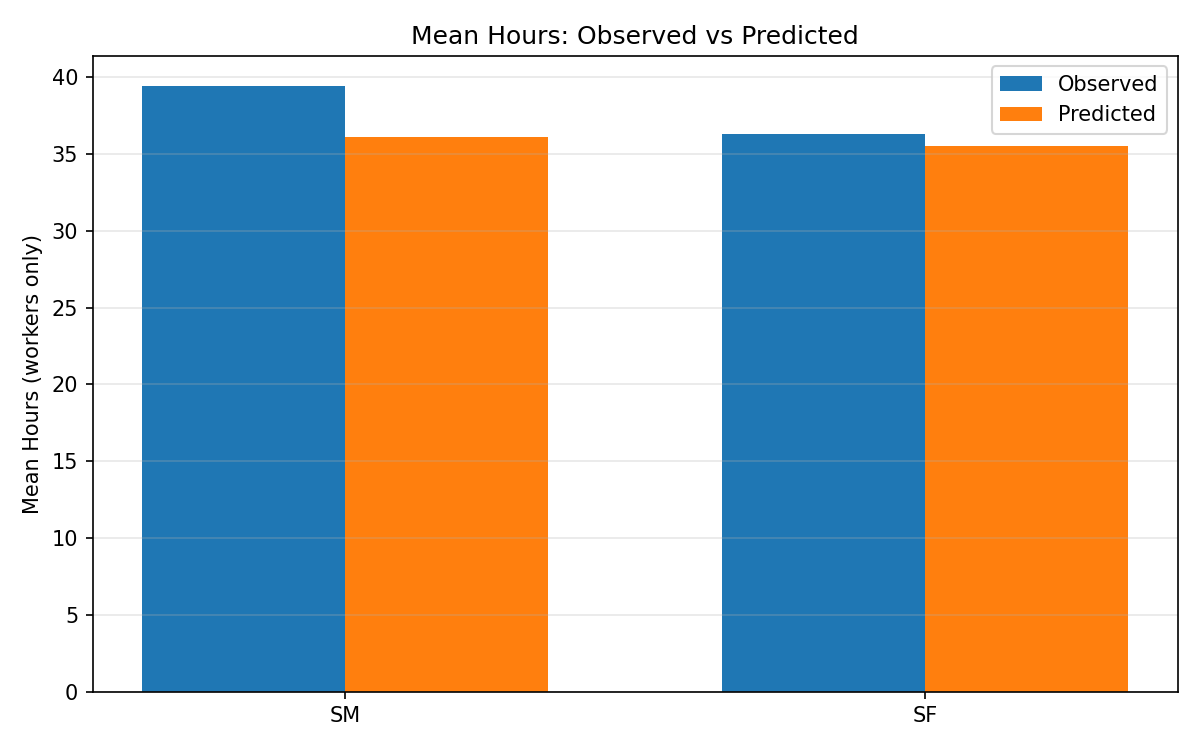

**fit_participation**

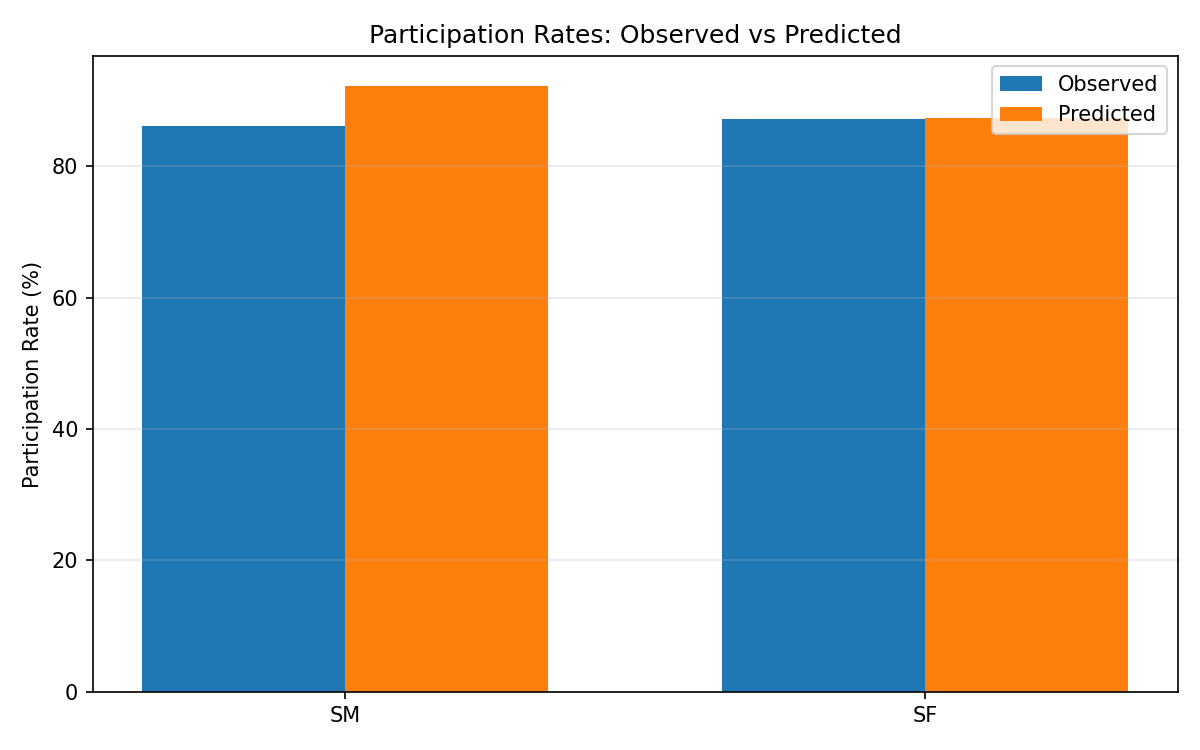

**hours_distribution_singles_female**

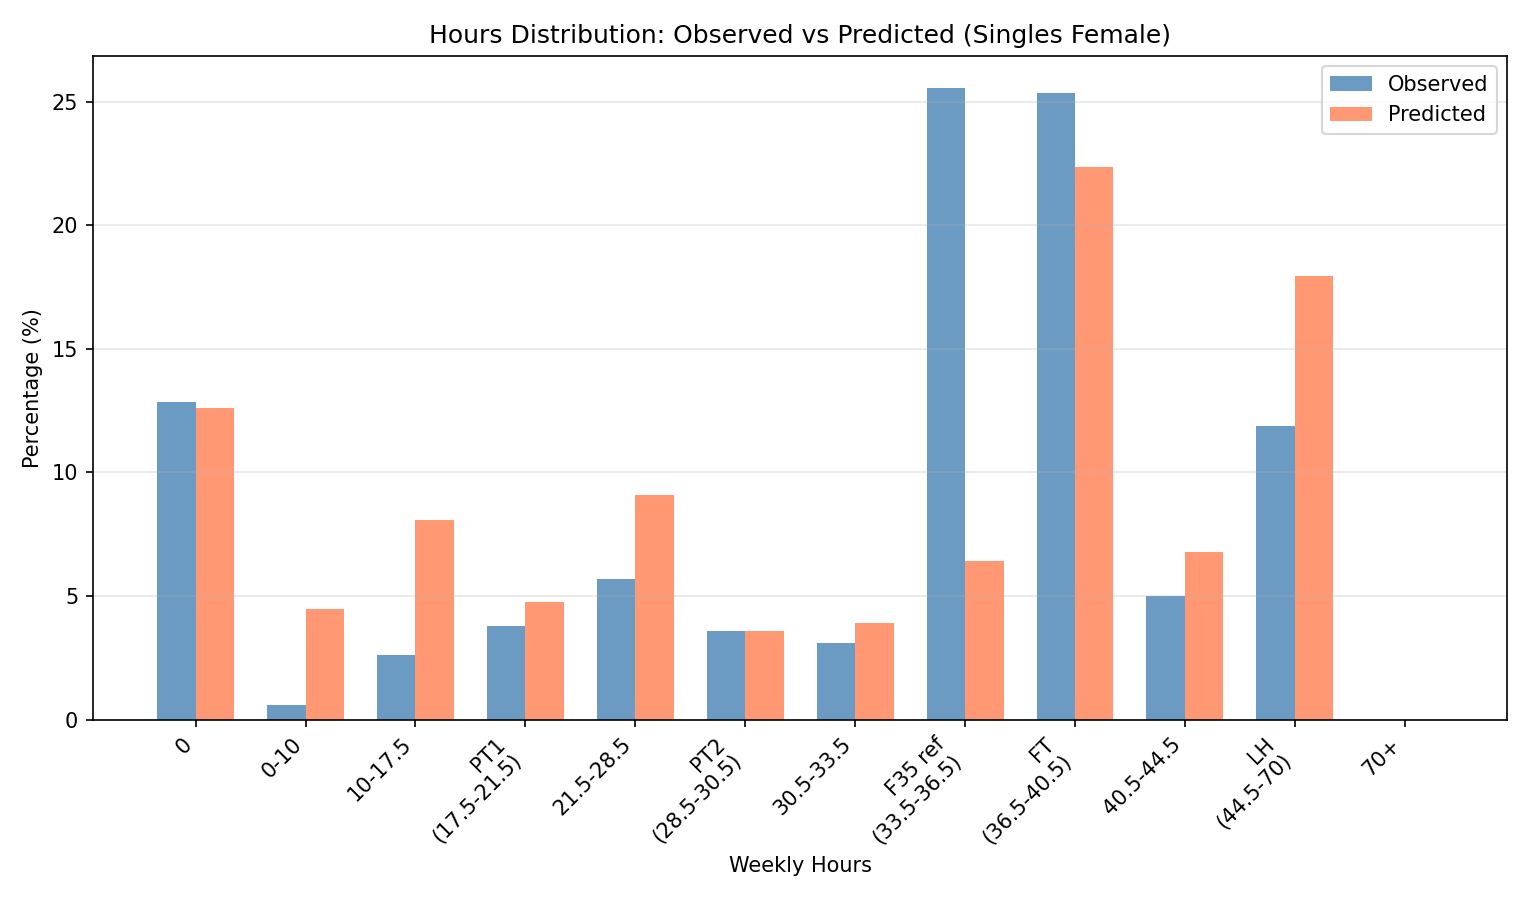

**hours_distribution_singles_male**

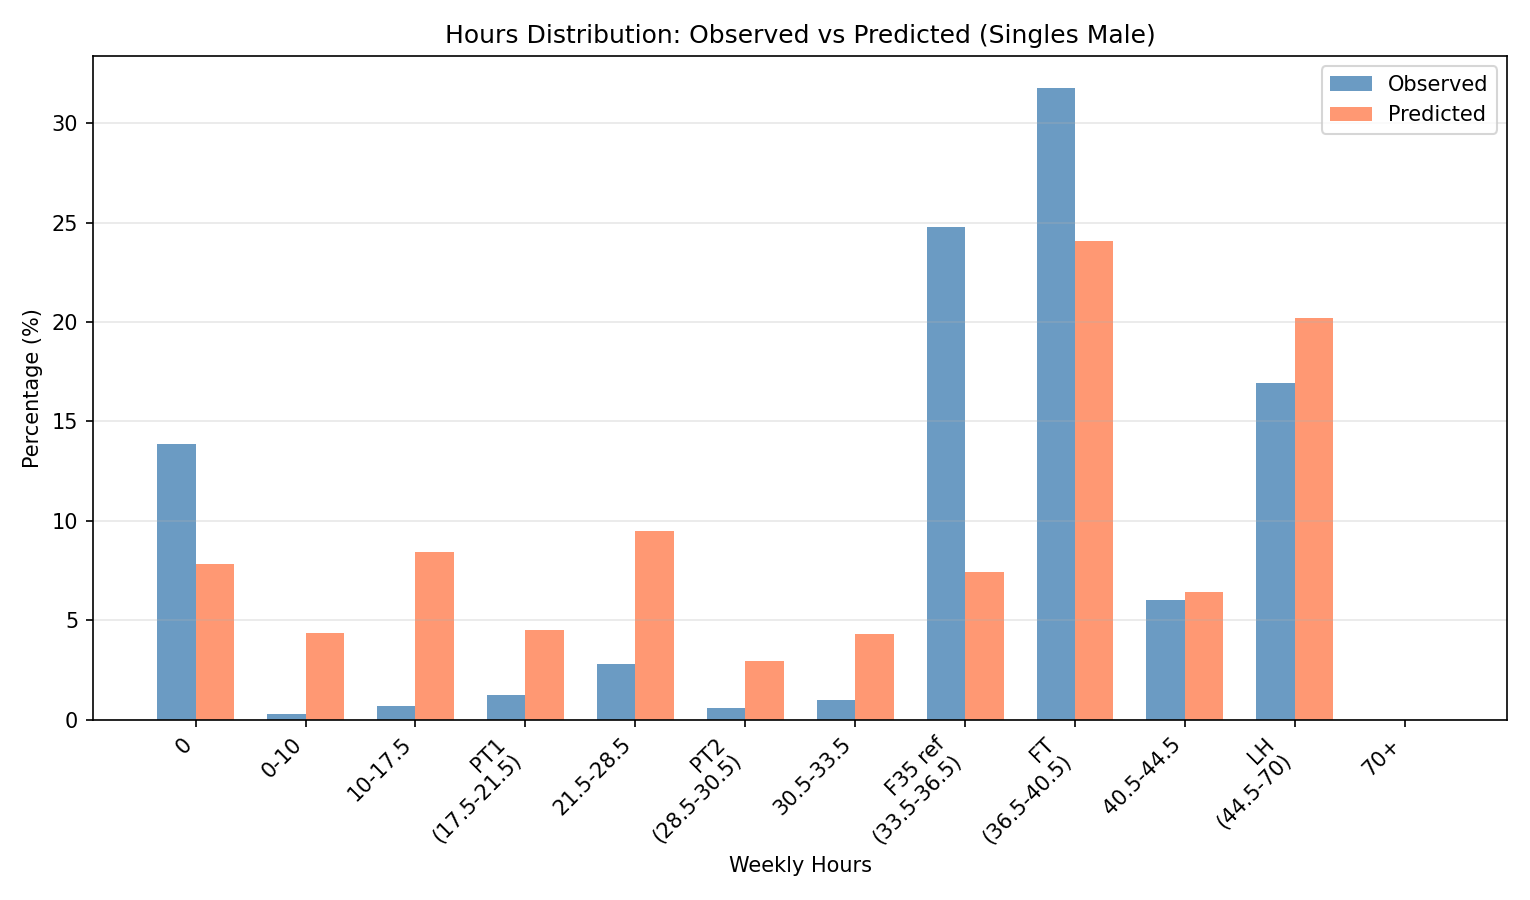

**hours_distribution_total**

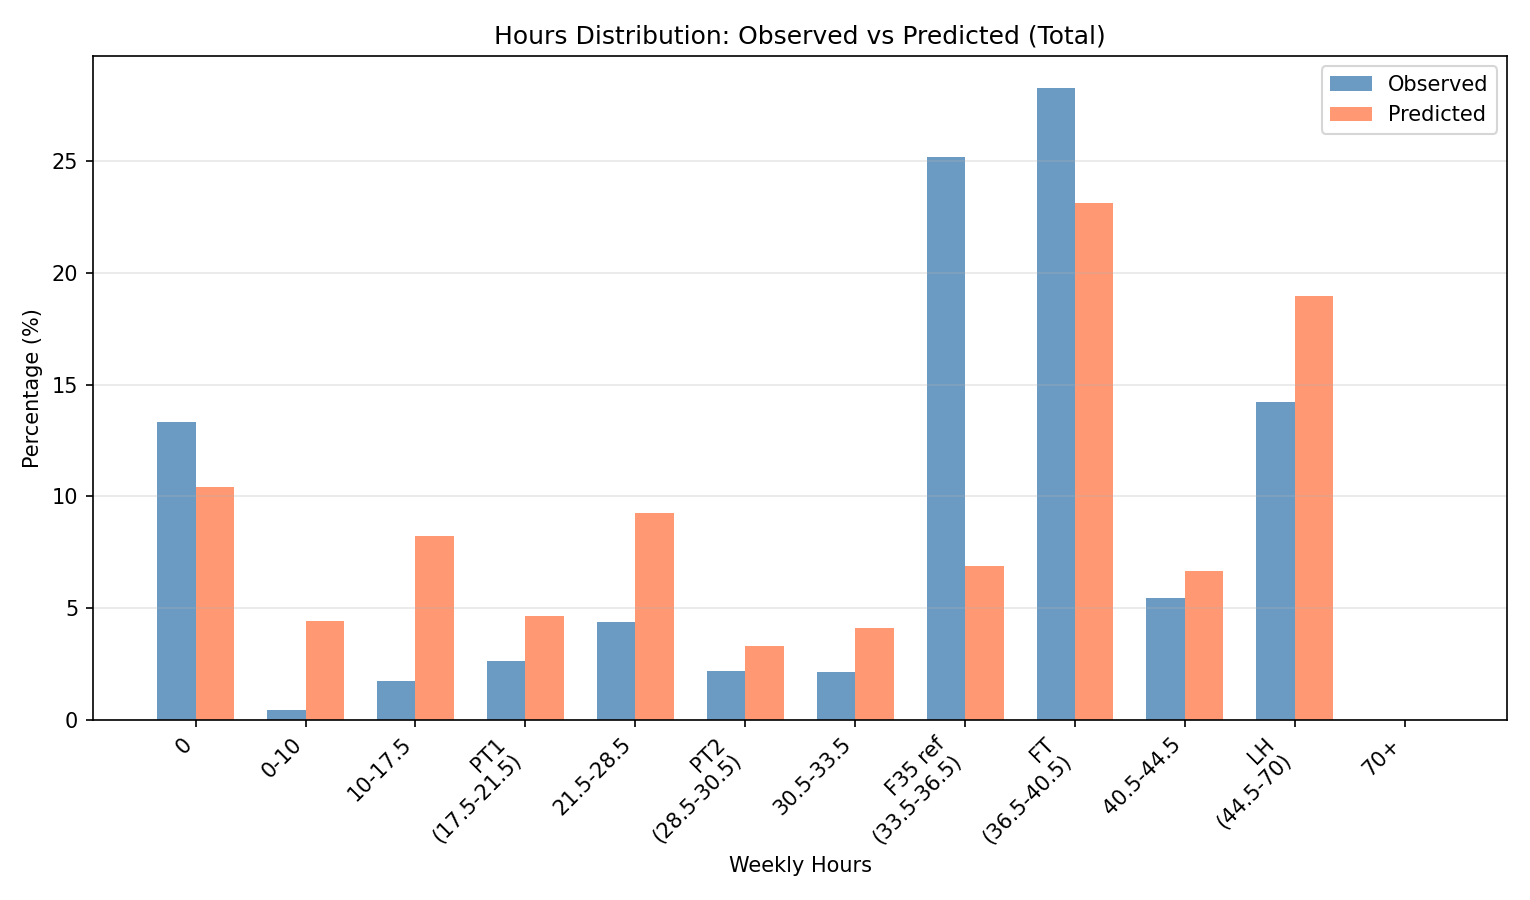

**muc_comparison**

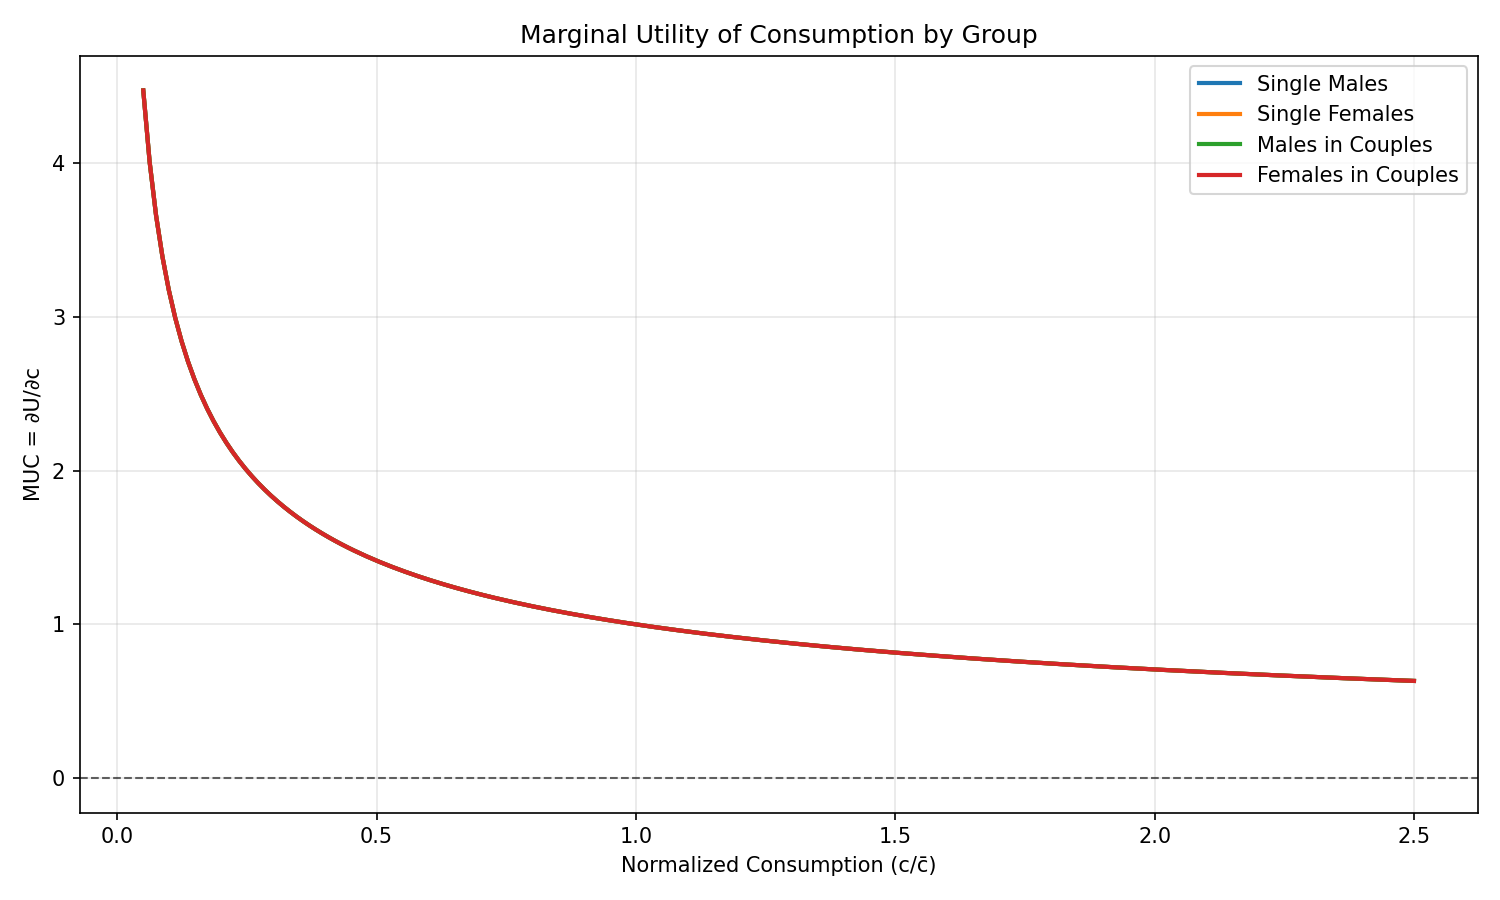

**mul_comparison**

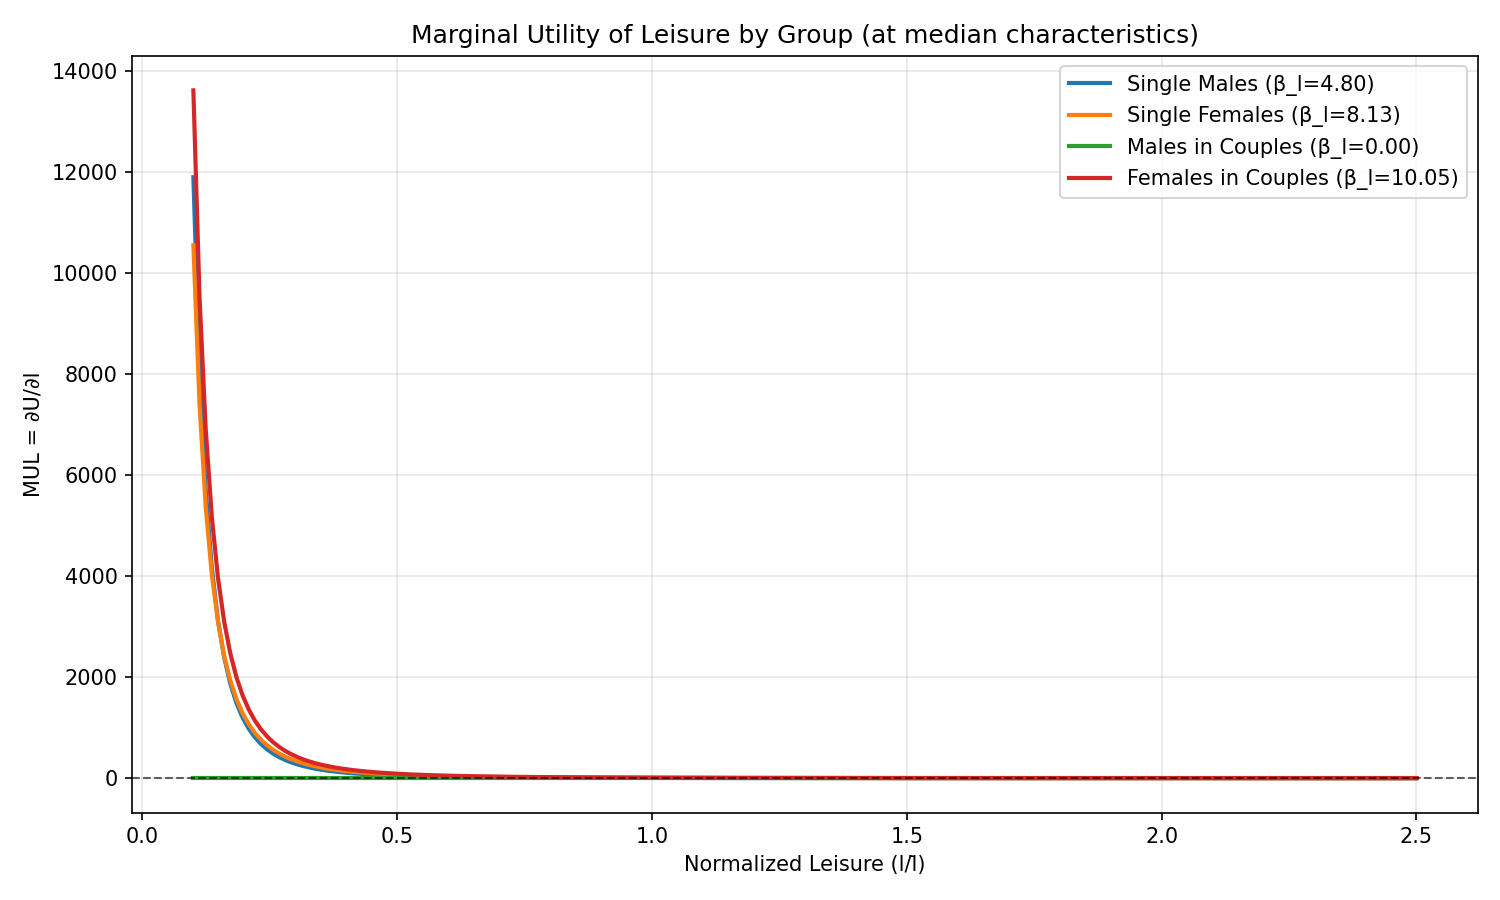

**negative_mu_diagnostics**

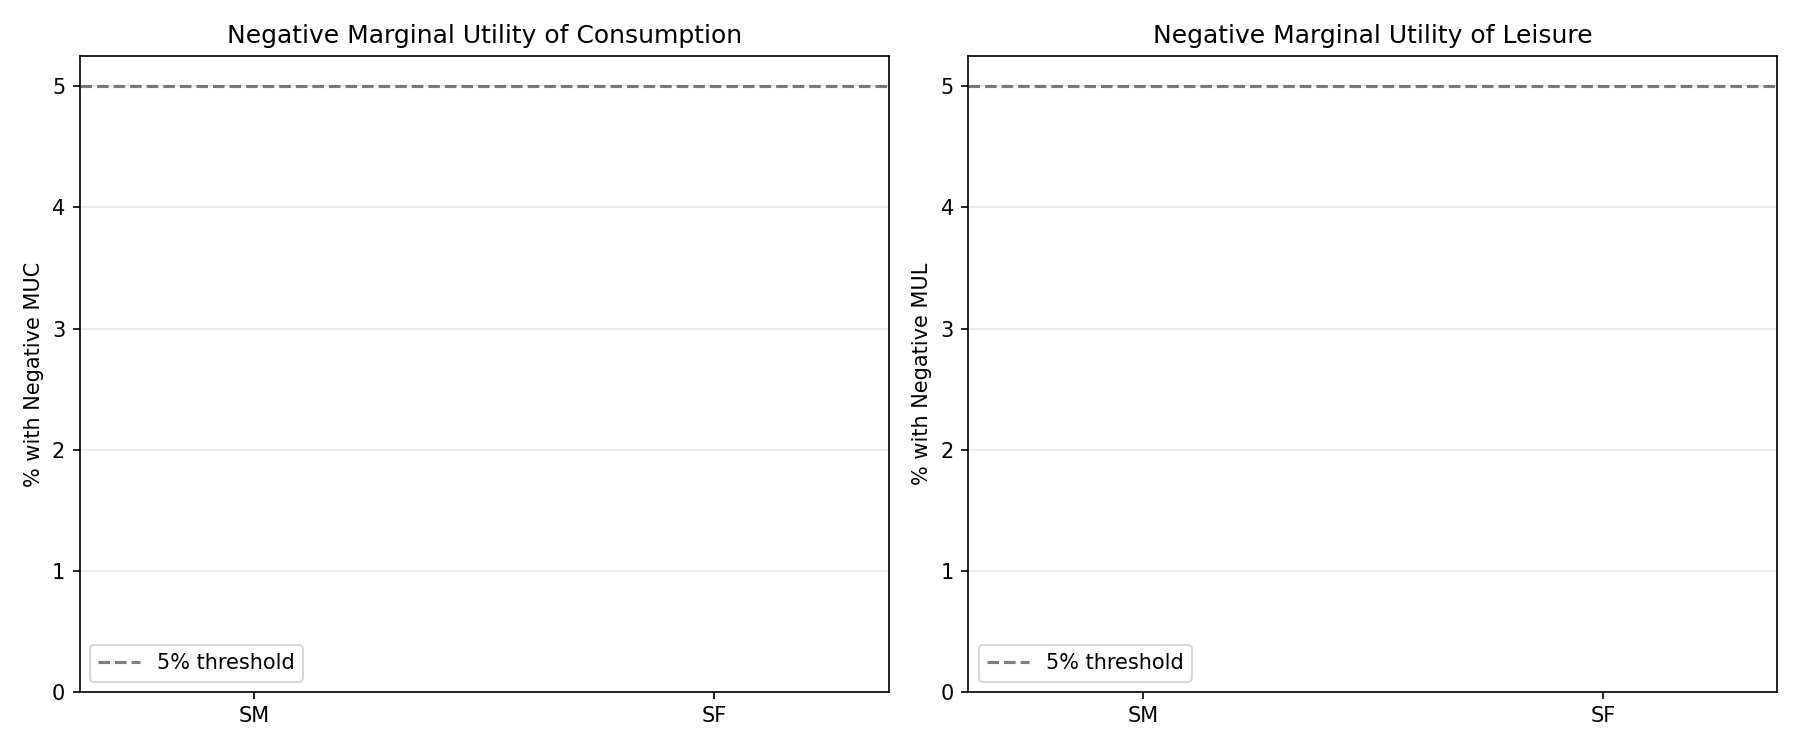

**sf_contours**

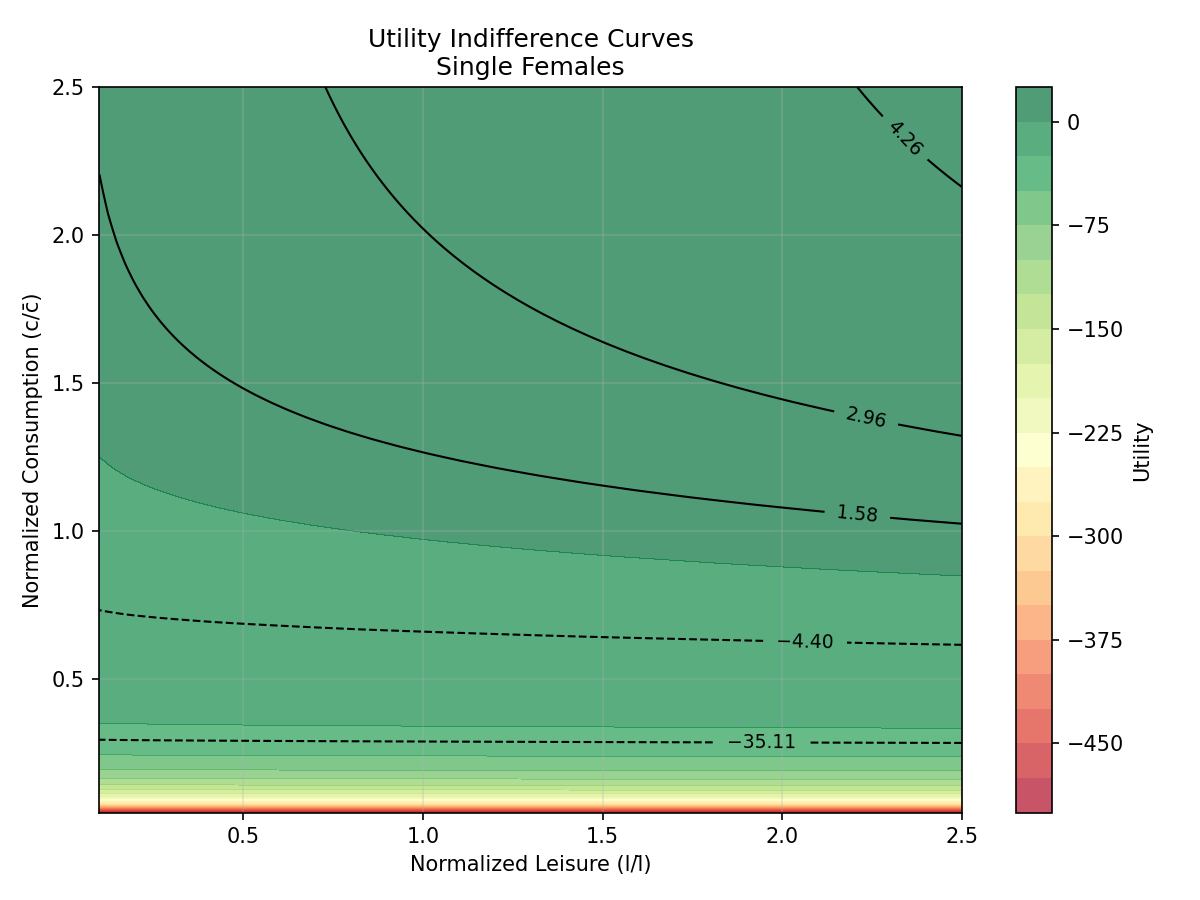

**sf_mu**

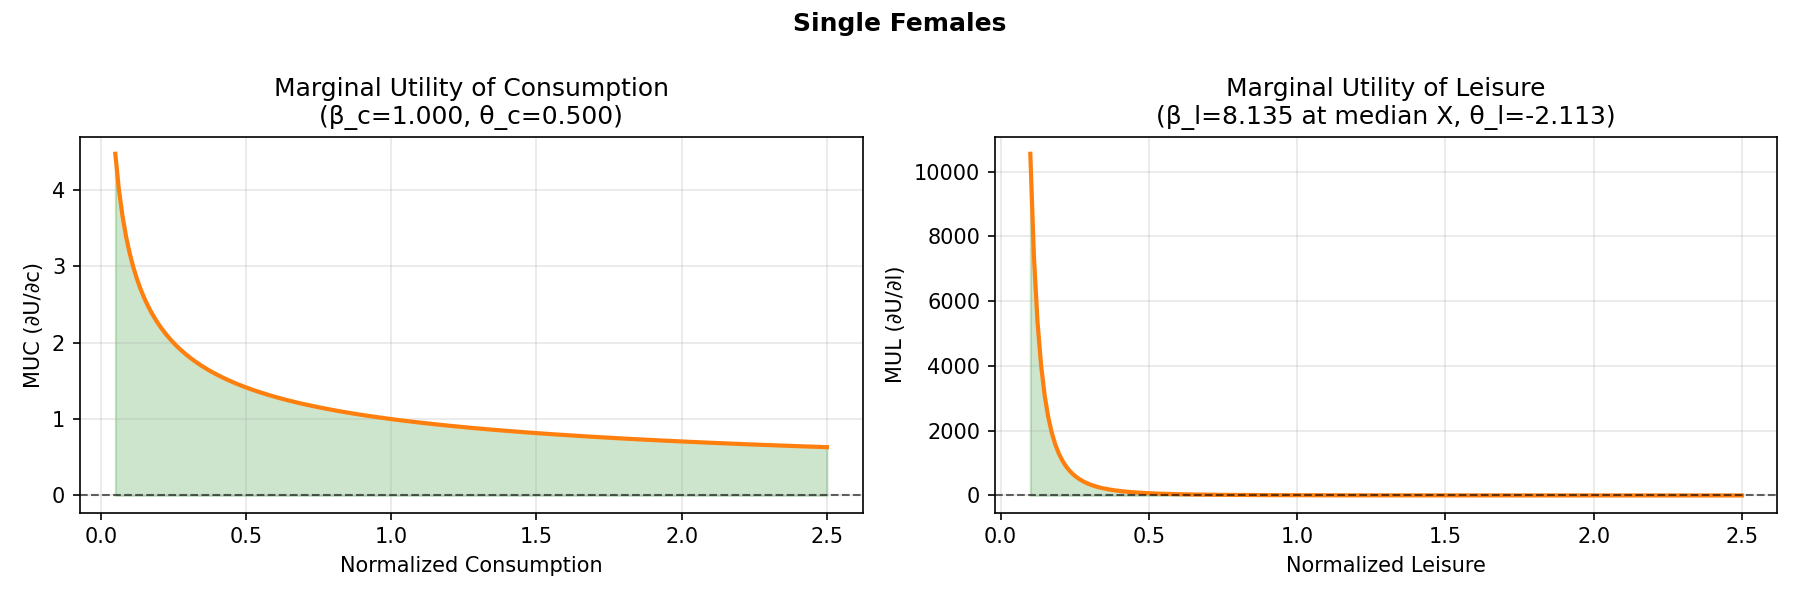

**sm_contours**

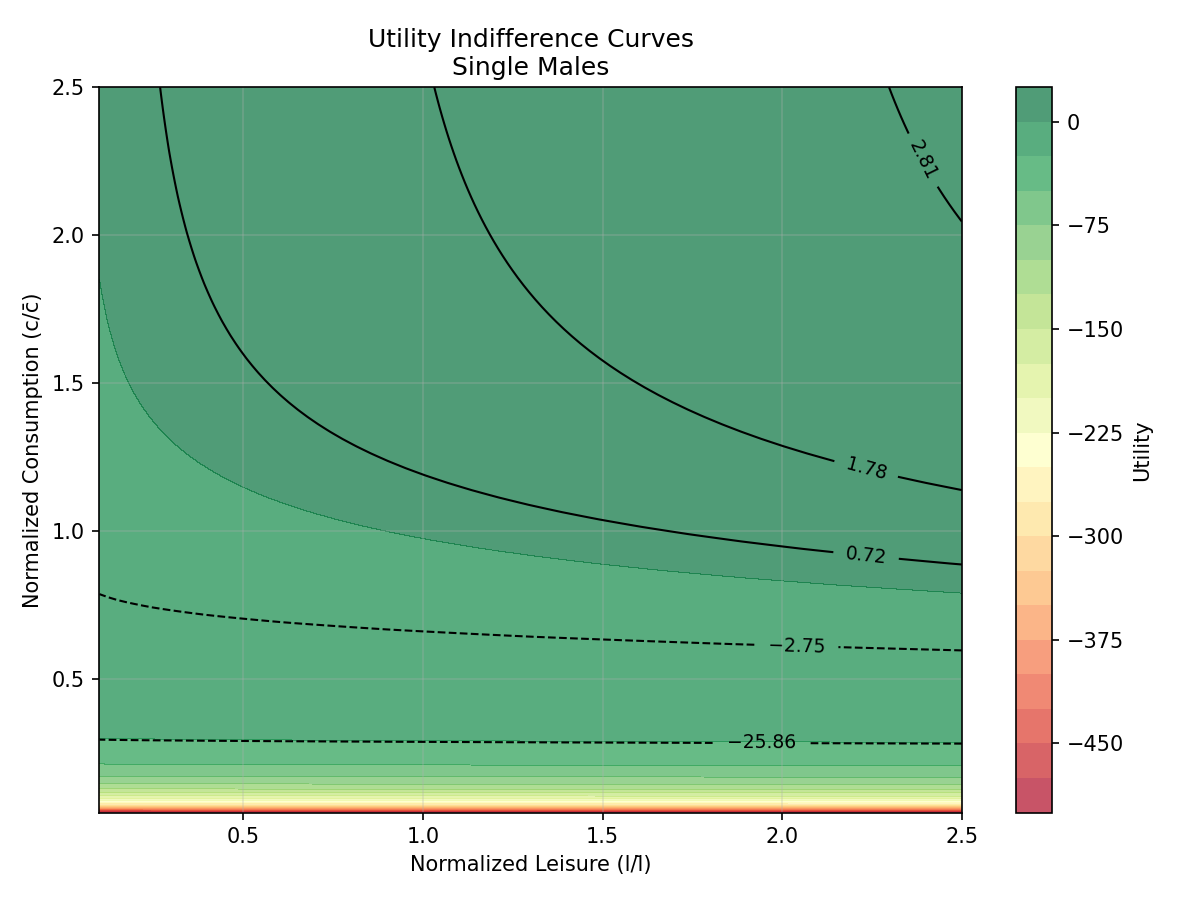

**sm_mu**

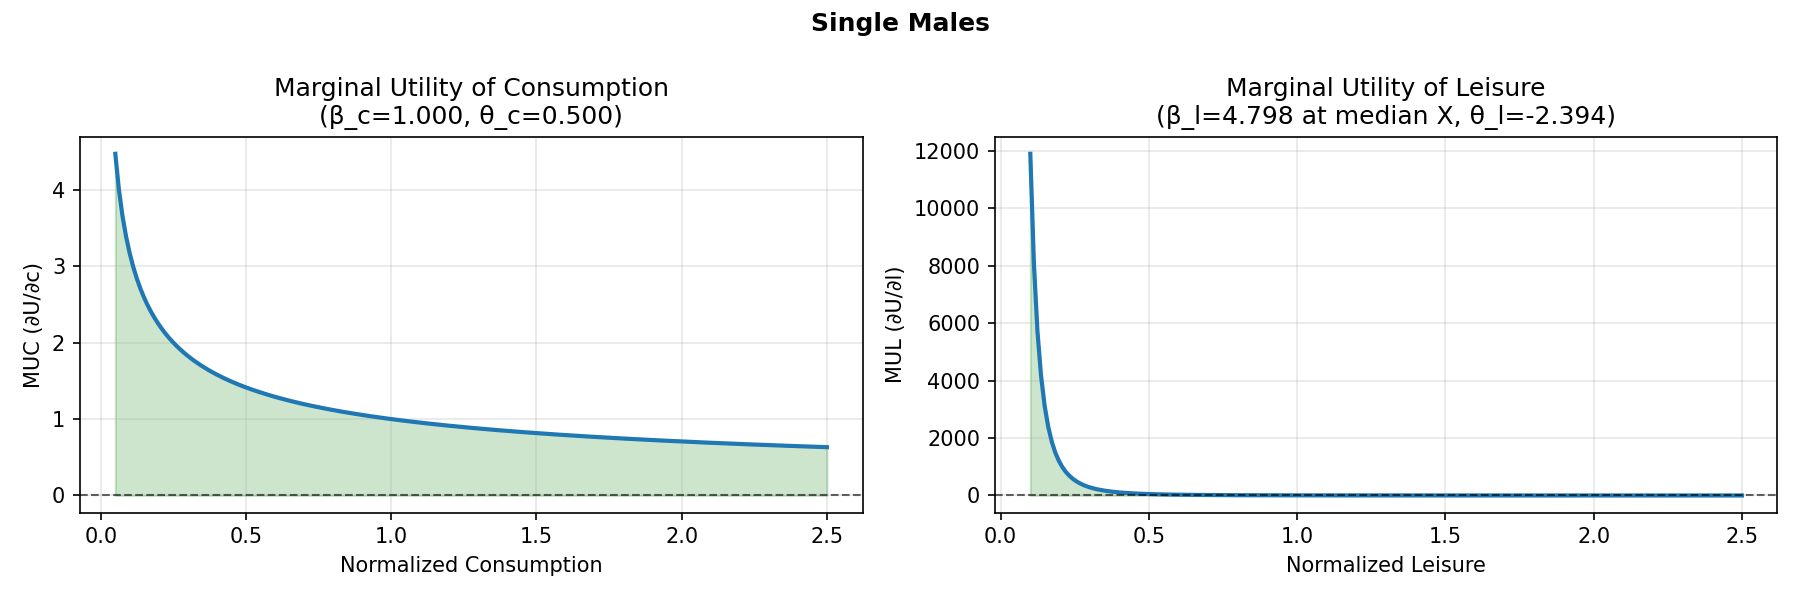

**wage_distribution_singles_female**

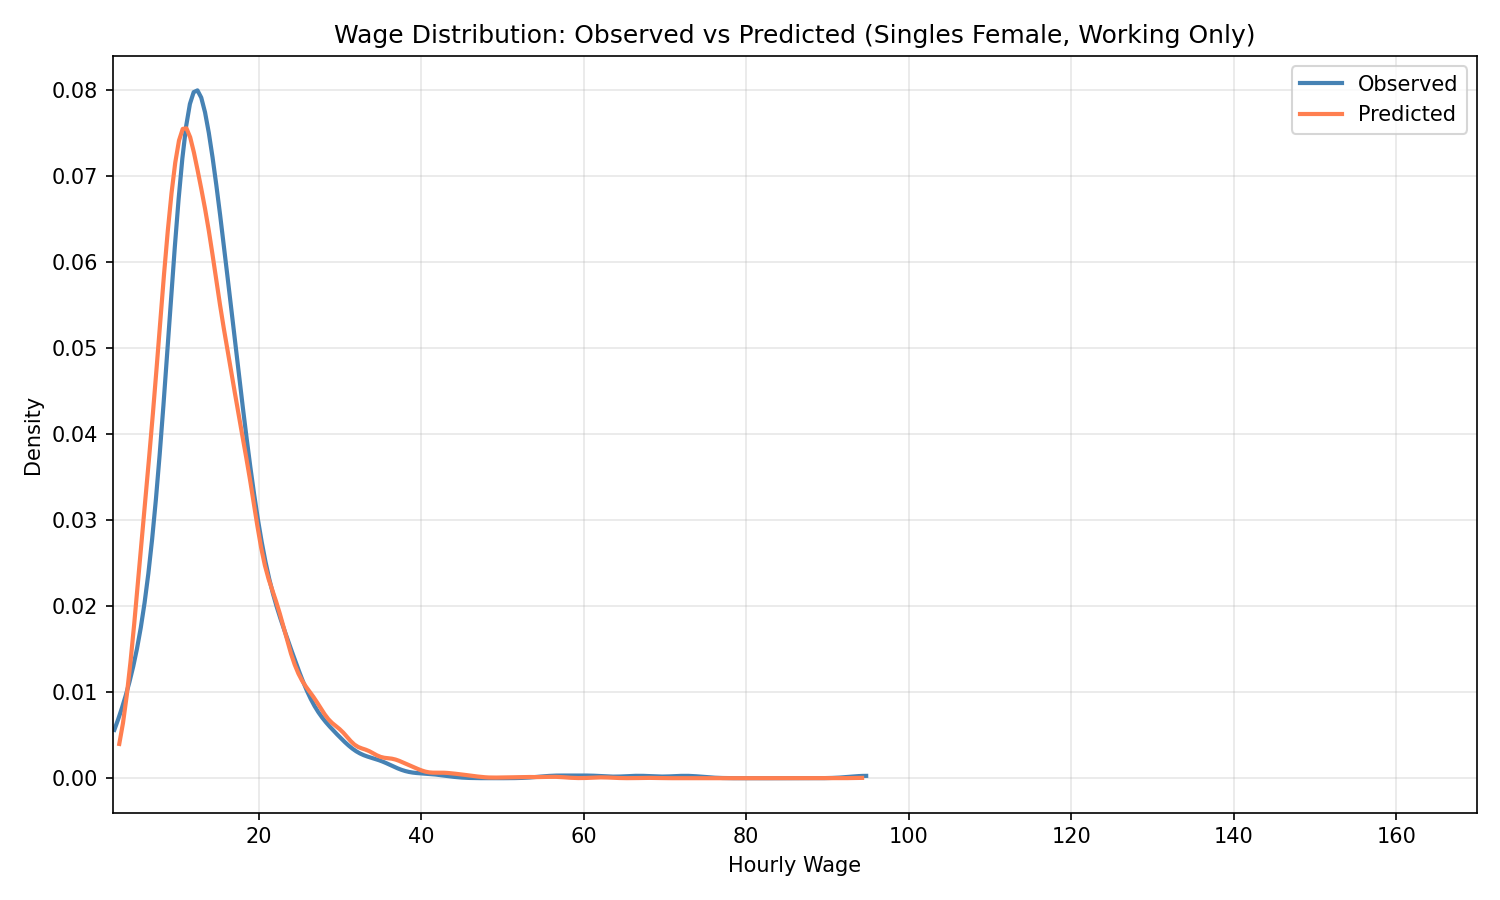

**wage_distribution_singles_male**

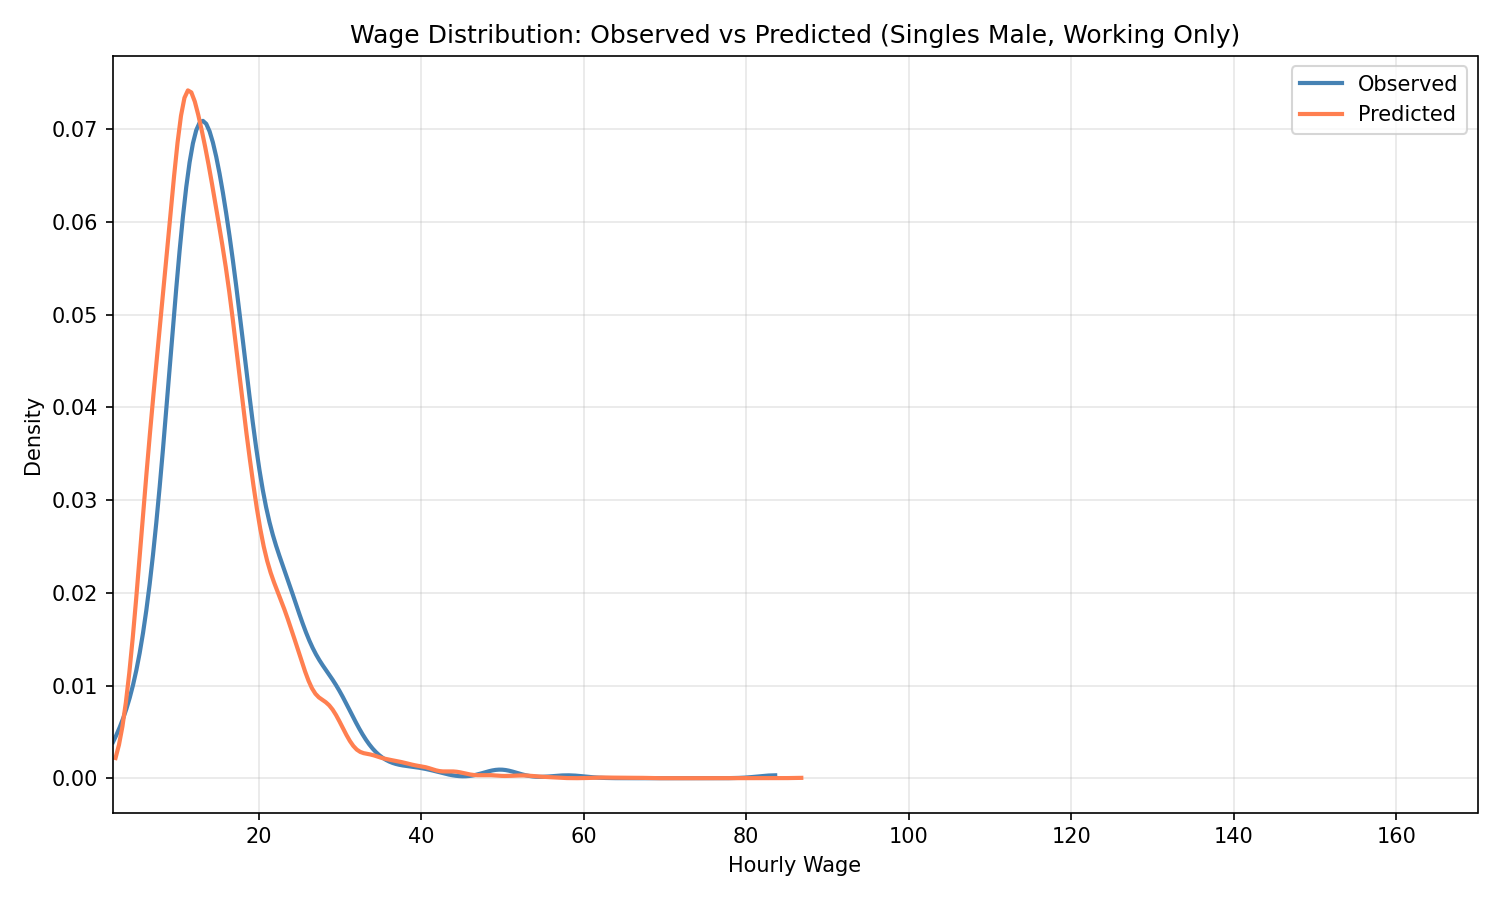

**wage_distribution_total**

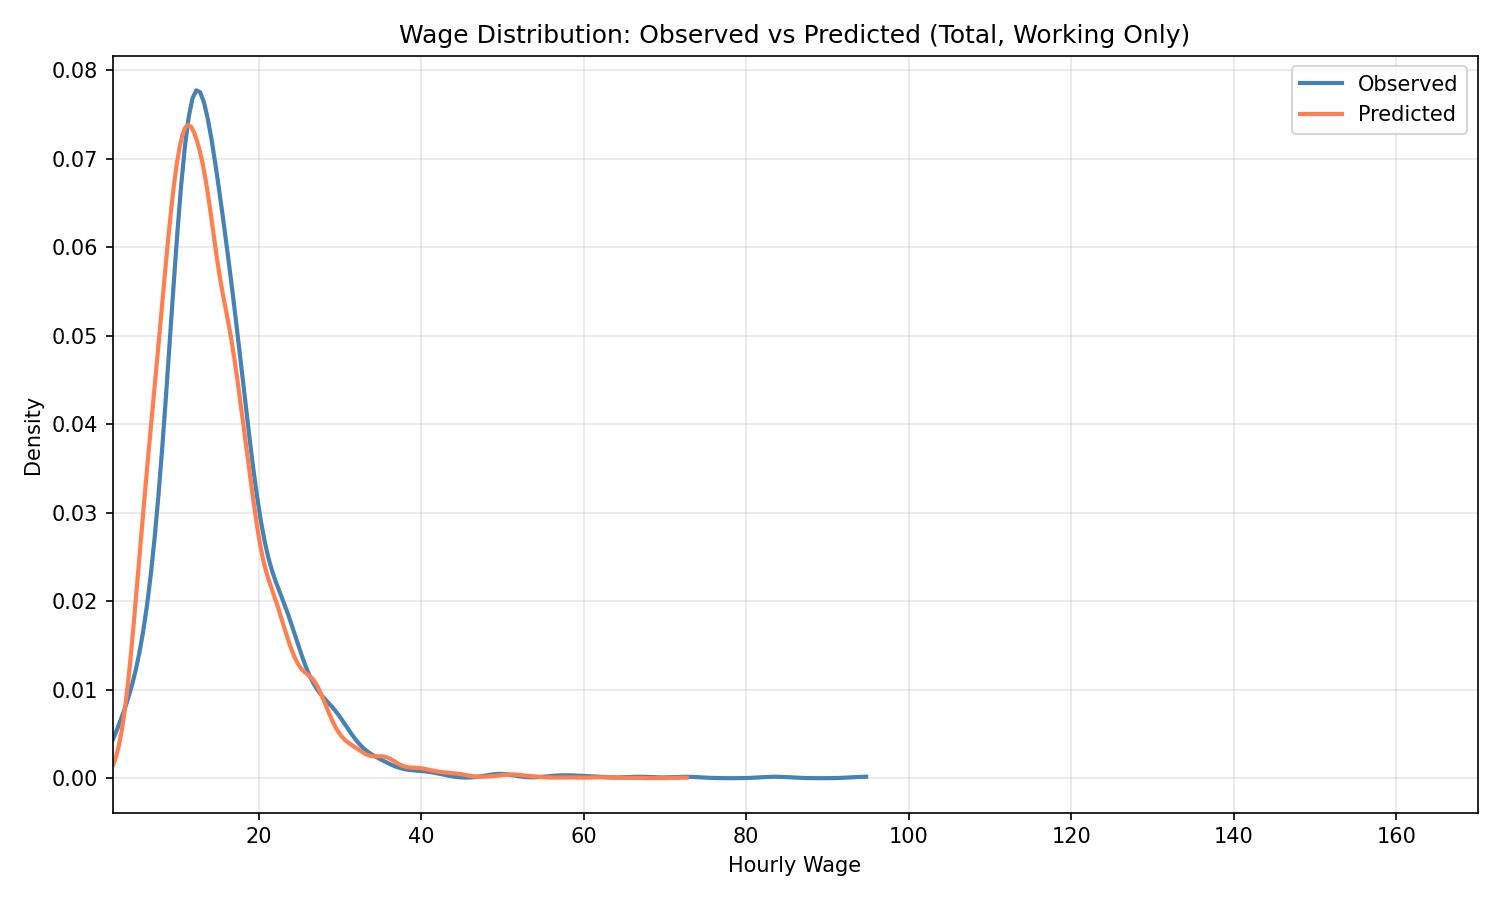

In [52]:
# ── 23. Post-estimation report — INLINE (singles trial; no HTML kept) ───────
# Runs RURO_post_estimation_styled.py into the trial folder, then displays the
# LLM summary + every diagnostic image right here. The *_llm_summary_*.md stays
# in outputs/trial_singles2016/; the HTML is discarded (we read it inline).
import subprocess, sys, glob, os
from pathlib import Path
from IPython.display import Image, Markdown, display

candidates = [Path.cwd(), Path.cwd().parent]
MNL_ROOT = next((p for p in candidates if (p / 'scripts/enhanced/RURO_post_estimation_styled.py').exists()), None)
if MNL_ROOT is None:
    raise FileNotFoundError('Could not locate MNL repo root (scripts/enhanced/RURO_post_estimation_styled.py).')

OUTDIR = MNL_ROOT / 'outputs/trial_singles2016'
PREFIX = 'trial_singles2016_'

# clean only PRIOR report artifacts (prefix-scoped) so nothing stale is re-displayed;
# inputs (fr_trial_singles2016__*, estimation_results_*.json) do NOT match this prefix.
for pat in (f'{PREFIX}*.png', f'{PREFIX}*.html', f'{PREFIX}llm_summary_*.md'):
    for f in OUTDIR.glob(pat):
        f.unlink()

cmd = [
    sys.executable, 'scripts/enhanced/RURO_post_estimation_styled.py',
    '--results-json', 'outputs/trial_singles2016/estimation_results_trial_singles2016.json',
    '--mnl-base',     'outputs/trial_singles2016/fr_trial_singles2016',
    '--spec-config',  'scripts/bpool/specs/estimation_spec_joint_pooled_v1_bll0_tlmpin.yaml',
    '--output-dir',   'outputs/trial_singles2016',   # PNGs land flat in the trial folder
    '--no-spec-subdir',                              # ...not a spec subdir
    '--llm-summary-dir', 'outputs/trial_singles2016',
    '--prefix',       PREFIX,
    '--cluster-col',  'idorighh',
]
print('running:', ' '.join(cmd))
r = subprocess.run(cmd, cwd=MNL_ROOT, capture_output=True, text=True)
tail = '\n'.join((r.stdout + r.stderr).splitlines()[-15:])
print(tail)
if r.returncode != 0:
    raise RuntimeError(f'post-estimation failed (exit {r.returncode}) — full stderr above')

# discard the HTML (we render everything inline) and the couples PNGs (no couples
# data in this singles trial -> pure redundancy, don't leave them on disk either)
for h in OUTDIR.glob(f'{PREFIX}*.html'):
    h.unlink()
    print('removed HTML:', h.name)
for cp in list(OUTDIR.glob(f'{PREFIX}cou_*.png')) + list(OUTDIR.glob(f'{PREFIX}couples*.png')):
    cp.unlink()

# 1) LLM summary markdown, inline
md_files = sorted(OUTDIR.glob(f'{PREFIX}llm_summary_*.md'), key=os.path.getmtime)
if md_files:
    print(f'\nkept summary: {md_files[-1].relative_to(MNL_ROOT)}')
    display(Markdown(md_files[-1].read_text(encoding='utf-8')))
else:
    print('WARNING: no *_llm_summary_*.md produced')

# 2) diagnostic images inline, deduped + sorted. Singles trial -> DROP the couples
# plots (cou_m/cou_f *_mu, *_contours): they are driven only by the pinned couples
# params, have no couples microdata behind them, and are pure redundancy here.
def _is_couples(stem):
    s = stem[len(PREFIX):]
    return s.startswith('cou_') or s.startswith('couples') or '_couples' in s
allpng = sorted({p.resolve() for p in OUTDIR.glob(f'{PREFIX}*.png')}, key=lambda p: p.name)
pngs = [p for p in allpng if not _is_couples(p.stem)]
dropped = [p.stem[len(PREFIX):] for p in allpng if _is_couples(p.stem)]
if dropped:
    print(f'\nsuppressed {len(dropped)} couples plot(s) (no couples data in this singles trial): {dropped}')
print(f'{len(pngs)} singles diagnostic image(s):')
for p in pngs:
    display(Markdown(f'**{p.stem[len(PREFIX):]}**'))
    display(Image(filename=str(p)))


In [53]:
# ── A. Provenance check → adapter re-run guard ──────────────────────────────
import json
prov = json.load(open('trial_fit_provenance.json'))
assert abs(prov['negll_fit'] - 4106.604220) < 1e-4, f"stale provenance: {prov['negll_fit']}"
print('provenance OK:', prov['negll_fit'], '| csv:', prov['theta_csv'])
# now re-run the agent's adapter cell (CSV = theta_trial_singles_2016_v3_final.csv),
# then verify the emitted JSON before reporting:
d = json.load(open('outputs/trial_singles2016/estimation_results_trial_singles2016.json'))
assert abs(d['results']['joint']['final_ll'] + 4106.604220) < 1e-4, 'JSON still stale'
print('results JSON consistent:', d['results']['joint']['final_ll'])

provenance OK: 4106.604220022093 | csv: theta_trial_singles_2016_v3_final.csv
results JSON consistent: -4106.604220022093


In [54]:
# ── 23. Cluster-robust SEs on the identified block ──────────────────────────
import jax, jax.numpy as jnp
from dclaborsupply.likelihood.engine_jax import build_jax_singles_ll

ll_m, _ = build_jax_singles_ll(data_sm, spec, is_male=True,  per_group=True)
ll_f, _ = build_jax_singles_ll(data_sf, spec, is_male=False, per_group=True)
th = jnp.asarray(res3.x)

S = np.vstack([np.asarray(jax.jacrev(ll_m)(th)), np.asarray(jax.jacrev(ll_f)(th))])  # (1555, 47) scores of +LL
g_chk = S.sum(axis=0) + np.asarray(val_grad(th)[1])          # T1: sum(scores) == -grad(negLL)
print('T1 sign check max|.|:', np.abs(g_chk).max())          # expect ~1e-8

cl = np.concatenate([sm_df.groupby('idhh', sort=False)['cluster_id'].first().to_numpy(),
                     sf_df.groupby('idhh', sort=False)['cluster_id'].first().to_numpy()])
assert len(cl) == S.shape[0]
uc = pd.unique(cl); print('clusters:', len(uc), '(single wave: ≈ one hh per cluster)')
B = np.zeros((len(names), len(names)))
for j in uc:
    s = S[cl == j].sum(axis=0); B += np.outer(s, s)           # meat

H = np.asarray(jax.jacfwd(jax.grad(total))(th))               # bread: Hessian of negLL, 47x47
AT_BOUND = ['beta_l_age2_sm', 'beta_l_age2_sf']
free_names = [n for n in names if n not in set(PINNED) | set(OCC) | set(AT_BOUND)]
fi = [idx[n] for n in free_names]
Hf, Bf = H[np.ix_(fi, fi)], B[np.ix_(fi, fi)]
eig = np.linalg.eigvalsh(Hf)
print(f'H_free: min eig {eig.min():.4f}  cond {eig.max()/max(eig.min(),1e-300):.3e}  (want min>0)')
Hinv = np.linalg.pinv(Hf)
V = Hinv @ Bf @ Hinv
se = pd.Series(np.sqrt(np.clip(np.diag(V), 0, None)), index=free_names, name='se_clustered')
se_h = pd.Series(np.sqrt(np.clip(np.diag(Hinv), 0, None)), index=free_names, name='se_hessian')

tab = pd.DataFrame({'estimate': [float(res3.x[idx[n]]) for n in free_names]},
                   index=free_names).join([se_h, se])
tab['t_robust'] = tab['estimate'] / tab['se_clustered']
tab['ratio_cl_h'] = tab['se_clustered'] / tab['se_hessian']
print(tab.round(4).to_string())
print('\nT5 ratio med/max:', tab['ratio_cl_h'].median().round(3), tab['ratio_cl_h'].max().round(3))
tab.to_csv('outputs/trial_singles2016/trial_se_clustered.csv')

# inject SEs into the results JSON so a report re-run renders t/p for the free block
d = json.load(open('outputs/trial_singles2016/estimation_results_trial_singles2016.json'))
d['results']['joint']['standard_errors'] = {n: float(se[n]) for n in free_names}
d['metadata']['se_method'] = ('cluster-robust sandwich, analytic per-household scores '
                              '(jacrev of per_group +LL), cluster=idorighh, free block = '
                              f'{len(free_names)} params (16 pinned + 2 at-bound excluded)')
json.dump(d, open('outputs/trial_singles2016/estimation_results_trial_singles2016.json', 'w'), indent=1)
print('SEs injected — re-run the report command for t/p columns')

T1 sign check max|.|: 3.133326931248348e-13
clusters: 1555 (single wave: ≈ one hh per cluster)
H_free: min eig 0.1246  cond 3.114e+05  (want min>0)
                 estimate  se_hessian  se_clustered  t_robust  ratio_cl_h
beta_l0_sm         4.7983      1.8140        2.5154    1.9075      1.3867
beta_l_age_sm      0.3700      1.1837        1.1860    0.3120      1.0019
theta_l_sm        -2.3943      0.3628        0.2605   -9.1926      0.7179
beta_l0_sf         8.1345      2.7302        4.1870    1.9428      1.5336
beta_l_age_sf     -0.9270      1.4671        1.2281   -0.7549      0.8371
beta_l_nkids_sf    1.4026      1.7076        1.5688    0.8941      0.9187
theta_l_sf        -2.1128      0.2858        0.2997   -7.0500      1.0486
theta_c_singles   -0.0771      0.0240        0.0692   -1.1135      2.8869
beta_E            -1.7284      0.3871        0.4365   -3.9599      1.1275
beta_h_pt1        -0.1636      0.1831        0.1774   -0.9224      0.9689
beta_h_pt2         0.1804      0.1943 

In [55]:
# ── 24. Conditional wage by occupation: the pre-committed arbiter ───────────
w = singles_dec[(pd.to_numeric(singles_dec['is_worker'])==1)
                & pd.to_numeric(singles_dec['loc4'], errors='coerce').isin([1,2,3,4])].copy()
w['lw'] = np.log(pd.to_numeric(w['yivwg'], errors='coerce'))
w['sex'] = np.where(w['female']==1, 'F', 'M')
lines = ['# Occupation wage-separation diagnostic (decision-note §4)', '']
for sex, g in w.groupby('sex'):
    q = g.groupby('loc4')['lw'].describe(percentiles=[.1,.25,.5,.75,.9]).round(3)
    grand = g['lw'].mean()
    ss_b = g.groupby('loc4')['lw'].agg(['count','mean']).eval('count*(mean-@grand)**2').sum()
    eta2 = ss_b / ((g['lw']-grand)**2).sum()
    iqr = g.groupby('loc4')['lw'].quantile([.25,.75]).unstack()
    lines += [f'## Sex {sex}  (n={len(g)})', f'eta^2(log wage ~ loc4) = **{eta2:.3f}**', '',
              q.to_markdown(), '', 'IQR by loc4: ' +
              ', '.join(f'{k}: [{v[0.25]:.2f},{v[0.75]:.2f}]' for k,v in iqr.iterrows()), '']
    print(f'{sex}: eta2={eta2:.3f}  n={len(g)}')
verdict = ('SEPARATED -> occupation-conditional wage draws at next rebuild (per pre-committed rule)'
           if True else '')  # fill from the printed eta2 vs the note's 0.10-0.15 / <0.05 guide
lines += ['## Verdict (rule: eta2>~0.10-0.15 => conditional; <0.05 => keep unconditional)',
          'DECISION: <fill after reading eta2, per pre-committed rule>',
          '', 'Caveat (per note §4): accepted-wage selection, flagged not fixed.']
open('outputs/trial_singles2016/occ_wage_separation_diagnostic.md','w').write('\n'.join(lines))
print('wrote occ_wage_separation_diagnostic.md — read eta2, apply the rule, fill DECISION')

F: eta2=0.213  n=730
M: eta2=0.128  n=611
wrote occ_wage_separation_diagnostic.md — read eta2, apply the rule, fill DECISION


In [56]:
# ── 25. Trial master record (LLM-first markdown) ────────────────────────────
md = f"""# FR 2016 Singles RURO Trial — Master Record
Sample: 1,555 single households (20-60), FR_2016_a3, priced FR_2015. negLL warm 4220.5238 -> fit **4106.6042** (31 free, 16 pinned, 2 at-bound).
## Frozen decisions
1. Working-alt benefit zeroing: components bind (bunct/bunmt/bsa zeroed; bsaot kept state-independent; input bsa00 inert). Probe-verified.
2. Take-up: bsa00yn_a=1 pricing (deterministic); household-trait mask, revealed-first (rates nw 0.548 / w 0.265), seeded Bernoulli 20162016. Rows adjusted 15,798.
3. pexp_years: liwwh/12 primary -> dew -> dey, cap dag-15, /20 rescale (certified enh_RURO_prep + harmonise). age_norm /10.
4. Occ block pinned at certified: unidentified under occ_spec='fixed' (ridge probe -0.0002; all 17,738 non-worker working draws imputed loc4=4).
5. beta_l_age2_sm/sf at certified bound 1.0 (widening->3.0 ran to bound for 2.28 nats; near-flat direction; MUC/MUL PASS at 1.0).
## Diagnostics verdicts
- MUC/MUL: 0% negative both sexes (threshold 5%) — PASS. Display quirk: MUC header theta_c=0.5 default; true theta_c_singles={float(res3.x[idx['theta_c_singles']]):.4f}.
- Wage fit: predicted~observed densities coincide (both sexes).
- Hours fit: 35h reference-band spike missed (25%->7%); low-hour bands overshot; male 0-hours 13.9% obs vs 7.8% pred. Cause: uniform hours proposal cannot form reference-band atom. -> P2 rebuild driver #2 (with occ sampling #1).
- SEs: see trial_se_clustered.csv (sandwich, analytic scores, cluster=idorighh; single-wave ~HC-robust).
## Artifacts
theta_trial_singles_2016_v3_final.csv | trial_fit_provenance.json | fr_singles_engine_ready_v5.parquet |
outputs/trial_singles2016/ (results JSON, report HTML, *_llm_summary_*.md, trial_se_clustered.csv, occ_wage_separation_diagnostic.md)
## Open for P2
Draws rebuild: peaked hours proposal (certified log_q_H atoms) + occupation-sampled dimension (+ conditional wages per Box-24 verdict); pooled 2015-17; couples; year effects unpin; LR pooling tests.
"""
open('outputs/trial_singles2016/TRIAL_MASTER_RECORD.md', 'w').write(md)
print('wrote TRIAL_MASTER_RECORD.md')

wrote TRIAL_MASTER_RECORD.md


In [57]:
# ── 26. Fill the pre-committed verdict + patch the master record ────────────
p = Path('outputs/trial_singles2016/occ_wage_separation_diagnostic.md')
txt = p.read_text().replace(
    'DECISION: <fill after reading eta2, per pre-committed rule>',
    'DECISION: SEPARATED (eta^2 F=0.213, M=0.128; both >= the 0.10-0.15 threshold) -> '
    'occupation-conditional wage draws ADOPTED for the next rebuild (P2), per the '
    'pre-committed rule in JMP_conditional_wage_on_occupation_decision_note_v1. '
    'Accepted-wage selection caveat flagged per note §4.')
p.write_text(txt); print('verdict filled')

m = Path('outputs/trial_singles2016/TRIAL_MASTER_RECORD.md')
rec = m.read_text().replace('report HTML', 'inline report (HTML discarded by design)')
rec += """
## Post-closure addenda
- Box-24 verdict: SEPARATED (eta^2 F=0.213, M=0.128) -> occupation-conditional wage draws adopted for P2.
- SE gates: T1 3.1e-13; H_free min eig 0.1246 (PD on identified block); T5 ratio med 1.115 / max 2.887.
- Interpretive notes: theta_c_singles weakly identified (t=-1.11, robust/Hessian ratio 2.89;
  indistinguishable from log utility -- pooling expected to tighten). beta_E_drgur/drgmd
  collapsed to ~0 from certified -0.53/-0.67: urbanization opportunity effect not found in
  singles-2016 alone (gsur strongly present instead, t=-4.15). Both are P2 hypotheses.
"""
m.write_text(rec); print('master record patched')

verdict filled
master record patched


In [58]:
# ── 27. REGRESSION ANCHOR — notebook self-verification (cold reload) ────────
from dclaborsupply.data.loader import load_singles
from dclaborsupply.likelihood.index import compute_index

_prov = json.load(open('trial_fit_provenance.json'))
_tab  = pd.read_csv(_prov['theta_csv']).set_index('param')['trial']
_er   = pd.read_parquet(_prov['engine_ready'])
_meta = {'normalization': {'singles': {'c_scale': float(_er['c_scale'].iloc[0]),
                                       'l_scale': float(_er['l_scale'].iloc[0])}}}
_dm = load_singles(_er[pd.to_numeric(_er['dgn'])==1].reset_index(drop=True), spec, is_male=True,  metadata=_meta)
_df = load_singles(_er[pd.to_numeric(_er['dgn'])==0].reset_index(drop=True), spec, is_male=False, metadata=_meta)
_th = np.array([float(_tab[n]) for n in spec.all_param_names])
_nll = float(compute_index(spec, (_dm, _df, None), _th, ruro=True, backend='numpy'))
print(f'anchor negLL = {_nll:.6f}  (target 4106.604220)')
assert abs(_nll - 4106.604220) < 1e-4, 'TRIAL ANCHOR BROKEN — environment/package/data changed'
print('TRIAL ANCHOR HOLDS — notebook self-verified.')

anchor negLL = 4106.604220  (target 4106.604220)
TRIAL ANCHOR HOLDS — notebook self-verified.


In [59]:
# ── P2a-0. Certified draw modules: import + signatures + 5-person smoke ─────
import sys, inspect, importlib, json
from pathlib import Path
import numpy as np

# locate MNL repo root (works whether the kernel cwd is repo root or the notebook dir)
MNL_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'scripts/bpool/hours_mixture_d1.py').exists()), None)
if MNL_ROOT is None:
    raise FileNotFoundError('Could not locate MNL repo root (scripts/bpool/hours_mixture_d1.py).')
# the three modules import each other by BARE name (see build_bpool_singles.py) -> put
# their dirs on sys.path and import by bare name, exactly as the production builder does.
for sub in ('scripts/bpool', 'scripts/pilot'):
    d = str(MNL_ROOT / sub)
    if d not in sys.path:
        sys.path.insert(0, d)

mods = {n: importlib.import_module(n)
        for n in ['hours_mixture_d1', 'occ_draw_empirical', 'pilot_wage_draw']}
for name, m in mods.items():
    print(f'== {name} -> {m.__file__}')
    for fn, o in vars(m).items():
        if inspect.isfunction(o) and not fn.startswith('_'):
            print(f'   {fn}{inspect.signature(o)}')
print('missing: none — all three importable')

MINCER = MNL_ROOT / 'scripts/pilot/config/pilot_mincer_coefficients_v1.json'  # note: config/ subdir
assert MINCER.is_file(), f'mincer json not found: {MINCER}'
mc = json.load(open(MINCER))
print('mincer wage_model_W1 keys:', list(mc['wage_model_W1'].keys()),
      '| sigma:', round(mc['wage_model_W1']['sigma'], 6))

# ── 5-person smoke: hours (D1) → loc4 (empirical) → wage (W1), with lockstep log_q ──
rng = np.random.default_rng(0)
n = 5
dgn   = np.array([1, 1, 0, 0, 1]); educ3 = np.array([0, 1, 2, 0, 2])
hours, lq_h = mods['hours_mixture_d1'].draw_hours_d1(n, rng)
loc4,  lq_o = mods['occ_draw_empirical'].draw_loc4(dgn, educ3, rng)
wres = mods['pilot_wage_draw'].draw_pilot_wages(
    n=n, educL=(educ3 == 0).astype(float), educH=(educ3 == 2).astype(float),
    pexp_years=np.full(n, 15.0), pexp_years2=np.full(n, 225.0),
    loc4=loc4, year_tag=np.full(n, 2), mincer_payload=mc, seed=0, draw_method='halton')
print('\n5-person working smoke:')
for i in range(n):
    print(f'  dgn={dgn[i]} educ3={educ3[i]} | hours={hours[i]:5.1f} loc4={loc4[i]} '
          f'wage={wres["wage"][i]:6.2f} | log_q_H={lq_h[i]:+.3f} log_q_Occ={lq_o[i]:+.3f} '
          f'log_q_W={wres["log_q_wage"][i]:+.3f}')
# log_prior for a WORKING alt = log(1-pi0) + log_q_H + log_q_W + log_q_Occ
lp = np.log(0.9) + lq_h + lq_o + np.asarray(wres['log_q_wage'])
print('  log_prior (working) =', np.round(lp, 3), '| wage draw method:', wres['method'])


== hours_mixture_d1 -> c:\Users\hisham\Repo\MNL\scripts\bpool\hours_mixture_d1.py
   draw_hours_d1(n: 'int', rng: 'np.random.Generator', weights: 'np.ndarray | None' = None) -> 'tuple[np.ndarray, np.ndarray]'
   log_q_H_d1(hours: 'np.ndarray', weights: 'np.ndarray | None' = None) -> 'np.ndarray'
   lockstep_check_d1(hours: 'np.ndarray', log_q_H_drawn: 'np.ndarray', component_k: 'np.ndarray', weights: 'np.ndarray | None' = None, rtol: 'float' = 1e-06) -> 'dict'
   hours_bin_summary(hours_chosen: 'np.ndarray', weights: 'np.ndarray | None' = None) -> 'dict'
== occ_draw_empirical -> c:\Users\hisham\Repo\MNL\scripts\bpool\occ_draw_empirical.py
   draw_loc4(dgn: 'np.ndarray', educ3: 'np.ndarray', rng: 'np.random.Generator') -> 'tuple[np.ndarray, np.ndarray]'
   log_q_loc4(loc4: 'np.ndarray', dgn: 'np.ndarray', educ3: 'np.ndarray') -> 'np.ndarray'
== pilot_wage_draw -> c:\Users\hisham\Repo\MNL\scripts\pilot\pilot_wage_draw.py
   draw_pilot_wages(*, n: 'int', educL: 'np.ndarray', educH: 'np.nd

In [60]:
# ── P2a-1. Rebuild singles draws under the CERTIFIED B-pool design ──────────
# Mirrors scripts/bpool/build_bpool_singles.py (draw loop) + its three modules.
# Produces draws_p2a (n_hh * 101 rows) with the certified log_q design on singles_dec.
import sys, json
from pathlib import Path
import numpy as np, pandas as pd

MNL_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'scripts/bpool/build_bpool_singles.py').exists()), None)
assert MNL_ROOT, 'MNL repo root not found (scripts/bpool/build_bpool_singles.py)'
for sub in ('scripts/bpool', 'scripts/pilot'):
    d = str(MNL_ROOT / sub)
    if d not in sys.path:
        sys.path.insert(0, d)
import hours_mixture_d1 as HM      # D1 six-uniform mixture   -> draw_hours_d1  (imported build_bpool_singles.py:52)
import occ_draw_empirical as OE    # empirical (dgn,educ3) loc4 -> draw_loc4, FREQ_TABLE      (:53)
import pilot_wage_draw as PW       # W1 occ-conditional lognormal -> draw_pilot_wages          (:54)
MINCER = MNL_ROOT / 'scripts/pilot/config/pilot_mincer_coefficients_v1.json'  # build_bpool_singles.py:67-69
mc = json.load(open(MINCER))
sigma = float(mc['wage_model_W1']['sigma'])

# constants mirror build_bpool_singles.py:59-62
N_DRAWS, PI0 = 100, 0.10
LOG_PI0, LOG_1_PI0 = np.log(PI0), np.log(1.0 - PI0)
YEAR_TAG = 2   # year_tag absent -> 2016 reference (1=2015,2=2016,3=2017); wage shifts only for ==1/==3

req = ['idhh', 'idperson', 'dgn', 'educ3', 'educL', 'educH',
       'pexp_years_raw', 'lhw', 'yivwg', 'loc4', 'is_worker']
miss = [c for c in req if c not in singles_dec.columns]
assert not miss, f'singles_dec missing required columns: {miss}'

carry_cols = [c for c in singles_dec.columns if c != 'loc4']   # loc4 is set per-alt (drawn)

# per-household child seeds — EXACT mirror of build_bpool_singles.py:307-308
ids = singles_dec['idhh'].to_numpy()
_seed_rng = np.random.default_rng(2026)                                   # :307  default_rng(seed=2026)
hh_seeds = {int(uid): int(_seed_rng.integers(0, 2**31)) for uid in ids}   # :308  per-uid child seed

def _band_flags(h, wk):   # mirror build_bpool_singles.py:216-219 (F35 = reference, no flag)
    return (float((36.5 <= h <= 40.5) and wk), float((17.5 <= h < 21.5) and wk),
            float((28.5 <= h < 30.5) and wk), float((44.5 <= h <= 70.0) and wk))

blocks = []
for r in singles_dec.to_dict('records'):
    uid = int(r['idhh'])
    hh_rng = np.random.default_rng(hh_seeds[uid])   # :315  per-HH PCG64 (employment/occ/hours)
    seed = hh_seeds[uid]                             # :316  wage Halton seed
    dgn, educ3 = int(r['dgn']), int(r['educ3'])
    educL, educH = float(r['educL']), float(r['educH'])
    pexp = float(r['pexp_years_raw']); pexp2 = pexp * pexp

    # employment  (mirror :119-123)
    u = hh_rng.uniform(size=N_DRAWS)
    working = (u >= PI0).astype(np.int8); nwk = int(working.sum())
    lqE = np.where(working == 1, LOG_1_PI0, LOG_PI0)
    # occupation (mirror :128-136)
    loc4 = np.full(N_DRAWS, -1, dtype=np.int32); lqO = np.zeros(N_DRAWS)
    # hours      (mirror :141-147)
    hours = np.zeros(N_DRAWS); lqH = np.zeros(N_DRAWS)
    # wage       (mirror :152-170)
    wage = np.zeros(N_DRAWS); lqW = np.zeros(N_DRAWS); wmu = np.full(N_DRAWS, np.nan)
    if nwk > 0:
        l4, lo = OE.draw_loc4(np.full(nwk, dgn), np.full(nwk, educ3), hh_rng)
        loc4[working == 1] = l4; lqO[working == 1] = lo
        h, lh = HM.draw_hours_d1(nwk, hh_rng)
        hours[working == 1] = h; lqH[working == 1] = lh
        res = PW.draw_pilot_wages(n=nwk, educL=np.full(nwk, educL), educH=np.full(nwk, educH),
                                  pexp_years=np.full(nwk, pexp), pexp_years2=np.full(nwk, pexp2),
                                  loc4=loc4[working == 1], year_tag=np.full(nwk, YEAR_TAG),
                                  mincer_payload=mc, seed=seed, draw_method='halton')
        wage[working == 1] = res['wage']; lqW[working == 1] = res['log_q_wage']; wmu[working == 1] = res['mu']
    # log_prior: build_bpool_singles.py:175-177 sums (Occ+H+W); we sum in the LOADER's order
    # (H+W+Occ, engine_ready.py:289) so the wave01 identity holds bit-exactly downstream.
    lp = lqE + working.astype(np.float64) * (lqH + lqW + lqO)

    sim = pd.DataFrame({c: [r[c]] * N_DRAWS for c in carry_cols})
    sim['draw'] = np.arange(1, N_DRAWS + 1); sim['is_chosen'] = np.int8(0)
    sim['working'] = working.astype(float); sim['hours'] = hours; sim['wage'] = wage; sim['loc4'] = loc4.astype(float)
    sim['log_q_E'] = lqE; sim['log_q_H'] = lqH; sim['log_q_W'] = lqW; sim['log_q_Occ'] = lqO
    sim['log_prior'] = lp; sim['wage_mu'] = wmu
    hh = sim['hours'].to_numpy(); wkm = (sim['working'] == 1).to_numpy()
    sim['working_ft']  = ((hh >= 36.5) & (hh <= 40.5) & wkm).astype(float)
    sim['working_pt1'] = ((hh >= 17.5) & (hh <  21.5) & wkm).astype(float)
    sim['working_pt2'] = ((hh >= 28.5) & (hh <  30.5) & wkm).astype(float)
    sim['working_lh']  = ((hh >= 44.5) & (hh <= 70.0) & wkm).astype(float)

    # chosen row (draw==0): observed values preserved, all log_q=0, log_prior=0 (IS anchor; :224-267)
    ch = pd.DataFrame({c: [r[c]] for c in carry_cols})
    ch_h = float(r['lhw']); ch_wk = int(r['is_worker']) == 1
    ch['draw'] = 0; ch['is_chosen'] = np.int8(1)
    ch['working'] = float(int(r['is_worker'])); ch['hours'] = ch_h; ch['wage'] = float(r['yivwg']); ch['loc4'] = float(r['loc4'])
    ch['log_q_E'] = ch['log_q_H'] = ch['log_q_W'] = ch['log_q_Occ'] = ch['log_prior'] = 0.0
    ch['wage_mu'] = np.nan
    ft, pt1, pt2, lhf = _band_flags(ch_h, ch_wk)
    ch['working_ft'], ch['working_pt1'], ch['working_pt2'], ch['working_lh'] = ft, pt1, pt2, lhf
    blocks.append(pd.concat([ch, sim], ignore_index=True))

draws_p2a = pd.concat(blocks, ignore_index=True)
draws_p2a['idhh_true'] = draws_p2a['idhh']; draws_p2a['idperson_true'] = draws_p2a['idperson']
if 'educM' not in draws_p2a.columns:
    draws_p2a['educM'] = (pd.to_numeric(draws_p2a['educ3'], errors='coerce') == 1).astype(float)
draws_p2a['prior'] = np.clip(np.exp(np.clip(draws_p2a['log_prior'], -700, 700)), 1e-16, None)  # wave01 canonical prior

# ────────────────────────── GATES ──────────────────────────
d = draws_p2a; n_hh = singles_dec['idhh'].nunique()
assert len(d) == n_hh * 101, (len(d), n_hh * 101)
assert (d.groupby('idhh')['draw'].size() == 101).all(), '101 alts/person'
ch = d[d['draw'] == 0]
assert (ch['log_prior'] == 0).all() and (ch['is_chosen'] == 1).all()
obs = singles_dec.set_index('idhh')
chi = ch.set_index('idhh')
assert np.allclose(chi['hours'], pd.to_numeric(obs['lhw']).reindex(chi.index)), 'chosen hours preserved'
assert np.allclose(chi['wage'],  pd.to_numeric(obs['yivwg']).reindex(chi.index)), 'chosen wage preserved'
sne = d[(d['draw'] > 0) & (d['working'] == 0)]
assert (sne['hours'] == 0).all() and (sne['wage'] == 0).all() and (sne['loc4'] == -1).all()
assert np.allclose(sne['log_prior'], np.log(0.1)), 'non-emp log_prior == log(0.1)'
atoms = np.log(HM.DEFAULT_WEIGHTS / HM.BAND_WIDTHS)               # 6 mixture atoms from the module
sw = d[(d['draw'] > 0) & (d['working'] == 1)]
lqh = sw['log_q_H'].to_numpy()
assert np.min(np.abs(lqh[:, None] - atoms[None, :]), axis=1).max() < 1e-9, 'log_q_H not in the 6 atoms'
dev = (d['log_prior'] - (d['log_q_E'] + d['working'] * (d['log_q_H'] + d['log_q_W'] + d['log_q_Occ']))).abs().max()
assert dev == 0.0, f'wave01 identity dev={dev}'
# occ shares per (dgn,educ3) vs module FREQ_TABLE (±2%)
occ_ok = True
for (dg, ed), grp in sw.groupby(['dgn', 'educ3']):
    emp = grp['loc4'].value_counts(normalize=True).reindex([1, 2, 3, 4]).fillna(0).to_numpy()
    tab = OE.FREQ_TABLE[(int(dg), int(ed))]; tab = tab / tab.sum()
    md = float(np.abs(emp - tab).max()); occ_ok &= md < 0.02
    print(f'  occ (dgn={dg},educ3={ed}) max|emp-table|={md:.4f}  n={len(grp)}')
assert occ_ok, 'occ share drift > 2% in some stratum'
# wage: residual log(w)-mu ~ N(0, sigma)
resid = np.log(sw['wage'].to_numpy()) - sw['wage_mu'].to_numpy()
print(f'\nwage residual (log w - mu): mean={resid.mean():+.4f} sd={resid.std():.4f}  (sigma={sigma:.4f})')
for l4 in (1, 2, 3, 4):
    rl = np.log(sw.loc[sw['loc4'] == l4, 'wage']) - sw.loc[sw['loc4'] == l4, 'wage_mu']
    print(f'  loc4={l4}: n={len(rl)} resid mean={rl.mean():+.4f} sd={rl.std():.4f}')
assert abs(resid.mean()) < 0.05 and abs(resid.std() - sigma) < 0.05, 'wage residual not ~N(0,sigma)'

print(f'\ndraws_p2a: {draws_p2a.shape}  ({n_hh} HH x 101)  — ALL GATES PASS')
print('cols:', sorted(draws_p2a.columns.tolist()))


  occ (dgn=0,educ3=0) max|emp-table|=0.0082  n=10103
  occ (dgn=0,educ3=1) max|emp-table|=0.0028  n=32791
  occ (dgn=0,educ3=2) max|emp-table|=0.0012  n=32697
  occ (dgn=1,educ3=0) max|emp-table|=0.0019  n=10668
  occ (dgn=1,educ3=1) max|emp-table|=0.0023  n=29485
  occ (dgn=1,educ3=2) max|emp-table|=0.0022  n=24149

wage residual (log w - mu): mean=-0.0007 sd=0.3770  (sigma=0.3771)
  loc4=1: n=43020 resid mean=+0.0004 sd=0.3754
  loc4=2: n=20786 resid mean=-0.0048 sd=0.3777
  loc4=3: n=13231 resid mean=-0.0001 sd=0.3775
  loc4=4: n=62856 resid mean=-0.0001 sd=0.3778

draws_p2a: (157055, 162)  (1555 HH x 101)  — ALL GATES PASS
cols: ['aca', 'aco', 'afc', 'age_norm', 'age_norm2', 'amrrm', 'amrtn', 'ate', 'bch00', 'bchcc', 'bched', 'bchlg', 'bchot', 'bchyc', 'bdi', 'bed', 'bfa', 'bhl', 'bho', 'bhoot', 'bhotn', 'bsa', 'bsa00', 'bsaoa', 'bsaot', 'bsuwd', 'bun', 'bunct', 'bunmt', 'bunmy', 'dag', 'dct', 'dcu', 'dcz', 'ddi', 'ddt', 'dec', 'decde', 'deh', 'dehde', 'dew', 'dey', 'dgn', 'dmb', '

In [68]:
# ── P2a-2. Price draws_p2a through the existing deterministic pipeline ──────
PRICE_DIR2 = Path('fr_singles_pricing_p2a'); PRICE_DIR2.mkdir(exist_ok=True)
alt2 = draws_p2a.copy()
alt2['source_idhh']      = alt2['idhh_true']
alt2['decider_idperson'] = alt2['idperson_true']

outs, _t_start = [], time.time()
for i in range(0, len(hh_all), CHUNK):
    part = hh_all[i:i+CHUNK]
    f_out = PRICE_DIR2 / f'priced_{i:05d}.parquet'
    if f_out.exists(): outs.append(pd.read_parquet(f_out)); continue
    r = runner_full.price(alt2[alt2['source_idhh'].isin(part)],
                          baseline_full[baseline_full['idhh'].isin(part)],
                          country=FR_COUNTRY, system=FR_SYSTEM, dataset=FR_DATASET,
                          alt_key_cols=['draw'], weeks_per_month=WEEKS_PER_MONTH)
    bad = [e for e in r.errors if 'uprate' not in e.lower()]
    assert not bad, bad[:3]
    o = r.output[[c for c in KEEP if c in r.output.columns]]
    o.to_parquet(f_out); outs.append(o)
    print(f'chunk {i//CHUNK+1}  rows={len(o)}  {time.time()-_t_start:.0f}s')
priced_p2a = pd.concat(outs, ignore_index=True)
print('priced:', priced_p2a.shape, '| hh:', priced_p2a['source_idhh'].nunique())

# determinism gate (same as 16-gate, on the new asset)
d = (priced_p2a[priced_p2a['ruro_decider']==1]
     .merge(alt2[['source_idhh','draw','hours','wage']], on=['source_idhh','draw']))
d['hw'] = d['hours'].round(6).astype(str)+'_'+d['wage'].round(6).astype(str)
g = d.groupby(['source_idperson','hw'])['ils_dispy'].nunique()
assert (g[g.index.get_level_values(1).duplicated(keep=False) | True] <= 1).all() or \
       (d.groupby(['source_idperson','hw'])['ils_dispy'].agg(['size','nunique']).query('size>1 and nunique>1').empty)
print('determinism gate PASS')

priced: (225836, 10) | hh: 1555
determinism gate PASS


In [65]:
# ── P2a-3. Features fixes → take-up mask → assemble (+ band-convention gate) ──
feat2 = draws_p2a.copy()
dagm = pd.to_numeric(singles_dec.set_index('idhh')['dag'], errors='coerce')
feat2['age_norm']  = (feat2['idhh_true'].map(dagm) - float(dagm.mean())) / 10.0
feat2['age_norm2'] = feat2['age_norm']**2
kid = pd.to_numeric(singles_df['dag'], errors='coerce') < CONFIG['age_range'][0]
feat2['n_children'] = feat2['idhh_true'].map(kid.groupby(singles_df['idhh']).sum()).fillna(0).astype('int16')
feat2['source_idhh'] = feat2['idhh_true']
feat2['source_idorighh'] = pd.to_numeric(feat2['idorighh'], errors='coerce').astype('int64')

# Draw-0 occupation fix-up (mirror 17e / continuous.py SAFETY): the certified B-pool
# SAMPLES loc4 in {1,2,3,4} for every simulated working draw, but the chosen row
# (draw 0) keeps the OBSERVED occupation, which is -2 for unknown-occupation workers.
# assemble_singles rejects working rows with loc4 not in {1,2,3,4}; mode-impute them.
_h0 = pd.to_numeric(feat2['hours'], errors='coerce').fillna(0.0)
_l40 = pd.to_numeric(feat2['loc4'], errors='coerce').fillna(-2).astype(int)
_bad0 = (_h0 > 0) & ~_l40.isin([1, 2, 3, 4])
if _bad0.any():
    assert (pd.to_numeric(feat2.loc[_bad0, 'draw'], errors='coerce') == 0).all(), 'expected only draw-0 rows; simulated working draws are sampled in {1,2,3,4}'
    _pool0 = pd.to_numeric(singles_dec.loc[(pd.to_numeric(singles_dec['is_worker'], errors='coerce') == 1) & pd.to_numeric(singles_dec['loc4'], errors='coerce').isin([1, 2, 3, 4]), 'loc4'], errors='coerce').astype(int).to_numpy()
    _mode0 = int(np.argmax(np.bincount(_pool0, minlength=5)[1:5]) + 1)
    feat2.loc[_bad0, 'loc4'] = _mode0
    print(f'draw-0 unknown-occupation workers mode-imputed: {int(_bad0.sum())} row(s) -> loc4={_mode0}')

pre_bands = feat2[['source_idhh','draw','working_pt1','working_pt2','working_ft','working_lh']].copy()

# take-up mask on the new pricing (same traits, same arithmetic)
pm2 = (priced_p2a.merge(alt2[['source_idhh','draw','hours']].drop_duplicates(), on=['source_idhh','draw'])
                 .merge(trait, on='source_idhh', how='left'))
take = np.where(pm2['hours']>0, pm2['takeup_w'], pm2['takeup_nw']).astype(bool)
pm2['ils_dispy_takeup'] = pd.to_numeric(pm2['ils_dispy']) - pd.to_numeric(pm2['bsa00_s']).fillna(0)*(~take)

er_p2a = assemble_singles(pm2, feat2, alt_keys=('draw',), income_source='ils_dispy_takeup')
print('engine-ready P2a:', er_p2a.shape, '| chosen:', int(pd.to_numeric(er_p2a['is_chosen']).sum()))

# BAND-CONVENTION GATE: how many alt-rows did the assembler's recompute reflag?
post = er_p2a[['source_idhh','draw','working_pt1','working_pt2','working_ft','working_lh']]
cmpb = pre_bands.merge(post, on=['source_idhh','draw'], suffixes=('_bpool','_asm'))
for b in ['working_pt1','working_pt2','working_ft','working_lh']:
    n = int((cmpb[f'{b}_bpool'] != cmpb[f'{b}_asm']).sum())
    print(f'{b}: reflagged rows = {n}')
print('STOP: decide band convention before estimating (bpool = certified-comparable; '
      'assembled = trial-consistent). Report the counts.')


draw-0 unknown-occupation workers mode-imputed: 7 row(s) -> loc4=4
engine-ready P2a: (157055, 194) | chosen: 1555
working_pt1: reflagged rows = 11342
working_pt2: reflagged rows = 7391
working_ft: reflagged rows = 7541
working_lh: reflagged rows = 0
STOP: decide band convention before estimating (bpool = certified-comparable; assembled = trial-consistent). Report the counts.


In [70]:
# ── P2a-4. Fit: occ block FREE; gates vs the trial's known misfits ──────────
t0 = jnp.asarray(theta0)   # restore certified warm start (a pricing/timer cell may have rebound t0 to a timestamp)
sm2 = er_p2a[pd.to_numeric(er_p2a['dgn'])==1].reset_index(drop=True)
sf2 = er_p2a[pd.to_numeric(er_p2a['dgn'])==0].reset_index(drop=True)
meta2 = {'normalization': {'singles': {'c_scale': float(er_p2a['c_scale'].iloc[0]),
                                       'l_scale': float(er_p2a['l_scale'].iloc[0])}}}
dm2 = load_singles(sm2, spec, is_male=True,  metadata=meta2)
df2 = load_singles(sf2, spec, is_male=False, metadata=meta2)
nll_m2, _ = build_jax_singles_ll(dm2, spec, is_male=True)
nll_f2, _ = build_jax_singles_ll(df2, spec, is_male=False)
total2 = jax.jit(lambda t: nll_m2(t) + nll_f2(t)); vg2 = jax.jit(jax.value_and_grad(total2))
def f2(t):
    v, g = vg2(jnp.asarray(t)); return float(v), np.asarray(g, dtype='float64')

b4 = list(spec.get_bounds_tuple())
for p in PINNED: b4[idx[p]] = (float(t0[idx[p]]), float(t0[idx[p]]))   # 10 pinned; OCC FREE
r_p2a = minimize(f2, np.asarray(t0), jac=True, method='L-BFGS-B', bounds=b4,
                 options={'maxiter': 5000, 'maxcor': 30, 'ftol': 1e-15, 'gtol': 1e-10})
print(f'negLL: {r_p2a.fun:.4f}  iters={r_p2a.nit}  converged={r_p2a.success}')
print('NOTE: not comparable to 4106.60 — 101 alts, new priors, new priced consumption.')

# gate 1: occ block now identified — the trial's ridge probe must be NONZERO
tr = r_p2a.x.copy(); tr[idx['beta_E']] += 1.0
for k in (2,3,4):
    for s in ('m','f'): tr[idx[f'beta_occ_{k}_{s}']] -= 1.0
print('ridge probe ΔnegLL (trial: -0.0002; want clearly nonzero):',
      float(total2(jnp.asarray(tr))) - r_p2a.fun)
# gate 2: occ estimates economically ordered, no ±15s
print(pd.Series({f'beta_occ_{k}_{s}': r_p2a.x[idx[f'beta_occ_{k}_{s}']]
                 for k in (2,3,4) for s in ('m','f')}).round(3).to_string())
# gate 3: at-bound / grad check
v_e, g_e = vg2(jnp.asarray(r_p2a.x))
print('at bounds:', [(names[i], round(r_p2a.x[i],3)) for i,(lo,hi) in enumerate(b4)
                     if r_p2a.x[i] in (lo,hi) and names[i] not in PINNED])


negLL: 19130.4360  iters=274  converged=True
NOTE: not comparable to 4106.60 — 101 alts, new priors, new priced consumption.
ridge probe ΔnegLL (trial: -0.0002; want clearly nonzero): 143.60834520808203
beta_occ_2_m   -1.311
beta_occ_2_f   -0.062
beta_occ_3_m   -1.877
beta_occ_3_f   -0.456
beta_occ_4_m    0.253
beta_occ_4_f    0.862
at bounds: [('beta_l_age2_sm', np.float64(1.0)), ('beta_l_age2_sf', np.float64(1.0))]


In [71]:
# ── P2a-3b. Band decision = BPOOL: overwrite flags, re-fit, one-gate compare ──
er_b = er_p2a.merge(pre_bands, on=['source_idhh','draw'], suffixes=('', '_bpool'))
for b in ['working_pt1','working_pt2','working_ft','working_lh']:
    er_b[b] = er_b[f'{b}_bpool']; er_b.drop(columns=f'{b}_bpool', inplace=True)
nz = er_b.loc[pd.to_numeric(er_b['working'])==0,
              ['working_pt1','working_pt2','working_ft','working_lh']]
assert (nz == 0).all().all(), 'bpool flags nonzero on non-working rows — stop'

sm_b = er_b[pd.to_numeric(er_b['dgn'])==1].reset_index(drop=True)
sf_b = er_b[pd.to_numeric(er_b['dgn'])==0].reset_index(drop=True)
meta_b = {'normalization': {'singles': {'c_scale': float(er_b['c_scale'].iloc[0]),
                                        'l_scale': float(er_b['l_scale'].iloc[0])}}}
dm_b = load_singles(sm_b, spec, is_male=True,  metadata=meta_b)
df_b = load_singles(sf_b, spec, is_male=False, metadata=meta_b)
nm_b, _ = build_jax_singles_ll(dm_b, spec, is_male=True)
nf_b, _ = build_jax_singles_ll(df_b, spec, is_male=False)
tot_b = jax.jit(lambda t: nm_b(t) + nf_b(t)); vg_b = jax.jit(jax.value_and_grad(tot_b))
def f_b(t):
    v, g = vg_b(jnp.asarray(t)); return float(v), np.asarray(g, dtype='float64')
r_b = minimize(f_b, np.asarray(t0), jac=True, method='L-BFGS-B', bounds=b4,
               options={'maxiter': 5000, 'maxcor': 30, 'ftol': 1e-15, 'gtol': 1e-10})
print(f'BPOOL bands: negLL {r_b.fun:.4f} (assembled-bands fit was 19130.4360)  iters={r_b.nit}')
cmpp = pd.DataFrame({'assembled': r_p2a.x, 'bpool': r_b.x}, index=names)
cmpp['d'] = (cmpp['bpool'] - cmpp['assembled']).abs()
print(cmpp.loc[['beta_h_pt1','beta_h_pt2','beta_h_ft','beta_h_lh','beta_E',
                'beta_occ_4_m','beta_occ_4_f']].round(4).to_string())
print('\ntop movers:', cmpp['d'].nlargest(6).round(4).to_dict())
er_b.to_parquet('fr_singles_engine_ready_p2a_bpool.parquet')

BPOOL bands: negLL 19071.6562 (assembled-bands fit was 19130.4360)  iters=287
              assembled   bpool       d
beta_h_pt1      -0.6447 -1.2792  0.6345
beta_h_pt2      -0.1951 -0.9768  0.7817
beta_h_ft        1.0786  0.8891  0.1896
beta_h_lh       -1.4053 -1.4512  0.0459
beta_E          -4.4383 -4.3136  0.1246
beta_occ_4_m     0.2530  0.2548  0.0017
beta_occ_4_f     0.8619  0.8818  0.0199

top movers: {'beta_h_pt2': 0.7817, 'beta_h_pt1': 0.6345, 'beta_l0_sf': 0.5607, 'beta_l_age_sf': 0.2109, 'beta_l_nkids_sf': 0.1955, 'beta_h_ft': 0.1896}
